# **Instalações e Importações**

In [ ]:
%%capture

# Bibliotecas
!pip install lifelines
!pip install shap
!pip install optuna
!pip install cmaes
!pip install scikit-survival

In [ ]:
# Importações
seed = 1

import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, brier_score, cumulative_dynamic_auc, integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator

from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines import KaplanMeierFitter

import xgboost as xgb
import lightgbm as lgb

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

# import shap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# **Funções**

In [ ]:
# Importação das funções
!gdown 1XYCdXz9QRj9myO3uYQo-LP6r9WQDm8Cc --quiet

from functions_ml_survival import *

# **Treino e Teste**



In [ ]:
# Dataset de câncer colorretal
!gdown 1j7T40CUsWwMJvFJqdGoHI5PCHFwk-NO_ --quiet

In [ ]:
# Leitura dos dados
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)  # Dimensões do conjunto de dados
df_colo.head(3)  # 3 primeiras linhas do conjunto de dados

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Colunas
df_colo.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
# Distribuição dos dados de óbito por qualquer razão
df_colo['obito_geral'].value_counts()

,count
obito_geral,
0,22980
1,21877


In [ ]:
# Divisão dos dados em treino e teste
# Separação das features (X) e label (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (todas as colunas, exceto 'obito_geral')
y = df_colo['obito_geral']  # Label ('obito_geral')

# Divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% treino, 20% teste
                                                    random_state=seed,  # Reprodutibilidade
                                                    stratify=y)  # Estratificação para manter a proporção das classes

# Tamanhos dos conjuntos após a divisão dos dados
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (35885, 48)
y_train: (35885,)
X_test: (8972, 48)
y_test: (8972,)


In [ ]:
# Salvamento dos datasets
# Cancatenação das features e label
df_treino = pd.concat([X_train, y_train], axis=1)  # Combinação do X_train e y_train em um conjunto de dados
df_teste = pd.concat([X_test, y_test], axis=1)  # Combinação do X_test e y_test em um conjunto de dados

df_treino.to_csv('colorretal_treino.csv', index=False)  # Salva o dataset de treino como 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Salva o dataset de teste como 'colorretal_teste.csv'

# **Kaplan-Meier**

In [ ]:
# Leitura do conjunto de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensões do conjunto de dados
df_teste.head(3)  # 3 primeiras linhas do conjunto de dados

(8972, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,21636,2,67,1,3516705,2,1,C185,IIIB,III,...,1,0,0,0,0,1,1,1,61,0
1,19488,2,46,2,3552205,2,1,C188,IIIB,III,...,0,0,0,1,0,1,0,0,33,0
2,612374,2,66,2,3534401,9,2,C209,IIA,II,...,0,2,0,0,0,1,1,1,61,0


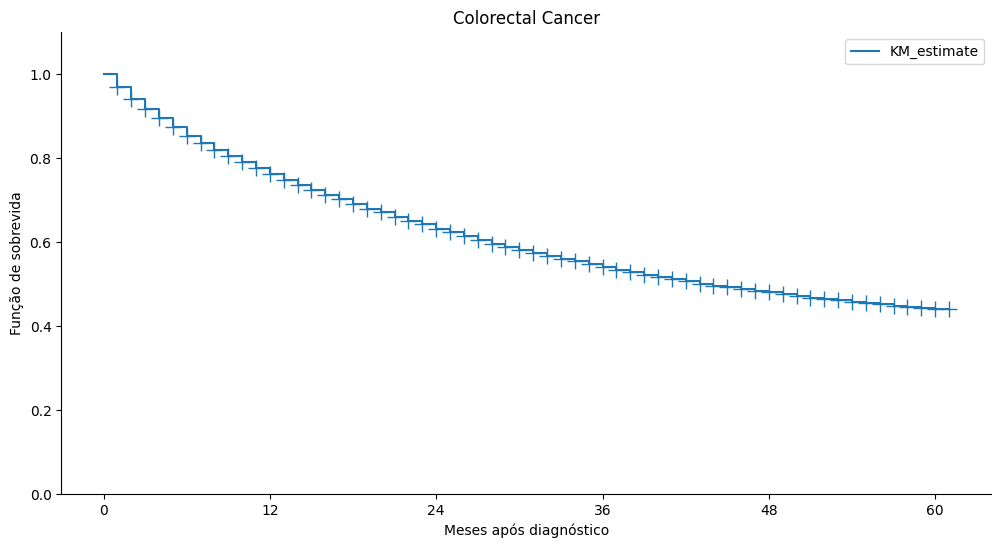

In [ ]:
# Estimador de Kaplan-Meier
# Extração do evento (E) e tempo (T) do conjunto de teste
E = (df_teste.obito_geral == 1)  # Indicador do evento (obito_geral = 1 indica óbito)
T = df_teste.meses_diag  # Tempo até o evento (meses desde o diagnóstico)

title = f'Colorectal Cancer'  # Título do gráfico

kmf = KaplanMeierFitter()  # Inicialização do estimador

# Criação da figura
fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

# Fit e plot da curva de Kaplan-Meier
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)
ax.set_title(title)  # Adiciona o título
ax.set_xlabel('Meses após diagnóstico')  # Adiciona o nome do eixo x
ax.set_ylabel('Função de sobrevida')  # Adiciona o nome do eixo y
ax.spines['top'].set_visible(False)  # Remove a borda superior
ax.spines['right'].set_visible(False)  # Remove a borda direita
ax.set_xticks(np.arange(0, 71, 12))  # Eixo x com marcadores a cada 12 meses
plt.ylim([0, 1.1])  # Limites do eixo y
plt.show()  # Mostra o gráfico

In [ ]:
# Sobrevida em 1, 3 e 5 anos
kmf.survival_function_.loc[[12, 36, 60]]

,KM_estimate
timeline,
12.0,0.762278
36.0,0.541013
60.0,0.440833


# **Machine Learning Survival**

## **Preparação dos dados para os modelos de sobrevida**

In [ ]:
# Leitura dos dados de treino
df_treino = pd.read_csv('colorretal_treino.csv')
print(df_treino.shape)  # Dimensão dos dados
df_treino.head(3)  # 3 primeiras linhas do conjunto de dados

(35885, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,22128,2,71,1,3549805,2,1,C186,IIA,II,...,0,0,0,0,0,0,0,0,1,1
1,16624,9,73,2,3550308,2,2,C209,IV,IV,...,2,2,1,0,1,1,0,0,26,1
2,16675,4,87,2,3550308,1,1,C209,IVB,IV,...,0,0,1,0,1,1,0,0,13,1


In [ ]:
# Leitura dos dados de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensão dos dados
df_teste.head(3)  # 3 primeiras linhas do conjunto de dados

(8972, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,21636,2,67,1,3516705,2,1,C185,IIIB,III,...,1,0,0,0,0,1,1,1,61,0
1,19488,2,46,2,3552205,2,1,C188,IIIB,III,...,0,0,0,1,0,1,0,0,33,0
2,612374,2,66,2,3534401,9,2,C209,IIA,II,...,0,2,0,0,0,1,1,1,61,0


In [ ]:
# Exclusão das linhas com ULTIDIAG negativo
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(35884, 49)

### **Informações**

In [ ]:
aux = pd.concat([df_treino, df_teste], axis=0)  # Combine X_test and y_test into a single DataFrame
aux.shape

(44856, 49)

In [ ]:
aux.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1',
       'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag', 'obito_geral'],
      dtype='object')

12    0.766187
36    0.543895
60    0.437912
Name: KM_estimate, dtype: float64


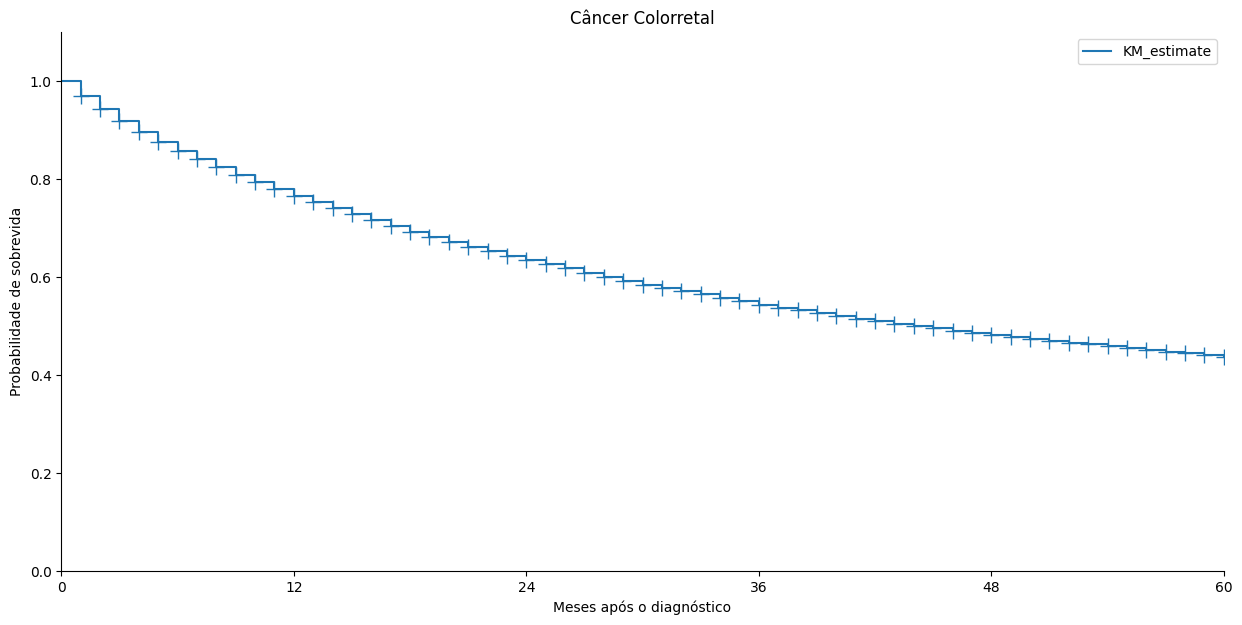

In [ ]:
# Define o DataFrame que será utilizado na análise
data = aux

# Cria a variável de evento:
# True indica que o paciente foi a óbito (obito_geral igual a 1)
# False indica que o paciente foi censurado
E = (data.obito_geral == 1)

# Define o tempo de acompanhamento/sobrevida em meses após o diagnóstico
T = data.meses_diag

# Define o título do gráfico
title = 'Câncer Colorretal'

# Cria a figura com tamanho personalizado
fig = plt.figure(figsize=(15, 7))

# Cria o eixo principal do gráfico
ax = plt.subplot(111)

# Inicializa o estimador de Kaplan-Meier
kmf = KaplanMeierFitter()

# Ajusta o estimador de Kaplan-Meier aos dados de tempo e evento
# Em seguida, plota a curva de sobrevida
# ci_show=False remove o intervalo de confiança
# show_censors=True exibe as marcações dos pacientes censurados na curva
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)

# Define o título do gráfico
ax.set_title(title)

# Define o rótulo do eixo x
ax.set_xlabel('Meses após o diagnóstico')

# Define o rótulo do eixo y
ax.set_ylabel('Probabilidade de sobrevida')

# Remove a borda superior do gráfico
ax.spines['top'].set_visible(False)

# Remove a borda direita do gráfico
ax.spines['right'].set_visible(False)

# Define os marcadores do eixo x de 12 em 12 meses, até 60 meses
plt.xticks(np.arange(0, 72, 12))

# Define os limites do eixo y
plt.ylim([0, 1.1])

# Define os limites do eixo x, restringindo a visualização até 60 meses
plt.xlim([0, 60])

# Imprime as probabilidades de sobrevida estimadas em 12, 36 e 60 meses
print(kmf.survival_function_at_times([12, 36, 60]))

# Salva o gráfico em um arquivo de imagem
plt.savefig('colorretal.jpg')

In [ ]:
def resumo_sobrevida(df, tempo_col, evento_col):
    """
    Calcula resumo descritivo de dados de sobrevida.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame com os dados.
    tempo_col : str
        Coluna com o tempo até evento ou censura.
    evento_col : str
        Coluna do evento, onde 1 = evento/óbito e 0 = censura.
    limite_followup : int ou float, opcional
        Limite de acompanhamento. Exemplo: 60 para censura administrativa em 5 anos.

    Retorna
    -------
    dict
        Dicionário com estatísticas de acompanhamento, sobrevida e censura.
    """
    dados = df[[tempo_col, evento_col]].copy()

    tempo = dados[tempo_col]
    evento = dados[evento_col]

    # Kaplan-Meier para sobrevida global
    kmf = KaplanMeierFitter()
    kmf.fit(durations=tempo, event_observed=evento)

    mediana_sobrevida = kmf.median_survival_time_

    # Sobrevida em 1, 3 e 5 anos
    tempos_interesse = [12, 36, 60]
    sobrevida_tempos = kmf.survival_function_at_times(tempos_interesse)

    # Kaplan-Meier reverso para follow-up mediano
    kmf_followup = KaplanMeierFitter()
    kmf_followup.fit(
        durations=tempo,
        event_observed=1 - evento
    )

    mediana_followup_km_reverso = kmf_followup.median_survival_time_

    # Censura
    n_total = len(dados)
    n_eventos = int(evento.sum())
    n_censurados = int(n_total - n_eventos)
    taxa_censura = n_censurados / n_total

    dados_censurados = dados[dados[evento_col] == 0]

    resumo = {
        'n_total': n_total,
        'n_eventos': n_eventos,
        'n_censurados': n_censurados,
        'taxa_censura_%': taxa_censura * 100,

        'tempo_mediano_acompanhamento_observado': tempo.median(),
        'tempo_mediano_followup_km_reverso': mediana_followup_km_reverso,

        'tempo_mediano_sobrevida_global': mediana_sobrevida,

        'sobrevida_1_ano_%': float(sobrevida_tempos.loc[12] * 100),
        'sobrevida_3_anos_%': float(sobrevida_tempos.loc[36] * 100),
        'sobrevida_5_anos_%': float(sobrevida_tempos.loc[60] * 100),

        'tempo_censura_media': dados_censurados[tempo_col].mean(),
        'tempo_censura_mediana': dados_censurados[tempo_col].median(),
        'tempo_censura_p25': dados_censurados[tempo_col].quantile(0.25),
        'tempo_censura_p75': dados_censurados[tempo_col].quantile(0.75),
        'tempo_censura_min': dados_censurados[tempo_col].min(),
        'tempo_censura_max': dados_censurados[tempo_col].max(),
    }

    return resumo, kmf, dados


resumo, kmf, dados_surv = resumo_sobrevida(df=aux, tempo_col='meses_diag',
                                           evento_col='obito_geral')

resumo

{'n_total': 44856,
 'n_eventos': 21877,
 'n_censurados': 22979,
 'taxa_censura_%': 51.228375245229174,
 'tempo_mediano_acompanhamento_observado': 27.0,
 'tempo_mediano_followup_km_reverso': np.float64(61.0),
 'tempo_mediano_sobrevida_global': np.float64(45.0),
 'sobrevida_1_ano_%': 76.61867269045631,
 'sobrevida_3_anos_%': 54.38947205286676,
 'sobrevida_5_anos_%': 43.791190937808295,
 'tempo_censura_media': np.float64(43.98572609774141),
 'tempo_censura_mediana': 61.0,
 'tempo_censura_p25': np.float64(25.0),
 'tempo_censura_p75': np.float64(61.0),
 'tempo_censura_min': 1,
 'tempo_censura_max': 61}

In [ ]:
def km_plot(df, coluna, labels=None):
    """
    Gera curvas de Kaplan-Meier estratificadas por uma variável categórica
    e realiza o teste log-rank entre os grupos.

    Parâmetros:
    df : DataFrame
        Base de dados contendo as informações dos pacientes.
    coluna : str
        Nome da coluna categórica usada para separar os grupos.
    labels : list, opcional
        Lista com os nomes personalizados dos grupos na legenda.
    """

    # Cria uma cópia do DataFrame original
    data = df.copy()

    # Define variável de evento
    E = (data.obito_geral == 1)

    # Define tempo de seguimento
    T = data.meses_diag

    # Ajusta nome da variável para exibição
    if '_CAT' in coluna:
        nome = coluna.replace('_CAT', '')
    else:
        nome = coluna

    # Define título do gráfico
    title = f'Câncer Colorretal - {nome}'

    # Cria figura
    fig = plt.figure(figsize=(15, 7))
    ax = plt.subplot(111)

    # Percorre categorias
    for i, cat in enumerate(np.sort(data[coluna].unique())):

        # Seleciona grupo atual
        group = (data[coluna] == cat)

        # Define legenda
        if labels is not None:
            label = labels[i]
        else:
            label = f'{coluna} - {cat}'

        # Inicializa modelo Kaplan-Meier
        kmf = KaplanMeierFitter()

        # Dados do grupo
        T1 = T[group]
        E1 = E[group]

        # Ajusta curva
        ax = kmf.fit(T1, E1, label=label).plot(ax=ax,
                                               ci_show=False,
                                               show_censors=True)
    # ================
    #  TESTE LOG-RANK
    # ================

    # Obtém categorias existentes
    grupos = np.sort(data[coluna].unique())

    # Se houver apenas 2 grupos, usa logrank_test
    if len(grupos) == 2:
        group1 = data[coluna] == grupos[0]
        group2 = data[coluna] == grupos[1]

        resultado = logrank_test(
            T[group1],
            T[group2],
            event_observed_A=E[group1],
            event_observed_B=E[group2]
        )

        p_value = resultado.p_value

    # Se houver mais de 2 grupos, usa multivariate_logrank_test
    else:
        resultado = multivariate_logrank_test(T,
                                              data[coluna],
                                              E)
        p_value = resultado.p_value

    # Adiciona valor de p no gráfico
    ax.text(0.05, 0.075, f'Log-rank p = {p_value:.5f}',transform=ax.transAxes,
            fontsize=12)

    # Configurações do gráfico
    ax.set_title(title)
    ax.set_xlabel('Meses após o diagnóstico')
    ax.set_ylabel('Probabilidade de sobrevida')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.xticks(np.arange(0, 72, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 60])

    # Salva figura
    plt.savefig(f'km_{coluna}.jpg')

    # Exibe resultado do teste no console
    print(resultado.summary)

   test_statistic    p  -log2(p)
0    13496.665515  0.0       inf


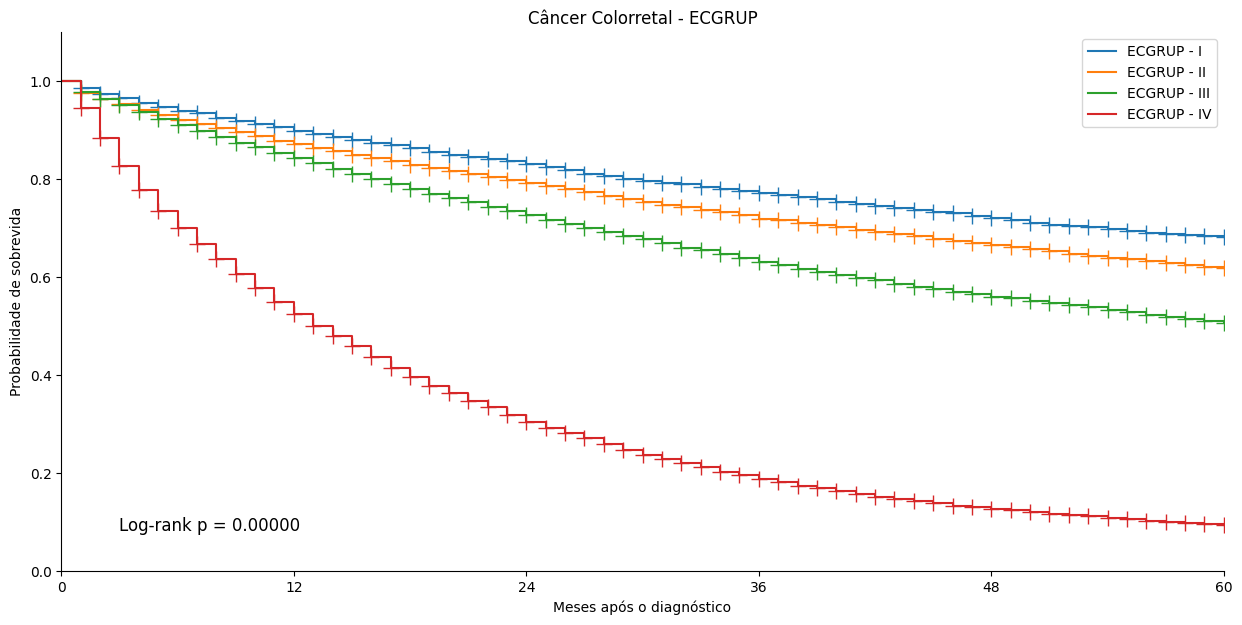

In [ ]:
km_plot(aux, 'ECGRUP')

   test_statistic             p   -log2(p)
0       77.936487  1.064075e-18  59.705105


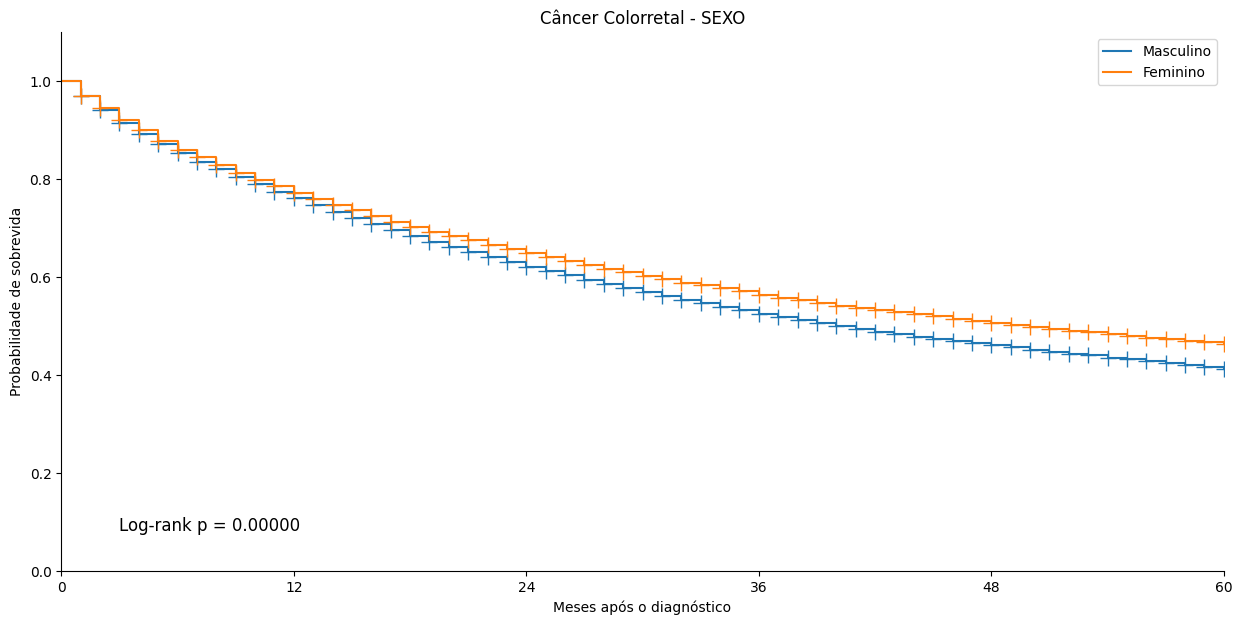

In [ ]:
km_plot(aux, 'SEXO', ['Masculino', 'Feminino'])

   test_statistic             p    -log2(p)
0      353.209329  3.565490e-74  243.988579


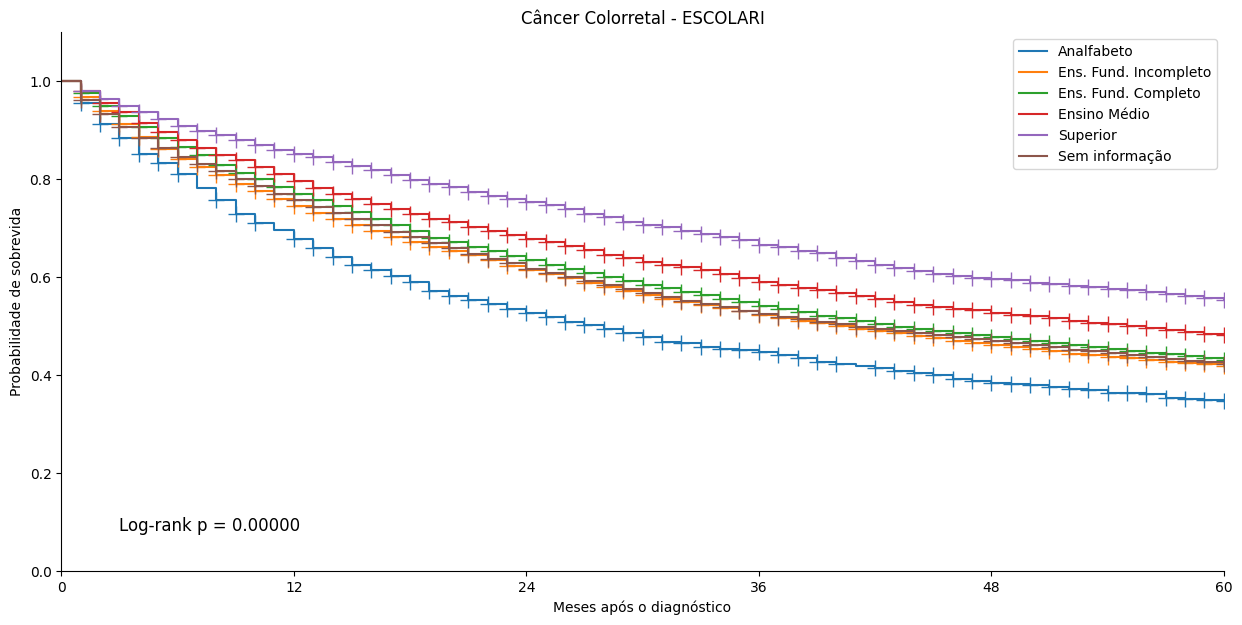

In [ ]:
km_plot(aux, 'ESCOLARI', ['Analfabeto', 'Ens. Fund. Incompleto', 'Ens. Fund. Completo',
                          'Ensino Médio', 'Superior', 'Sem informação'])

   test_statistic             p    -log2(p)
0      400.874676  3.552460e-89  293.822782


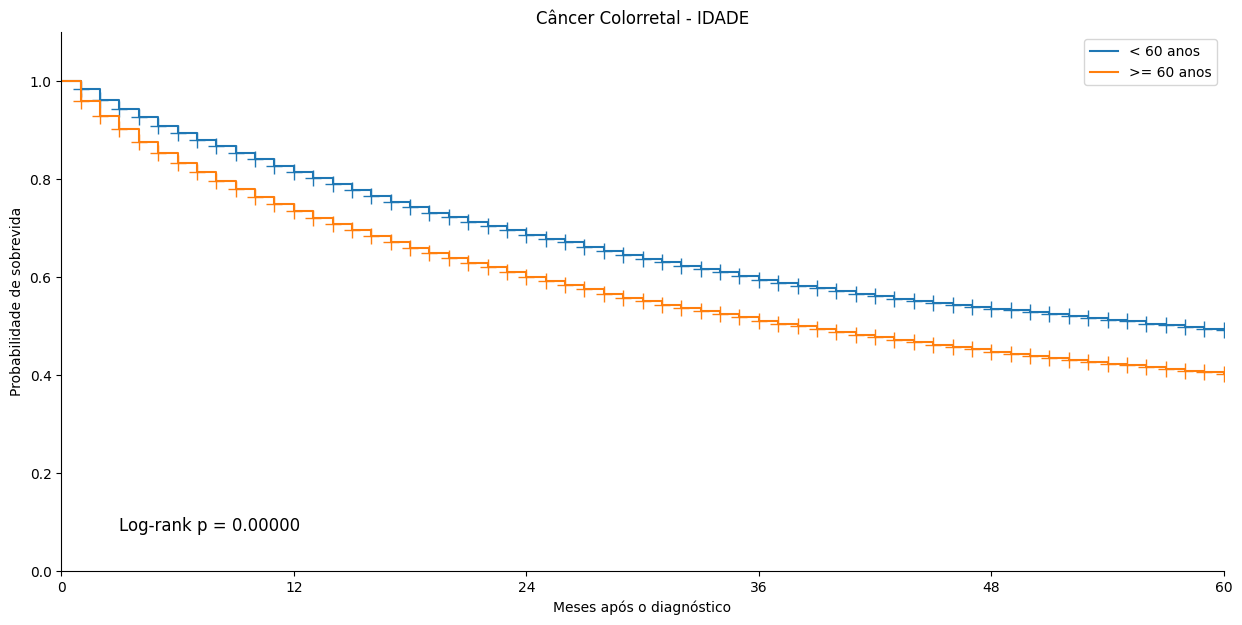

In [ ]:
aux['IDADE_CAT'] = [0 if idade < 60 else 1 for idade in aux.IDADE]

km_plot(aux, 'IDADE_CAT', ['< 60 anos', '>= 60 anos'])

   test_statistic    p  -log2(p)
0     5890.832877  0.0       inf


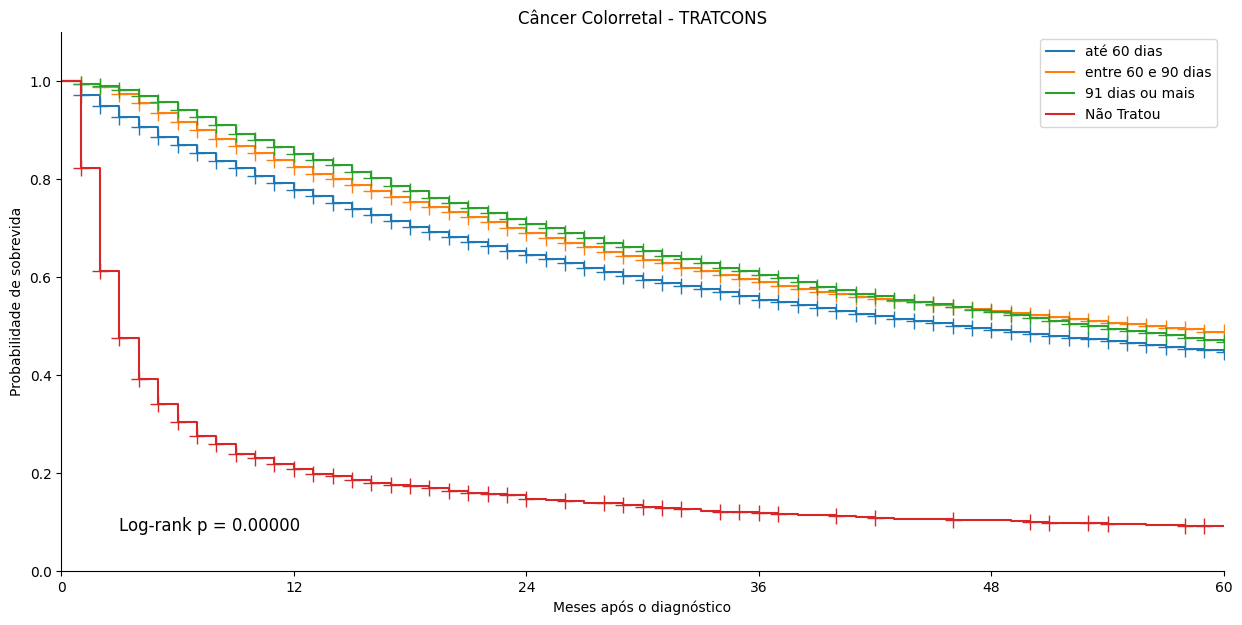

In [ ]:
km_plot(aux, 'TRATCONS_CAT', ['até 60 dias', 'entre 60 e 90 dias', '91 dias ou mais', 'Não Tratou'])

   test_statistic    p  -log2(p)
0     6038.517053  0.0       inf


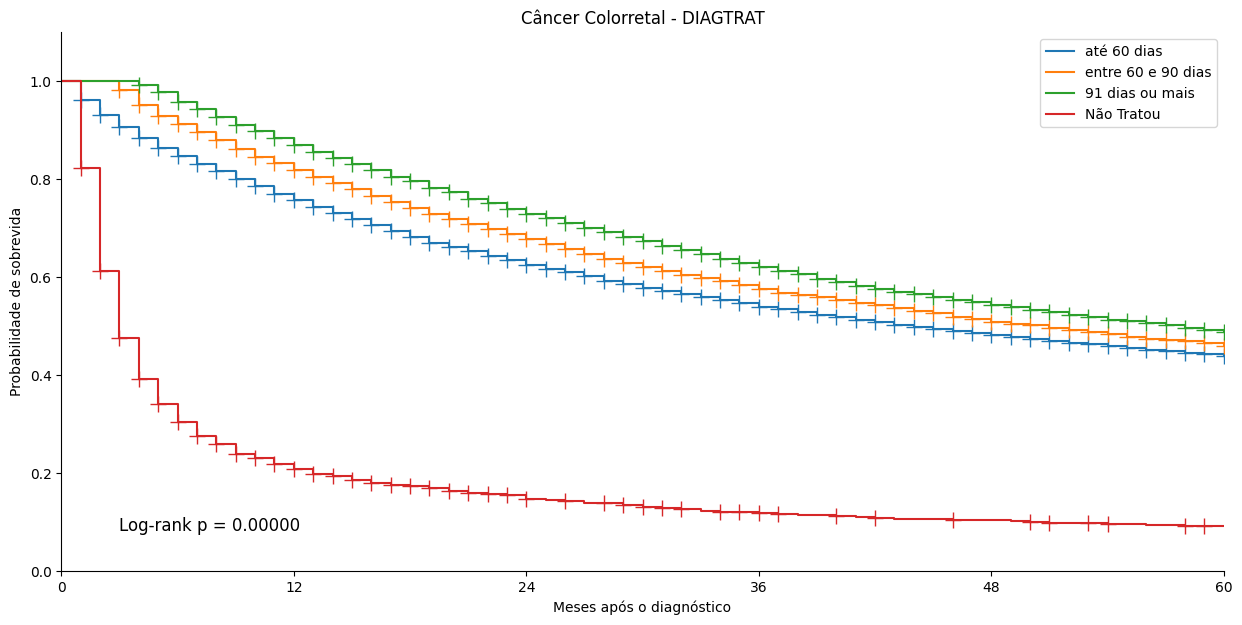

In [ ]:
km_plot(aux, 'DIAGTRAT_CAT', ['até 60 dias', 'entre 60 e 90 dias', '91 dias ou mais', 'Não Tratou'])

In [ ]:
aux.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1',
       'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag', 'obito_geral',
       'IDADE_CAT'],
      dtype='object')

In [ ]:
col = 'obito_geral'

c = aux[col].value_counts(dropna=False).sort_index()
p = aux[col].value_counts(dropna=False, normalize=True).sort_index()*100
pd.concat([c, p], axis=1, keys=['counts', '%'])

,counts,%
obito_geral,,
0,22979,51.228375
1,21877,48.771625


In [ ]:
col = 'obito_geral'

c = df_treino[col].value_counts(dropna=False).sort_index()
p = df_treino[col].value_counts(dropna=False, normalize=True).sort_index()
pd.concat([c, p], axis=1, keys=['counts', '%'])

,counts,%
obito_geral,,
0,18383,0.51229
1,17501,0.48771


In [ ]:
col = 'IDADE'

print(df_teste[col].mean())
print(df_teste[col].median())

62.31007579135087
63.0


In [ ]:
comp = pd.concat([df_treino, df_teste])

col = 'obito_geral'

c = comp[col].value_counts(dropna=False).sort_index()
p = comp[col].value_counts(dropna=False, normalize=True).sort_index()
pd.concat([c, p], axis=1, keys=['counts', '%'])

,counts,%
obito_geral,,
0,22979,0.512284
1,21877,0.487716


In [ ]:
col = 'IDADE'

print(comp[col].mean())
print(comp[col].median())

62.38766274299982
63.0


### **Pré-Processamento**

In [ ]:
# Define as variáveis que não serão utilizadas na matriz de correlação.
# São removidas variáveis relacionadas ao desfecho, tempo de sobrevida,
# estadiamento, tratamento, acompanhamento e outras informações derivadas.
list_drop = [
    'obito_cancer',
    'sobrevida_ano1',
    'sobrevida_ano3',
    'sobrevida_ano5',
    'meses_diag',
    'ECGRUP',
    'NENHUM',
    'CIRURGIA',
    'RADIO',
    'QUIMIO',
    'HORMONIO',
    'IMUNO',
    'OUTROS',
    'NENHUMAPOS',
    'CIRURAPOS',
    'RADIOAPOS',
    'QUIMIOAPOS',
    'HORMOAPOS',
    'IMUNOAPOS',
    'OUTROAPOS',
    'ULTINFO',
    'CONSDIAG',
    'TRATCONS',
    'DIAGTRAT',
    'RRAS',
    'DSCINST',
    'RRAS_INST',
    'ECGRUP_CAT',
    'ULTIDIAG',
    'CONSDIAG_CAT',
    'PRESENCA_META',
    'PRESENCA_REC'
]

# Cria uma cópia do conjunto de treinamento removendo as variáveis
# que não serão consideradas na análise de correlação
X_cor = df_treino.drop(columns=list_drop).copy()

# Exibe os nomes das variáveis restantes após a remoção
# das colunas especificadas
X_cor.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT', 'obito_geral'],
      dtype='object')

In [ ]:
# Importa o teste do qui-quadrado de independência
from scipy.stats import chi2_contingency

# Define uma função para calcular o coeficiente V de Cramér,
# utilizado para medir a associação entre duas variáveis categóricas
def cramers_v(x, y):

    # Cria a tabela de contingência entre as duas variáveis
    confusion_matrix = pd.crosstab(x, y)

    # Calcula a estatística do teste do qui-quadrado
    chi2 = chi2_contingency(confusion_matrix)[0]

    # Obtém o número total de observações da tabela de contingência
    n = confusion_matrix.sum().sum()

    # Calcula o valor de phi ao quadrado a partir da estatística
    # do qui-quadrado e do tamanho da amostra
    phi2 = chi2 / n

    # Obtém o número de linhas e colunas da tabela de contingência
    r, k = confusion_matrix.shape

    # Aplica a correção de viés para o cálculo do V de Cramér,
    # reduzindo o viés associado ao tamanho da amostra e às dimensões da tabela
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))

    # Calcula o número de linhas corrigido da tabela de contingência
    rcorr = r - ((r - 1) ** 2) / (n - 1)

    # Calcula o número de colunas corrigido da tabela de contingência
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    # Calcula e retorna o V de Cramér corrigido
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

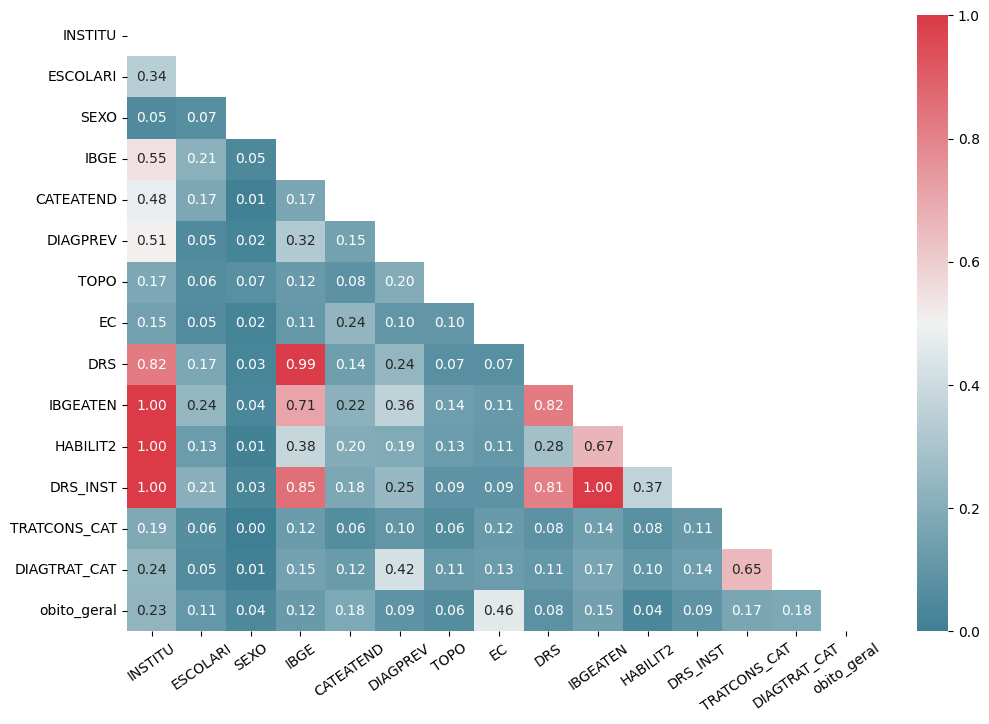

In [ ]:
# Define as variáveis categóricas que serão utilizadas no cálculo
# da matriz de associação pelo V de Cramér
cat_cols = [
    'INSTIT',
    'ESCOLARI',
    'SEXO',
    'IBGE',
    'CATEATEND',
    'DIAGPREV',
    'TOPO',
    'EC',
    'DRS',
    'IBGEATEN',
    'HABILIT2',
    'DRS_INST',
    'TRATCONS_CAT',
    'DIAGTRAT_CAT',
    'obito_geral'
]

# Inicializa uma matriz quadrada preenchida com zeros para armazenar
# os valores do V de Cramér entre todos os pares de variáveis categóricas
cramer_matrix = pd.DataFrame(np.zeros((len(cat_cols), len(cat_cols))),
                             index=cat_cols, columns=cat_cols)

# Calcula o V de Cramér para cada combinação de variáveis categóricas
for col1 in cat_cols:
    for col2 in cat_cols:

        # Calcula a associação entre as duas variáveis e armazena
        # o resultado na posição correspondente da matriz
        cramer_matrix.loc[col1, col2] = cramers_v(X_cor[col1], X_cor[col2])

# Cria a figura para visualização da matriz de associação
fig = plt.figure(figsize=(12, 8))

# Define uma paleta de cores divergente para representar os valores
# de associação entre as variáveis
colormap = sns.diverging_palette(220, 10, as_cmap=True)

# Cria uma máscara para ocultar a metade superior da matriz,
# evitando a apresentação duplicada dos valores de associação
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))

# Gera o mapa de calor da matriz de associação.
# Os valores do V de Cramér são exibidos nas células com duas casas decimais.
# Os valores são limitados ao intervalo de 0 a 1.
sns.heatmap(cramer_matrix, mask=mask, annot=True, cmap=colormap, vmin=0, vmax=1,
            fmt='.2f')

# Define a rotação dos rótulos do eixo x para melhorar a visualização
plt.xticks(rotation=35)

# Exibe o mapa de calor
plt.show()

# Salva a figura da matriz de associação no formato JPG
fig.savefig('cat_corr_matrix.jpg')

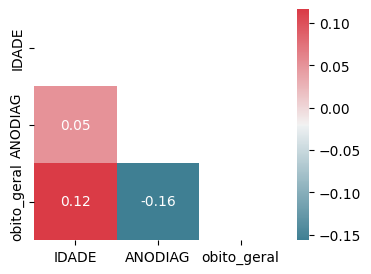

In [ ]:
num_cols = ['IDADE', 'ANODIAG', 'obito_geral']
X_cor_num = X_cor[num_cols].copy()

# Matriz de Correlação
corr_matrix = X_cor_num.corr(numeric_only=True)

# Cria uma nova figura do matplotlib com um eixo e define o tamanho da figura como 7 polegadas de largura por 6 polegadas de altura
fig, ax = plt.subplots(figsize=(4, 3))

# Define um mapa de cores para a matriz de calor usando o Seaborn
colormap = sns.diverging_palette(220, 10, as_cmap=True)

# Plota a matriz de correlação como um mapa de calor usando Seaborn
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(corr_matrix, cmap=colormap, mask=mask, annot=True, fmt='.2f')

# Exibe a figura
plt.show()

fig.savefig('num_corr_matrix.jpg')

In [ ]:
# y_train e y_test - Óbito e Meses após o diagnóstico
y_train = Surv.from_arrays(df_treino.obito_geral, df_treino.meses_diag)
y_test = Surv.from_arrays(df_teste.obito_geral, df_teste.meses_diag)

In [ ]:
# Retirada das colunas que não serão utilizadas como features nos modelos de sobrevida
list_drop = ['obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5',
             'meses_diag', 'obito_geral', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO',
             'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS',
             'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS',
             'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST',
             'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC']

X_train = df_treino.drop(list_drop, axis=1)  # Conjunto de treino

X_test = df_teste.drop(list_drop, axis=1)  # Conjunto de validação

In [ ]:
# Pré-processamento dos conjuntos de treino e teste
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Método de normalização
                                                      return_enc_norm=True,  # Retornar os modelos de codificação e normalização
                                                      random_state=seed)  # Reprodutibilidade

# Tamanho final dos dados de treinamento e teste
X_train.shape, X_test.shape

((35884, 16), (8972, 16))

In [ ]:
# Features selecionadas
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

## **Random Survival Forest**

#### **Modelo baseline**

In [ ]:
# Random Survival Forest
rsf = RandomSurvivalForest(max_depth=8, n_jobs=-1, random_state=seed)  # Initializa o modelo com max depth = 8
rsf.fit(X_train, y_train)  # Treinamento do modelo

# C-Index para o conjunto de teste
c_index_base = rsf.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}')

C-Index Test: 0.7517176452336831
C-Index Train: 0.7631437582576479


C-Index IPCW Test: 0.745620186422011
C-Index IPCW Train: 0.7559101078319813

Integrated Brier Score (IBS): 0.15951821749521222

Brier Score:
    > 1 year = 0.13946323413511666
    > 3 years = 0.17947370726051814
    > 5 years = 0.17947388519927296



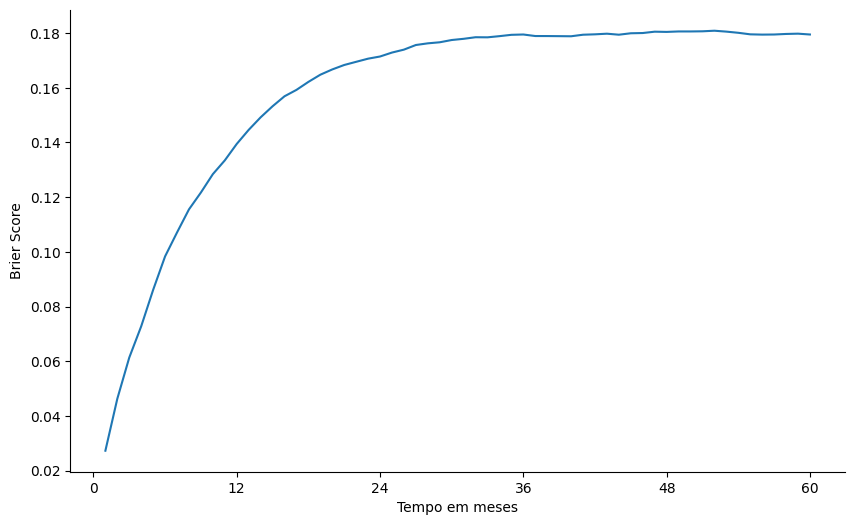

In [ ]:
# C-Index IPCW e Brier Score
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)

Mean AUC: 0.81357



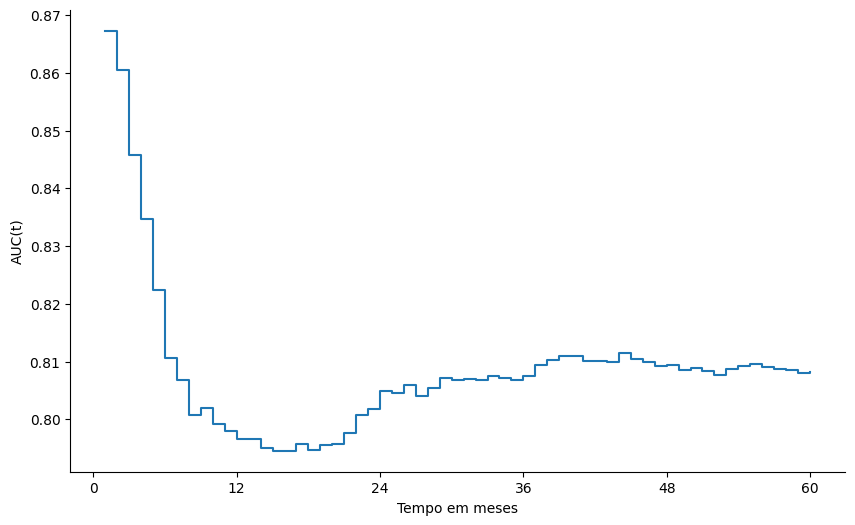

In [ ]:
# Tempos para avaliar
times_eval = rsf.unique_times_[:-1]

# Predição do modelo
est_rsf = rsf.predict_cumulative_hazard_function(X_test, return_array=False)
rsf_risk_scores = np.vstack([chf(times_eval) for chf in est_rsf])

# Cálculo do cumulative/dynamic AUC
auc_rsf_times, mean_auc_rsf = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times_eval)
print(f'Mean AUC: {mean_auc_rsf:.5f}\n')

fig, ax = plt.subplots(figsize=(10, 6))  # Cria a figura
ax.step(times_eval, auc_rsf_times, where="post", label="RSF")
ax.set_xlabel('Tempo em meses')  # Adiciona o nome do eixo x
ax.set_ylabel('AUC(t)')  # Adiciona o nome do eixo y
ax.spines['top'].set_visible(False)  # Remove a borda superior
ax.spines['right'].set_visible(False)  # Remove a borda direita
ax.set_xticks(np.arange(0, times_eval[-1] + 11, 12))  # Eixo x com marcadores a cada 12 meses
plt.show()  # Mostra o gráfico

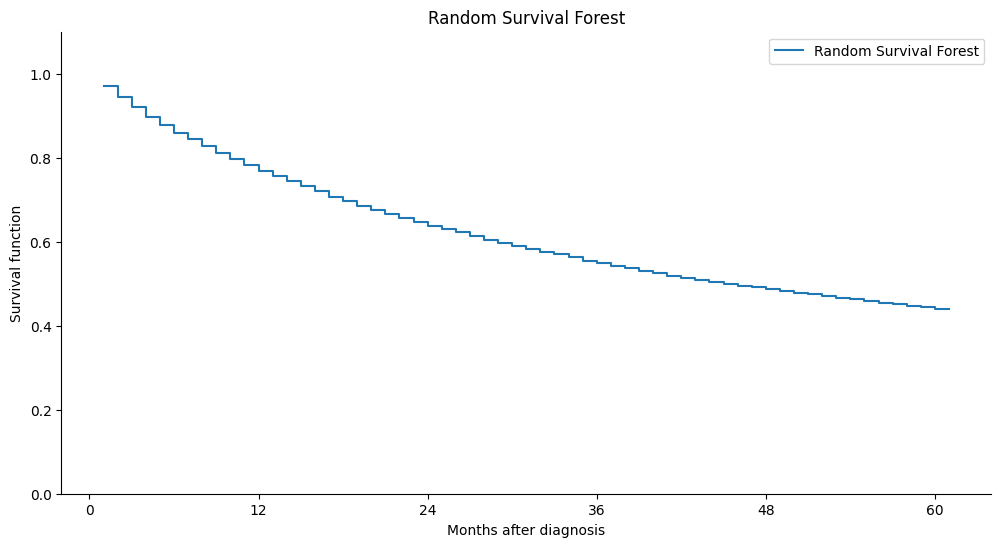

In [ ]:
# Predição de sobrevida - Curva
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)  # Faz as médias para obter uma curva de sobrevida única

# Gera e mostra a curva de sobrevida do RSF
name = 'Random Survival Forest'
plot_survival_curve(rsf.unique_times_, surv_rsf_mean, name=name)

In [ ]:
# Probabilidade predita de sobrevida em 12, 36 e 60 meses
print(f'12: {surv_rsf_mean[12]}')
print(f'36: {surv_rsf_mean[36]}')
print(f'60: {surv_rsf_mean[60]}')

12 months: 0.7569640634742844
36 months: 0.5426954903578372
60 months: 0.4404515816400029


#### **Optuna**

**Principais Hiperparâmetros para Otimização no RSF**

1. `n_estimators` (int)
* Descrição: Número de árvores na floresta. Mais árvores geralmente aumentam a precisão, mas podem tornar o treinamento mais lento.
* Sugestão de valores: 50 a 1000.

2. `max_depth` (int)
* Descrição: Profundidade máxima das árvores. Uma maior profundidade permite capturar padrões complexos, mas pode levar ao overfitting.
* Sugestão de valores: 3 a 30.

3. `min_samples_split` (int)
* Descrição: Número mínimo de amostras necessárias para dividir um nó. Controla o crescimento da árvore. Valores mais altos evitam o overfitting.
* Sugestão de valores: 2 a 20.

4. `min_samples_leaf` (int)
* Descrição: Número mínimo de amostras necessárias para formar uma folha. Valores maiores evitam folhas com muito poucas amostras, reduzindo o overfitting.
* Sugestão de valores: 1 a 50.

5. `max_features` (float, int, str)
* Descrição: Proporção ou número de recursos a serem considerados ao dividir um nó. Define a aleatoriedade do modelo, balanceando viés e variância.

    a) 'sqrt': Considera a raiz quadrada do total de features.

    b) 'log2': Considera o logaritmo base 2 do total de features.

    c) Valores numéricos: Pode ser um número específico ou uma proporção das features.

* Sugestão de valores: 'sqrt', 'log2', ou entre 0.1 e 1.0.

6. `bootstrap` (bool)
* Descrição: Se as amostras de treino são extraídas com ou sem reposição. Aumenta a diversidade entre as árvores, reduzindo o overfitting.
* Sugestão de valores: True ou False.

7. `oob_score` (bool)
* Descrição: Se o modelo deve calcular o erro fora da amostra (out-of-bag) durante o treinamento. Pode fornecer uma estimativa do desempenho sem a necessidade de um conjunto de validação separado.
* Sugestão de valores: True ou False.

8. `n_jobs` (int)
* Descrição: Número de processadores a serem usados em paralelo. Define a quantidade de processamento paralelo.
* Sugestão de valores: -1 (usa todos os processadores disponíveis).

9. `min_weight_fraction_leaf` (float)
* Descrição: Fração mínima do peso total das amostras que deve estar em cada folha. Previne folhas muito pequenas com base no peso das amostras.
* Sugestão de valores: 0.0 a 0.5.

In [ ]:
# Número de tentativas
n_trials = 150

In [ ]:
# Folds para validação cruzada
kf = KFold(n_splits=10, shuffle=True, random_state=seed)

# Função para calcular o C-Index
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)
    return cindex

# Função objetivo para otimização de hiperparâmetros
def objective(trial):
    # Define os hiperparâmetros que serão otimizados
    n_estimators = trial.suggest_int('n_estimators', 50, 130)  # Número de árvores
    max_depth = trial.suggest_int('max_depth', 3, 10)  # Profundidade máxima de cada árvore
    min_samples_split = trial.suggest_int('min_samples_split', 3, 12)  # Número mínimo de amostras necessárias para dividir um nó
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 12)  # Número mínimo de amostras necessárias em um nó de folhas
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Estratégia de seleção de features
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])  # Usar bootstrap

    # Cria e treina o modelo com os hiperparâmetros escolhidos
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=seed,
        n_jobs=-1
    )

    # Realiza a validação cruzada e retorna o valor médio do C-Index
    return cross_val_score(rsf, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - RandomSampler
# study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
#                             study_name='RSF_RandomSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'opt_rsf_rand.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
                                study_name='RSF_RandomSampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 19.5 ms, sys: 969 µs, total: 20.5 ms
Wall time: 20.4 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 116, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}


In [ ]:
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
rsf_rand = RandomSurvivalForest(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
rsf_rand.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_rand = rsf_rand.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {rsf_rand.score(X_train, y_train)}')

C-Index Test: 0.7547371017603656
C-Index Train: 0.7797215136399612


**TPESampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - TPESampler
# study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
#                             study_name='RSF_TPESampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'opt_rsf_tpe.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='RSF_TPESampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 28 ms, sys: 968 µs, total: 28.9 ms
Wall time: 32.9 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 89, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}


In [ ]:
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
rsf_tpe = RandomSurvivalForest(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
rsf_tpe.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_tpe = rsf_tpe.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {rsf_tpe.score(X_train, y_train)}')

C-Index Test: 0.7545059354114757
C-Index Train: 0.7781420858503447


**CmaEsSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - CmaEsSampler
# study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
#                             study_name='RSF_CmaEsSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'opt_rsf_cma.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='RSF_CmaEsSampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 19.5 ms, sys: 0 ns, total: 19.5 ms
Wall time: 19.8 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 114, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}


In [ ]:
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
rsf_cma = RandomSurvivalForest(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
rsf_cma.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_cma = rsf_cma.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_cma}')
print(f'C-index Train: {rsf_cma.score(X_train, y_train)}')

C-Index Test: 0.7547223268139652
C-index Train: 0.7797459525248217


#### **Melhor Random Survival Forest**

In [ ]:
# Melhor modelo RSF
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # Lista de C-Index para os modelos RSF
models = [rsf, rsf_rand, rsf_tpe, rsf_cma]  # Lista de modelos

# Encontrando o melhor modelo a partir do maior C-Index
id_best_score = scores.index(max(scores))
best = models[id_best_score]

# Mostra o modelo selecionado
print(best)

RandomSurvivalForest(bootstrap=False, max_depth=10, max_features='log2',
                     min_samples_leaf=9, min_samples_split=9, n_estimators=116,
                     random_state=1)


C-Index Test: 0.7547371017603656
C-Index Train: 0.7797215136399612

C-Index IPCW Test: 0.7489074752081798
C-Index IPCW Train: 0.7734233170546442

Integrated Brier Score (IBS): 0.1564607924057264

Brier Score:
    > 1 year = 0.13744132278481827
    > 3 years = 0.17567015830959912
    > 5 years = 0.17596705641278645



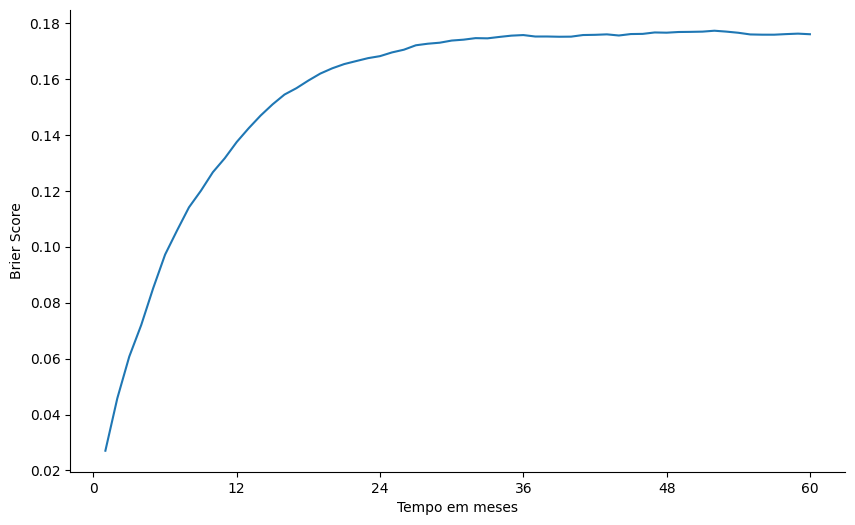

In [ ]:
# Métrics para o melhor modelo RSF
# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {best.score(X_test, y_test)}')
print(f'C-Index Train: {best.score(X_train, y_train)}\n')

# Cálculo do C-Index IPCW e Brier Score
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test, save=True)

Mean AUC: 0.81974



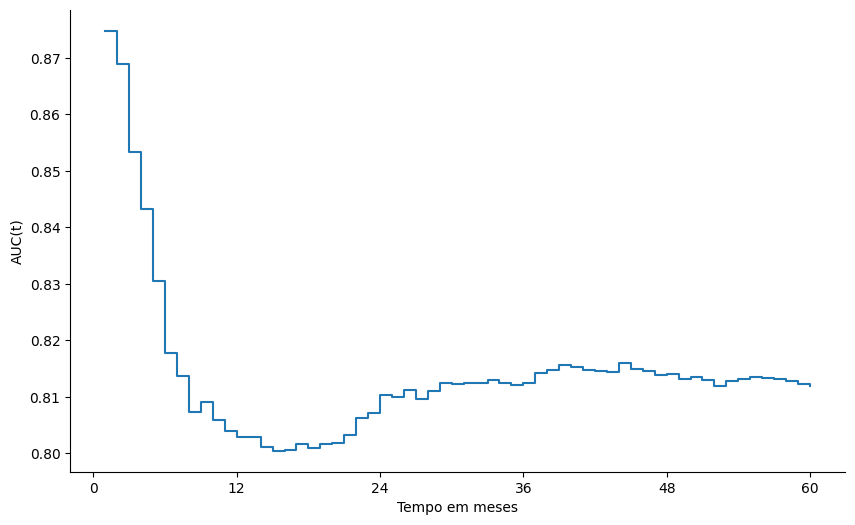

In [ ]:
# Seleciona os tempos únicos observados pelo modelo, removendo o último valor
# Essa remoção pode ser útil para evitar problemas em métricas avaliadas no limite máximo do seguimento
times = best.unique_times_[:-1]

# Prediz a função de risco acumulado para os pacientes do conjunto de teste
# return_array=False retorna uma lista de funções, uma para cada paciente
est = best.predict_cumulative_hazard_function(X_test, return_array=False)

# Avalia a função de risco acumulado de cada paciente nos tempos definidos em 'times'
model_pred = np.vstack([chf(times) for chf in est])

# Calcula a AUC tempo-dependente usando:
# - times: tempos em que a métrica será avaliada
# - model_pred: predições de risco acumulado dos pacientes ao longo do tempo
# - y_train: dados de sobrevida do conjunto de treino, usados como referência para lidar com censura
# - y_test: dados de sobrevida do conjunto de teste, usados para avaliar o desempenho
# save=True indica que o resultado ou gráfico gerado pela função será salvo
auc_time_dependent(times, model_pred, y_train, y_test, save=True)

In [ ]:
# Melhores features pelo permutation importance
pi_rsf = calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)
pi_rsf

,importances_mean,importances_std
EC,0.165104,0.003059
IDADE,0.027507,0.001610
CATEATEND,0.014188,0.001299
DIAGTRAT_CAT,0.009172,0.001097
TRATCONS_CAT,0.007497,0.000773
INSTITU,0.007339,0.000603
DIAGPREV,0.002896,0.000553
TOPO,0.002624,0.000252
ANODIAG,0.002610,0.000255
IBGEATEN,0.002371,0.000209


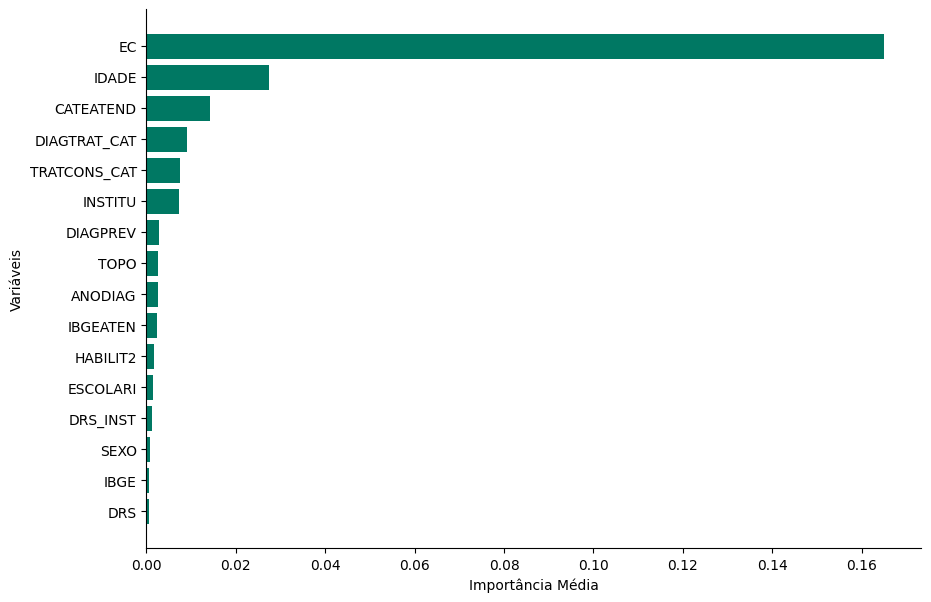

In [ ]:
# Cria uma nova coluna chamada 'features' a partir do índice do DataFrame
# Essa coluna armazenará os nomes das variáveis para facilitar a plotagem
pi_rsf['features'] = pi_rsf.index

# Cria a figura e o eixo do gráfico com tamanho personalizado
fig, ax = plt.subplots(figsize=(10, 7))

# Gera um gráfico de barras horizontais com:
# - eixo y: nomes das variáveis
# - eixo x: média das importâncias calculadas
ax.barh(pi_rsf['features'], pi_rsf['importances_mean'], color='#007863')

# Define o rótulo do eixo x
ax.set_xlabel('Importância Média')

# Define o rótulo do eixo y
ax.set_ylabel('Variáveis')

# Inverte a ordem do eixo y para que as variáveis mais importantes apareçam no topo
ax.invert_yaxis()

# Remove a borda superior do gráfico
ax.spines['top'].set_visible(False)

# Remove a borda direita do gráfico
ax.spines['right'].set_visible(False)

# Salva o gráfico em um arquivo de imagem
plt.savefig('rsf_pi.jpg')

PermutationExplainer explainer: 8973it [1:35:57,  1.56it/s]                          


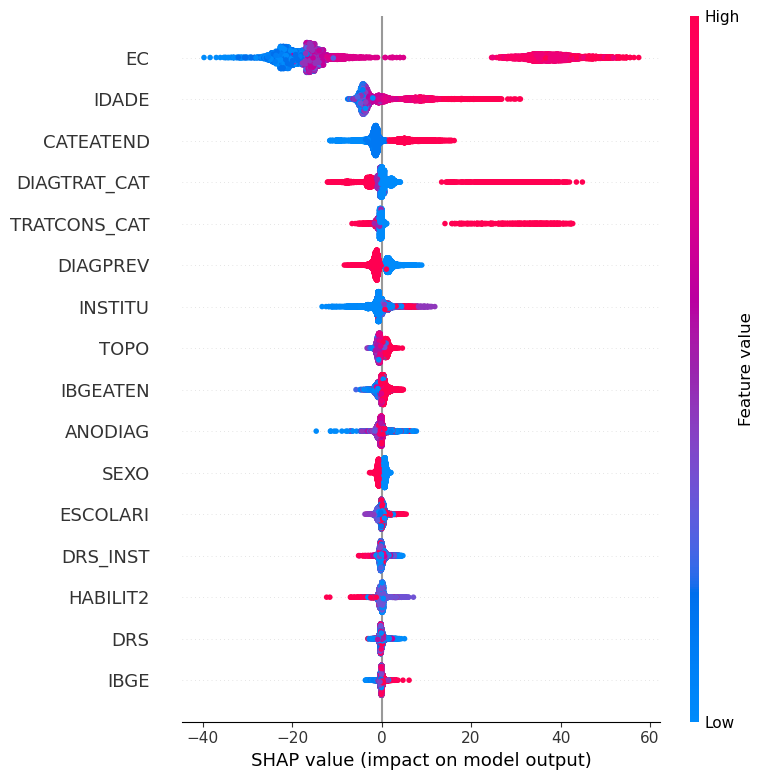

In [ ]:
# Melhores features pelo SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,
                           output_names=feat_cols, n_jobs=-1)

# Calcula os valores SHAP para os pacientes do conjunto de teste
shap_values = explainer(X_test)

# Gera o gráfico resumo do SHAP
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

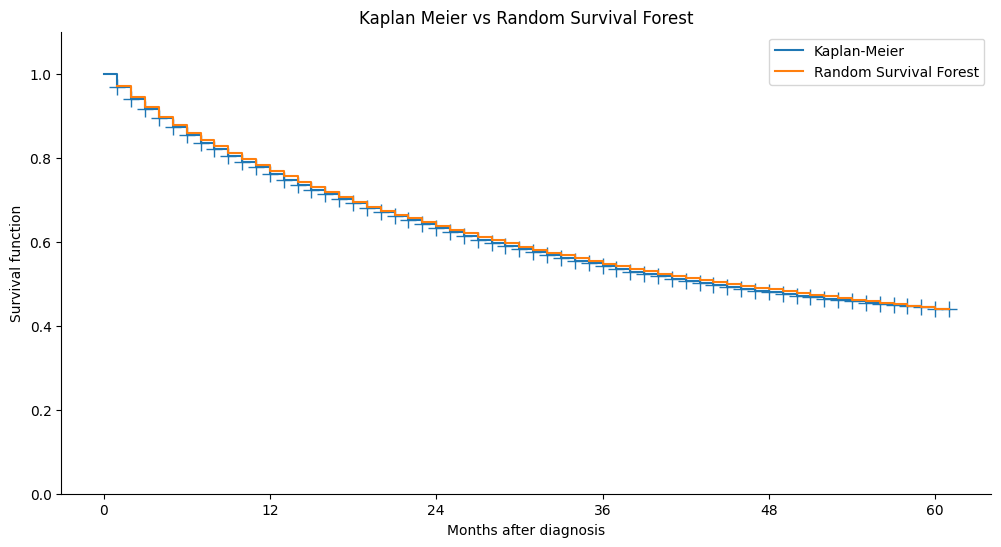

In [ ]:
# Comparação das curvas de sobrevida
name = 'Random Survival Forest'  # Nome do modelo

# Predição da função de sobrevida e cálculo da média para todos os pacientes
surv_rsf = best.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)

# Plot a curva predita e a de Kaplan-Meier
plot_survival_curve(best.unique_times_, surv_rsf_mean,
                    name=name, compare_km=True, test_df=df_teste)

## **Gradient Boosting Survival**

#### **Modelo baseline**

In [ ]:
%%time
# Gradient Boosting for Survival Analysis
gb = GradientBoostingSurvivalAnalysis(max_depth=5,  # Initializa o modelo com max depth = 5
                                      random_state=seed)  # Reprodutibilidade
gb.fit(X_train, y_train)  # Treinamento do modelo

# C-Index para o conjunto de teste
c_index_base = gb.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {gb.score(X_train, y_train)}')

C-Index Test: 0.7519445022232062
C-Index Train: 0.7643473180057578
CPU times: user 48min 1s, sys: 1.85 s, total: 48min 3s
Wall time: 48min 42s


C-Index IPCW Test: 0.7461002328477746
C-Index IPCW Train: 0.7573475524819611

Integrated Brier Score (IBS): 0.1579863443584758

Brier Score:
    > 1 year = 0.13911979290705284
    > 3 years = 0.17680795664890586
    > 5 years = 0.1777012049463648



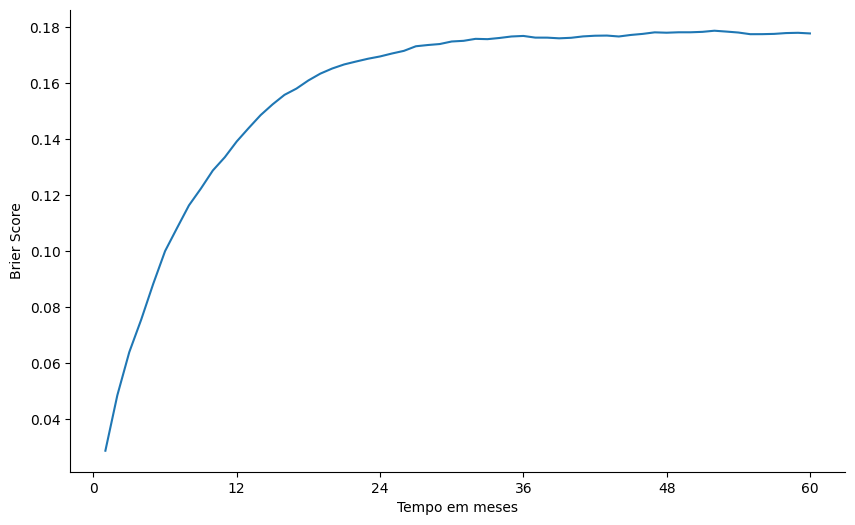

In [ ]:
# C-Index IPCW e Brier Score
c_index_ipcw_brier_score(gb, X_train, y_train, X_test, y_test)

Mean AUC: 0.79527



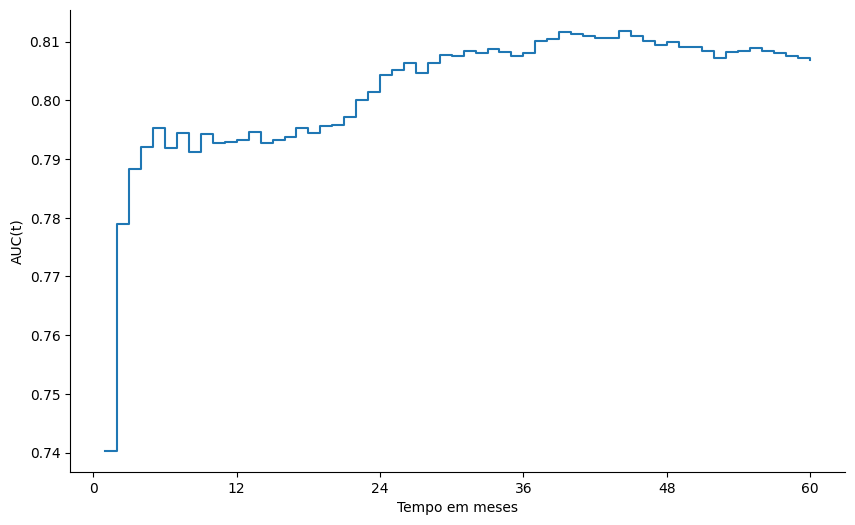

In [ ]:
# Tempos para avaliar
times = gb.unique_times_[:-1]

# Predição do modelo
est_gb = gb.predict_cumulative_hazard_function(X_test, return_array=False)
model_pred = np.vstack([chf(times) for chf in est_gb])

# Calcula a AUC tempo-dependente
auc_time_dependent(times, model_pred, y_train, y_test)

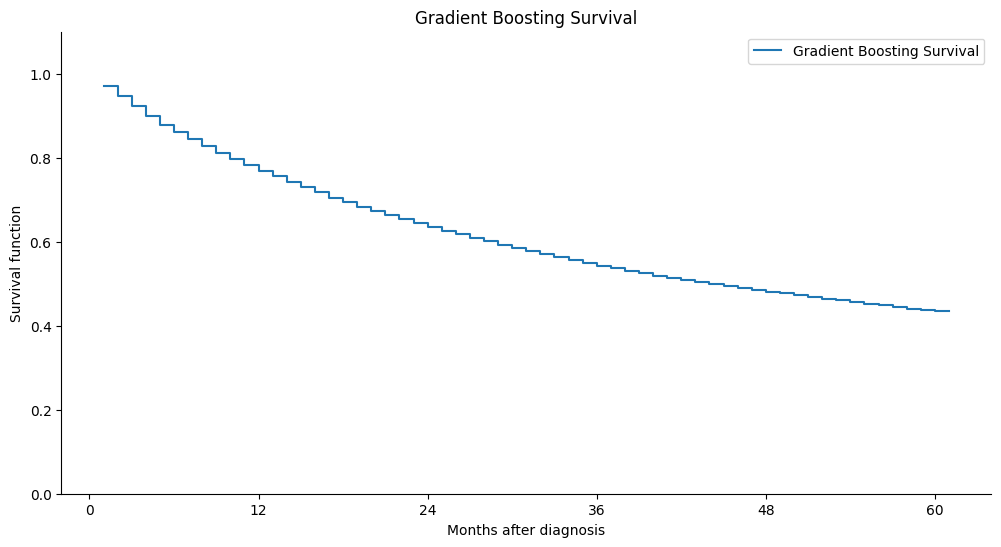

In [ ]:
# Predição de sobrevida - Curva
surv_gb = gb.predict_survival_function(X_test, return_array=True)
surv_gb_mean = surv_gb.mean(axis=0)  # Faz as médias para obter uma curva de sobrevida única

# Plot da curva de sobrevida
name = 'Gradient Boosting Survival'
plot_survival_curve(gb.unique_times_, surv_gb_mean, name=name)  # Gera e mostra a curva de sobrevida do GBSA

In [ ]:
# Probabilidade predita de sobrevida em 12, 36 e 60 meses
print(f'12: {surv_gb_mean[12]}')
print(f'36: {surv_gb_mean[36]}')
print(f'60: {surv_gb_mean[60]}')

12 months: 0.7556722494004168
36 months: 0.5364988757692224
60 months: 0.4343481373595547


#### **Optuna**

**Principais Hiperparâmetros para o Gradient Boosting Survival**
1. `n_estimators` (int)
* Descrição: Número de árvores a serem construídas. Mais árvores geralmente melhoram a precisão, mas aumentam o tempo de treinamento e risco de overfitting.
* Sugestão de valores: 50 a 1000.

2. `learning_rate` (float)
* Descrição: Taxa de aprendizado do modelo. Controla o peso de cada árvore no processo de boosting. Valores menores garantem mais estabilidade, mas exigem mais árvores.
* Sugestão de valores: 0.01 a 0.3.

3. `max_depth` (int)
* Descrição: Profundidade máxima de cada árvore. Define o quanto cada árvore pode crescer. Maior profundidade captura mais padrões complexos, mas aumenta risco de overfitting.
* Sugestão de valores: 3 a 30.

4. `min_samples_split` (int)
* Descrição: Número mínimo de amostras necessárias para dividir um nó. Evita divisões que não são significativas, controlando o crescimento da árvore.
* Sugestão de valores: 2 a 20.

5. `min_samples_leaf` (int)
* Descrição: Número mínimo de amostras necessárias para formar uma folha. Garante que cada folha contenha pelo menos uma quantidade mínima de amostras.
* Sugestão de valores: 1 a 50.

6. `subsample` (float)
* Descrição: Fração das amostras a serem usadas para treinar cada árvore. Menores frações podem ajudar a reduzir overfitting.
* Sugestão de valores: 0.5 a 1.0.

7. `max_features` (int, float, str)
* Descrição: Número ou proporção de recursos a serem considerados em cada divisão. Controla a aleatoriedade do modelo e afeta seu desempenho.
* Sugestão de valores: 'sqrt', 'log2', ou proporções de 0.1 a 1.0.

8. `loss` (str)
* Descrição: Função de perda usada no modelo.
* Sugestão de valores: 'coxph', 'squared_hinge'.

In [ ]:
# Número de tentativas
n_trials = 150

In [ ]:
# Folds para validação cruzada
kf = KFold(10, shuffle=True, random_state=seed)

# Função para calcular o C-Index
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)
    return cindex

# Função objetivo para otimização de hiperparâmetros
def objective(trial):
    # Define os hiperparâmetros que serão otimizados
    n_estimators = trial.suggest_int('n_estimators', 50, 130)  # Número de árvores
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01)  # Taxa de aprendizado
    max_depth = trial.suggest_int('max_depth', 3, 5)  # Profundidade máxima de cada árvore
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)  # Número mínimo de amostras necessárias para dividir um nó
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10)  # Número mínimo de amostras necessárias em um nó de folhas
    subsample = trial.suggest_float('subsample', 0.5, 1.0, step=0.1)  # Fração de exemplos usados em cada árvore
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Quantidade de features usadas em cada árvore

    # Cria e treina o modelo com os hiperparâmetros escolhidos
    gbsa = GradientBoostingSurvivalAnalysis(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        max_features=max_features,
        random_state=seed
    )

    # Realiza a validação cruzada e retorna o valor médio do C-Index
    return cross_val_score(gbsa, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - RandomSampler
# study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
#                             study_name='GBS_RandomSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'colo_opt_gbs_rand.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
                                study_name='GBS_RandomSampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 7.81 s, sys: 25.7 ms, total: 7.84 s
Wall time: 232 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 117, 'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 9, 'subsample': 1.0, 'max_features': 0.75}


In [ ]:
%%time
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
gbsa_rand = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
gbsa_rand.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_rand = gbsa_rand.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {gbsa_rand.score(X_train, y_train)}')

C-Index Test: 0.7587219317380547
C-Index Train: 0.7782932339492928
CPU times: user 41min 49s, sys: 1.01 s, total: 41min 50s
Wall time: 42min 9s


**TPESampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - TPESampler
# study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
#                             study_name='GBS_TPESampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'colo_opt_gbs_tpe.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='GBS_TPESampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 2.54 s, sys: 0 ns, total: 2.54 s
Wall time: 79.5 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 108, 'learning_rate': 0.19, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 8, 'subsample': 0.7, 'max_features': 1.0}


In [ ]:
%%time
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
gbsa_tpe = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
gbsa_tpe.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_tpe = gbsa_tpe.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {gbsa_tpe.score(X_train, y_train)}')

C-Index Test: 0.7587277416779152
C-Index Train: 0.7773527523202264
CPU times: user 31min 55s, sys: 822 ms, total: 31min 56s
Wall time: 32min 3s


**CmaEsSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - CmaEsSampler
# study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
#                             study_name='GBS_CmaEsSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'colo_opt_gbs_cma.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='GBS_CmaEsSampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 12.7 ms, sys: 0 ns, total: 12.7 ms
Wall time: 16 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 111, 'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 6, 'subsample': 0.9, 'max_features': 0.5}


In [ ]:
%%time
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
gbsa_cma = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
gbsa_cma.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_cma = gbsa_cma.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {gbsa_cma.score(X_train, y_train)}')

C-Index Test: 0.7588309162059692
C-Index Train: 0.7769290502442211
CPU times: user 36min 41s, sys: 758 ms, total: 36min 42s
Wall time: 36min 57s


#### **Melhor Gradient Boosting Survival**

In [ ]:
# Melhor modelo RSF
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # Lista de C-Index para os modelos GBSA
models = [gb, gbsa_rand, gbsa_tpe, gbsa_cma]  # Lista de modelos

# Encontrando o melhor modelo a partir do maior C-Index
id_best_score = scores.index(max(scores))
best = models[id_best_score]

# Mostra o modelo selecionado
print(best)

GradientBoostingSurvivalAnalysis(learning_rate=0.2, max_depth=5,
                                 max_features=0.5, min_samples_leaf=6,
                                 min_samples_split=5, n_estimators=111,
                                 random_state=1, subsample=0.9)


In [ ]:
!gdown 1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a

with open('colorretal.pkl', 'rb') as f:
    colo = pickle.load(f)

best = colo['gb']
best

Downloading...
From (original): https://drive.google.com/uc?id=1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a
From (redirected): https://drive.google.com/uc?id=1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a&confirm=t&uuid=31c20d02-6020-4580-b18c-b13bbfc83e1c
To: /content/colorretal.pkl
100% 114M/114M [00:02<00:00, 39.8MB/s]


,loss,'coxph'
,learning_rate,0.2
,n_estimators,111
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,5
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,random_state,1


C-Index Test: 0.7588309162059692
C-Index Train: 0.7769290502442211

C-Index IPCW Test: 0.7525671954132044
C-Index IPCW Train: 0.7699414656611409

Integrated Brier Score (IBS): 0.15518065181192547

Brier Score:
    > 1 year = 0.13696842471438048
    > 3 years = 0.17350604846071546
    > 5 years = 0.17530808938267675



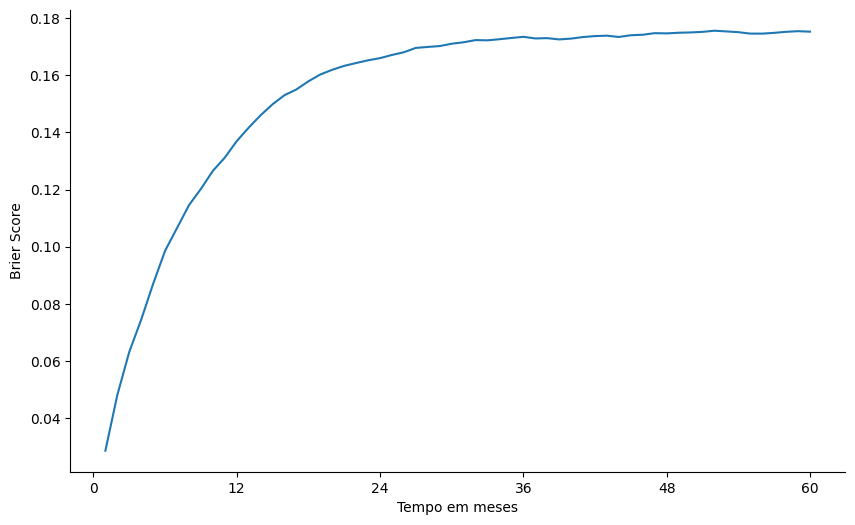

In [ ]:
# Métrics para o melhor modelo GBSA
# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {best.score(X_test, y_test)}')
print(f'C-Index Train: {best.score(X_train, y_train)}\n')

# Cálculo do C-Index IPCW e Brier Score
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test, save=True)

Mean AUC: 0.80372



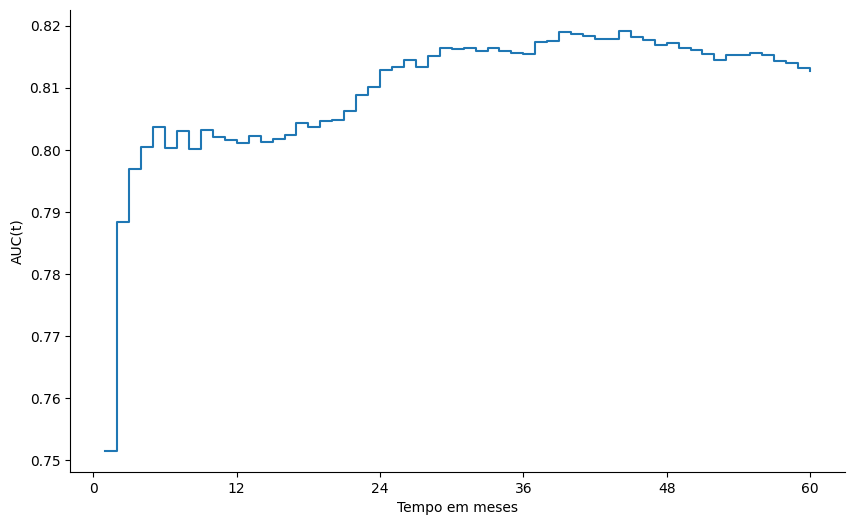

In [ ]:
# Seleciona os tempos únicos observados pelo modelo, removendo o último valor
# Essa remoção pode ser útil para evitar problemas em métricas avaliadas no limite máximo do seguimento
times = best.unique_times_[:-1]

# Prediz a função de risco acumulado para os pacientes do conjunto de teste
# return_array=False retorna uma lista de funções, uma para cada paciente
est_gb = best.predict_cumulative_hazard_function(X_test, return_array=False)

# Avalia a função de risco acumulado de cada paciente nos tempos definidos em 'times'
model_pred = np.vstack([chf(times) for chf in est_gb])

# Calcula a AUC tempo-dependente usando:
# - times: tempos em que a métrica será avaliada
# - model_pred: predições de risco acumulado dos pacientes ao longo do tempo
# - y_train: dados de sobrevida do conjunto de treino, usados como referência para lidar com censura
# - y_test: dados de sobrevida do conjunto de teste, usados para avaliar o desempenho
# save=True indica que o resultado ou gráfico gerado pela função será salvo
auc_time_dependent(times, model_pred, y_train, y_test, save=True)

In [ ]:
# # Feature Importances
# feat_import = pd.Series(best.feature_importances_, index=feat_cols)  # Create a pandas Series with feature importances
# feat_import.nlargest(15).plot(kind='barh', figsize=(10, 8))  # Plot the top 15 most important features as a horizontal bar chart
# plt.show()  # Display the plot

In [ ]:
# Melhores features pelo permutation importance
pi_gbsa = calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model
pi_gbsa

,importances_mean,importances_std
EC,0.167131,0.002735
IDADE,0.026915,0.001240
CATEATEND,0.014432,0.001389
INSTITU,0.010614,0.000582
DIAGTRAT_CAT,0.009201,0.001291
TRATCONS_CAT,0.004542,0.000599
TOPO,0.004487,0.000427
ANODIAG,0.004321,0.000687
IBGEATEN,0.003498,0.000367
DIAGPREV,0.003130,0.000412


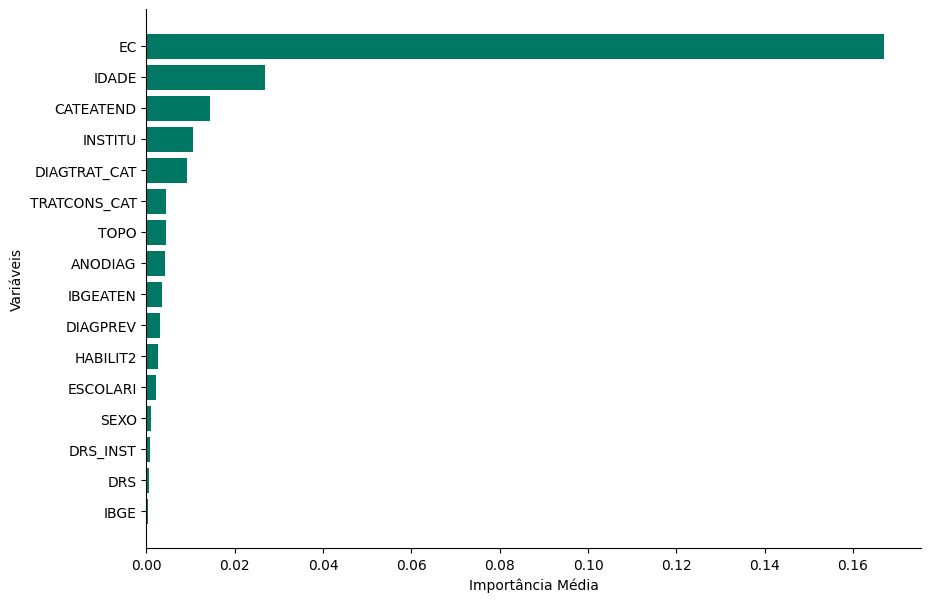

In [ ]:
# Cria uma nova coluna chamada 'features' a partir do índice do DataFrame
# Essa coluna armazenará os nomes das variáveis para facilitar a plotagem
pi_gbsa['features'] = pi_gbsa.index

# Cria a figura e o eixo do gráfico com tamanho personalizado
fig, ax = plt.subplots(figsize=(10, 7))

# Gera um gráfico de barras horizontais com:
# - eixo y: nomes das variáveis
# - eixo x: média das importâncias calculadas
ax.barh(pi_gbsa['features'], pi_gbsa['importances_mean'], color='#007863')

# Define o rótulo do eixo x
ax.set_xlabel('Importância Média')

# Define o rótulo do eixo y
ax.set_ylabel('Variáveis')

# Inverte a ordem do eixo y para que as variáveis mais importantes apareçam no topo
ax.invert_yaxis()

# Remove a borda superior do gráfico
ax.spines['top'].set_visible(False)

# Remove a borda direita do gráfico
ax.spines['right'].set_visible(False)

# Salva o gráfico em um arquivo de imagem
plt.savefig('gbsa_pi.jpg')

PermutationExplainer explainer: 8973it [21:40,  6.87it/s]


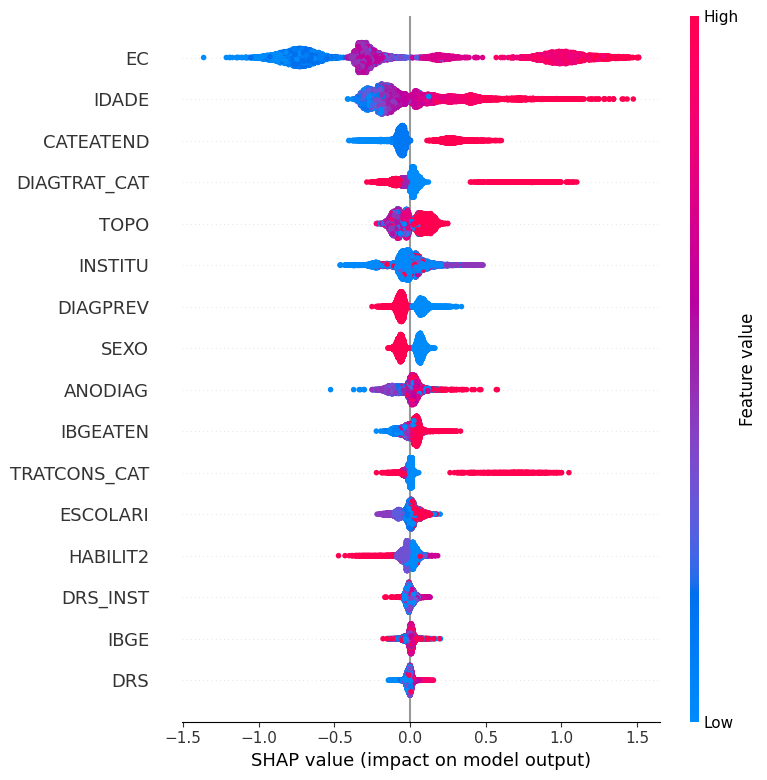

In [ ]:
# Melhores features pelo SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,
                           output_names=feat_cols, n_jobs=-1)

# Calcula os valores SHAP para os pacientes do conjunto de teste
shap_values = explainer(X_test)

# Gera o gráfico resumo do SHAP
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

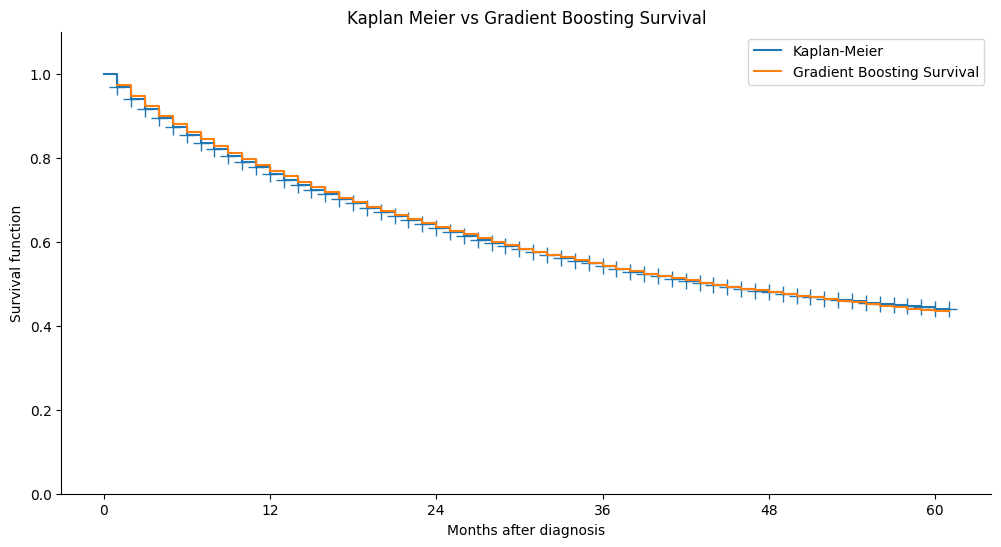

In [ ]:
# Comparação das curvas de sobrevida
name = 'Gradient Boosting Survival'  # Nome do modelo

# Predição da função de sobrevida e cálculo da média para todos os pacientes
surv_gbs = best.predict_survival_function(X_test, return_array=True)
surv_gbs_mean = surv_gbs.mean(axis=0)

# Plot da curva predita e da de Kaplan-Meier
plot_survival_curve(best.unique_times_, surv_gbs_mean,
                    name=name, compare_km=True, test_df=df_teste)

## **Survival SVM**

#### **Modelo baseline**

In [ ]:
# Survival SVM
ssvm = FastSurvivalSVM(random_state=seed)  # Initializa o modelo
ssvm.fit(X_train, y_train)  # Treinamento do modelo

# C-Index para o conjunto de teste
c_index_base = ssvm.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {ssvm.score(X_train, y_train)}')

C-Index Test: 0.7088418088812972
C-Index Train: 0.7140363897668406


In [ ]:
# C-Index IPCW
surv_risks = ssvm.predict(X_test)  # Predição para o conjunto de teste
surv_risks_train = ssvm.predict(X_train)  # Predição para o conjunto de treino

# Cálculo do C-Index IPCW
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)

# Print do C-Index IPCW para os conjuntos de teste e de treinamento
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')

C-Index IPCW Test: 0.7035689517806477
C-Index IPCW Train: 0.7080728430532487


Mean AUC: 0.74584



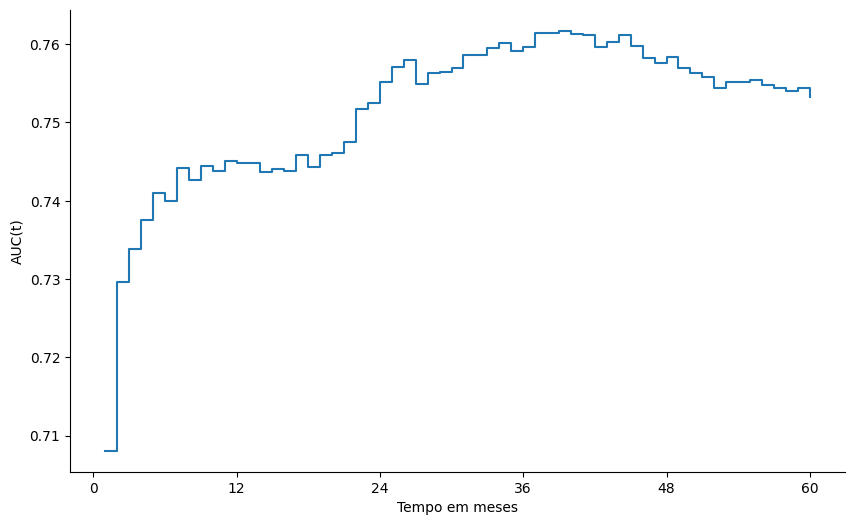

In [ ]:
# Tempos para avaliar
times = gb.unique_times_[:-1]

# Predição do modelo
model_pred = ssvm.predict(X_test)

# Calcula a AUC tempo-dependente
auc_time_dependent(times, model_pred, y_train, y_test)

Brier Score at 12 months: 0.1549586946491249
Brier Score at 36 months: 0.19824470036319844
Brier Score at 60 months: 0.2013479972521965

Integrated Brier Score (IBS): 0.1773698437603265


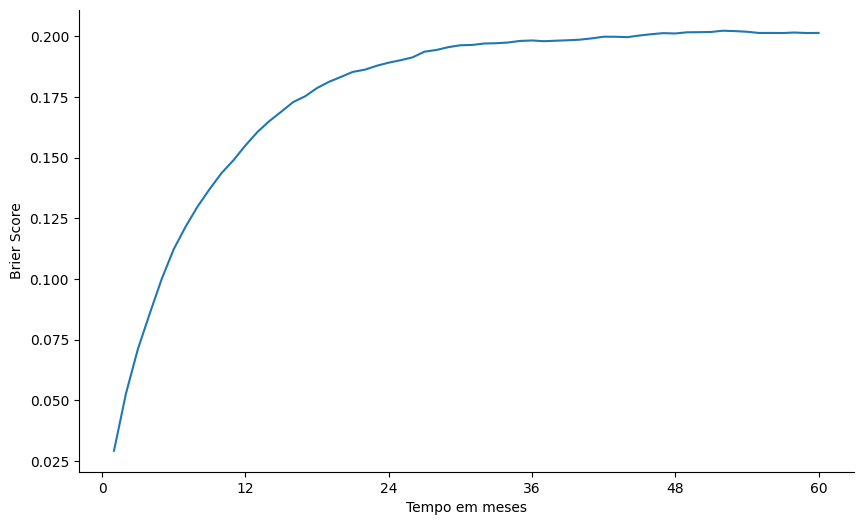

In [ ]:
from sksurv.util import Surv

# Seleciona o indicador de evento do conjunto de teste
event = y_test["event"]

# Seleciona o tempo até o evento ou censura do conjunto de teste
time = y_test["time"]

# Cria um DataFrame no formato esperado pelo modelo de Cox
df_cox = pd.DataFrame({
    "time": time,              # Tempo de acompanhamento/sobrevida
    "event": event,            # Indicador de evento ou censura
    "ssvm_score": surv_risks   # Escore de risco predito pelo modelo SSVM
})

# Inicializa o modelo de riscos proporcionais de Cox
cox = CoxPHFitter()

# Ajusta o modelo de Cox
cox.fit(df_cox, duration_col="time", event_col="event")

# Prediz as funções de sobrevida individuais a partir do modelo de Cox ajustado
surv_funcs = cox.predict_survival_function(df_cox)

# Remove o último ponto temporal da curva
surv_funcs.drop(surv_funcs.index[-1], axis=0, inplace=True)

# Calcula a curva média de sobrevida estimada pelo modelo SSVM calibrado via Cox
surv_ssvm_mean = surv_funcs.mean(axis=1)

# Define os tempos em que o Brier Score será avaliado
time_points = np.arange(1, 61, 1)

# Organiza as predições de sobrevida no formato esperado pelas funções de Brier Score
surv_preds = surv_funcs.values.T

# Calcula o Brier Score ao longo do tempo
brier_scores = brier_score(
    y_train,      # Dados de treino usados para estimar a distribuição da censura
    y_test,       # Dados de teste usados na avaliação
    surv_preds,   # Probabilidades de sobrevida preditas para cada paciente e tempo
    time_points   # Tempos de avaliação
)

# Calcula o Integrated Brier Score, que resume o Brier Score ao longo do tempo
ibs = integrated_brier_score(
    y_train,
    y_test,
    surv_preds,
    time_points
)

# Exibe o Brier Score no tempo de 12 meses
print(f"Brier Score at 12 months: {brier_scores[1][11]}")

# Exibe o Brier Score no tempo de 36 meses
print(f"Brier Score at 36 months: {brier_scores[1][35]}")

# Exibe o Brier Score no tempo de 60 meses
print(f"Brier Score at 60 months: {brier_scores[1][59]}")

# Exibe o Integrated Brier Score
print(f"\nIntegrated Brier Score (IBS): {ibs}")

fig, ax = plt.subplots(figsize=(10, 6))  # Cria a figura e o eixo do gráfico com tamanho personalizado
ax.plot(brier_scores[0], brier_scores[1])  # Plota o Brier Score ao longo do tempo
ax.set_xlabel('Tempo em meses')  # Define o rótulo do eixo x
ax.set_ylabel('Brier Score')  # Define o rótulo do eixo y
ax.spines['top'].set_visible(False)  # Remove a borda superior do gráfico
ax.spines['right'].set_visible(False)  # Remove a borda direita do gráfico
ax.set_xticks(np.arange(0, time_points[-1] + 11, 12))  # Define os marcadores do eixo x de 12 em 12 meses
plt.show()  # Exibe o gráfico

#### **Optuna**

**Principais Parâmetros a Otimizar no SVM Survival**

1. `alpha` (float):
* Parâmetro de regularização que controla o grau de penalidade aplicada aos coeficientes do modelo. Um valor maior aumenta a penalização, reduzindo o risco de overfitting, mas pode subajustar os dados.
* Sugestão: 0.0001 a 10 (testando uma faixa logarítmica).

2. `rank_ratio` (float):
* Fração dos pares que serão usados durante o treinamento para estimar a função de perda do ranking. Define a proporção de pares que o algoritmo considera. Menores valores podem acelerar o treinamento, mas prejudicar a precisão.
* Sugestão: 0.1 a 1.0.

3. `max_iter` (int):
* Número máximo de iterações para o otimizador. Define o número de iterações do algoritmo de otimização. Muitos passos podem melhorar a solução, mas aumentam o custo computacional.
* Sugestão: 100 a 2000.

4. `tol` (float):
* Critério de tolerância para a convergência. Quanto menor, mais preciso será o ajuste, mas pode tornar a convergência mais lenta.
* Sugestão: 1e-5 a 1e-2.

In [ ]:
# Número de tentativas
n_trials = 150

In [ ]:
# Folds para validação cruzada
kf = KFold(10, shuffle=True, random_state=seed)

# Função para calcular o C-Index
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)
    return cindex

# Função objetivo para otimização de hiperparâmetros
def objective(trial):
    # Define os hiperparâmetros que serão otimizados
    param = {
        'alpha': trial.suggest_categorical('alpha', [1e-3, 1e-2, 1e-1, 1, 10]),  # Parâmetro de regularização
        'rank_ratio': trial.suggest_float('rank_ratio', 0.1, 1.0, step=0.05),  # Rank ratio
        'tol': trial.suggest_categorical('tol', [1e-5, 1e-4, 1e-3, 1e-2]),  # Tolerância
    }

    # Cria e treina o modelo com os hiperparâmetros escolhidos
    ssvm = FastSurvivalSVM(**param, random_state=seed)

    # Realiza a validação cruzada e retorna o valor médio do C-Index
    return cross_val_score(ssvm, X_train, y_train, cv=kf, scoring=c_index).mean()  # Return the mean cross-validated C-index score

**RandomSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - RandomSampler
# study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
#                             study_name='SSVM_RandomSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'colo_opt_svm_rand.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
                                study_name='SSVM_RandomSampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 21.5 ms, sys: 2.96 ms, total: 24.4 ms
Wall time: 26.6 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 0.1, 'rank_ratio': 0.25, 'tol': 0.0001}


In [ ]:
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
ssvm_rand = FastSurvivalSVM(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
ssvm_rand.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_rand = ssvm_rand.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {ssvm_rand.score(X_train, y_train)}')

C-Index Test: 0.7088417511666628
C-Index Train: 0.7140349299888415


**TPESampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - TPESampler
# study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
#                             study_name='SSVM_TPESampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'colo_opt_svm_tpe.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='SSVM_TPESampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 21.3 ms, sys: 0 ns, total: 21.3 ms
Wall time: 31.5 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 0.1, 'rank_ratio': 0.25, 'tol': 0.0001}


In [ ]:
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
ssvm_tpe = FastSurvivalSVM(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
ssvm_tpe.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_tpe = ssvm_tpe.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {ssvm_tpe.score(X_train, y_train)}')

C-Index Test: 0.7088417511666628
C-Index Train: 0.7140349299888415


**CmaEsSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - CmaEsSampler
# study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
#                             study_name='SSVM_CmaEsSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Nome do arquivo pickle para salvar o estudo
pickle_filename = 'colo_opt_svm_cma.pkl'

# Carrega um estudo existente ou cria um novo
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='SSVM_CmaEsSampler')

# Número total de tentativas completas
completed_trials = len(study.trials)

# Executa as tentativas remanescentes em lotes
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Salva o estudo após cada lote
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 13.5 ms, sys: 0 ns, total: 13.5 ms
Wall time: 13.5 ms


In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 0.1, 'rank_ratio': 0.25, 'tol': 0.0001}


In [ ]:
# Treinamento e validação com os melhores hiperparâmetros
best_params = study.best_params  # Salva os hiperparâmetros encontrados
ssvm_cma = FastSurvivalSVM(**best_params, random_state=seed)  # Inicializa o modelo com os parâmetros selecionados
ssvm_cma.fit(X_train, y_train)  # Treinamento do modelo

# Cáculo do C-Index para o conjunto de teste
c_index_cma = ssvm_cma.score(X_test, y_test)

# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {ssvm_cma.score(X_train, y_train)}')

C-Index Test: 0.7088417511666628
C-Index Train: 0.7140349299888415


#### **Melhor Survival SVM**

In [ ]:
# Melhor modelo SSVM
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # Lista de C-Index para os modelos SSVM
models = [ssvm, ssvm_rand, ssvm_tpe, ssvm_cma]  # Lista de modelos

# Encontrando o melhor modelo a partir do maior C-Index
id_best_score = scores.index(max(scores))
best = models[id_best_score]

# Mostra o modelo selecionado
print(best)

FastSurvivalSVM(optimizer='avltree', random_state=1)


In [ ]:
# Métrics para o melhor modelo SSVM
# Print do C-index para os conjuntos de teste e de treinamento
print('C-Index')
print(f'> Test: {best.score(X_test, y_test)}')
print(f'> Train: {best.score(X_train, y_train)}')

# Cálculo do C-Index IPCW
surv_risks = best.predict(X_test)
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)

surv_risks_train = best.predict(X_train)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')
print(f'> Train: {c_index_ipcw_train[0]}')

C-Index
> Test: 0.7088418088812972
> Train: 0.7140363897668406

C-Index IPCW
> Test: 0.7035689517806477
> Train: 0.7080728430532487


Brier Score at 12 months: 0.1549586946491249
Brier Score at 36 months: 0.19824470036319844
Brier Score at 60 months: 0.2013479972521965

Integrated Brier Score (IBS): 0.1773698437603265


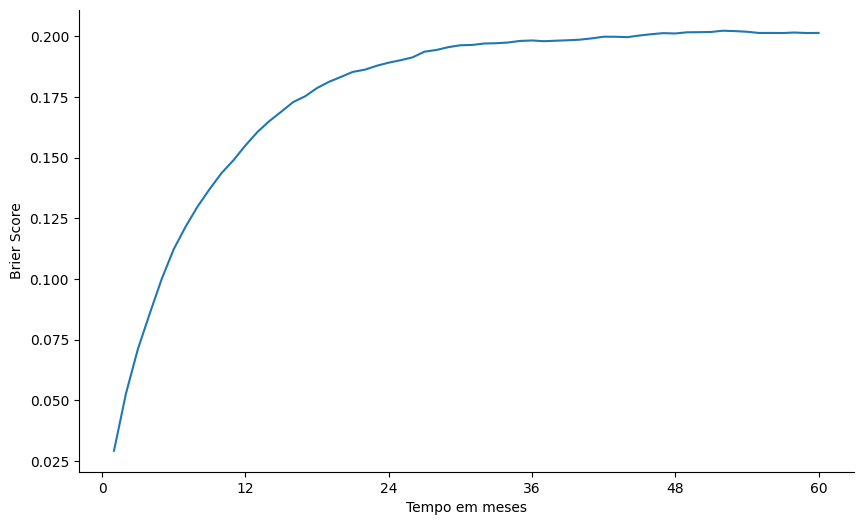

In [ ]:
from sksurv.util import Surv

# Seleciona o indicador de evento do conjunto de teste
event = y_test["event"]

# Seleciona o tempo até o evento ou censura do conjunto de teste
time = y_test["time"]

# Cria um DataFrame no formato esperado pelo modelo de Cox
df_cox = pd.DataFrame({
    "time": time,              # Tempo de acompanhamento/sobrevida
    "event": event,            # Indicador de evento ou censura
    "ssvm_score": surv_risks   # Escore de risco predito pelo modelo SSVM
})

# Inicializa o modelo de riscos proporcionais de Cox
cox = CoxPHFitter()

# Ajusta o modelo de Cox
cox.fit(df_cox, duration_col="time", event_col="event")

# Prediz as funções de sobrevida individuais a partir do modelo de Cox ajustado
surv_funcs = cox.predict_survival_function(df_cox)

# Remove o último ponto temporal da curva
surv_funcs.drop(surv_funcs.index[-1], axis=0, inplace=True) #Censoring month 61

# Calcula a curva média de sobrevida estimada pelo modelo SSVM calibrado via Cox
surv_ssvm_mean = surv_funcs.mean(axis=1)

# Define os tempos em que o Brier Score será avaliado
time_points = np.arange(1, 61, 1)

# Organiza as predições de sobrevida no formato esperado pelas funções de Brier Score
surv_preds = surv_funcs.values.T

# Calcula o Brier Score ao longo do tempo
brier_scores = brier_score(
    y_train,      # Dados de treino usados para estimar a distribuição da censura
    y_test,       # Dados de teste usados na avaliação
    surv_preds,   # Probabilidades de sobrevida preditas para cada paciente e tempo
    time_points   # Tempos de avaliação
)

# Calcula o Integrated Brier Score, que resume o Brier Score ao longo do tempo
ibs = integrated_brier_score(
    y_train,
    y_test,
    surv_preds,
    time_points
)

# Exibe o Brier Score no tempo de 12 meses
print(f"Brier Score at 12 months: {brier_scores[1][11]}")

# Exibe o Brier Score no tempo de 36 meses
print(f"Brier Score at 36 months: {brier_scores[1][35]}")

# Exibe o Brier Score no tempo de 60 meses
print(f"Brier Score at 60 months: {brier_scores[1][59]}")

# Exibe o Integrated Brier Score
print(f"\nIntegrated Brier Score (IBS): {ibs}")

fig, ax = plt.subplots(figsize=(10, 6))  # Cria a figura e o eixo do gráfico com tamanho personalizado
ax.plot(brier_scores[0], brier_scores[1])  # Plota o Brier Score ao longo do tempo
ax.set_xlabel('Tempo em meses')  # Define o rótulo do eixo x
ax.set_ylabel('Brier Score')  # Define o rótulo do eixo y
ax.spines['top'].set_visible(False)  # Remove a borda superior do gráfico
ax.spines['right'].set_visible(False)  # Remove a borda direita do gráfico
ax.set_xticks(np.arange(0, time_points[-1] + 11, 12))  # Define os marcadores do eixo x de 12 em 12 meses

plt.savefig('brier_score.jpg')

Mean AUC: 0.74584



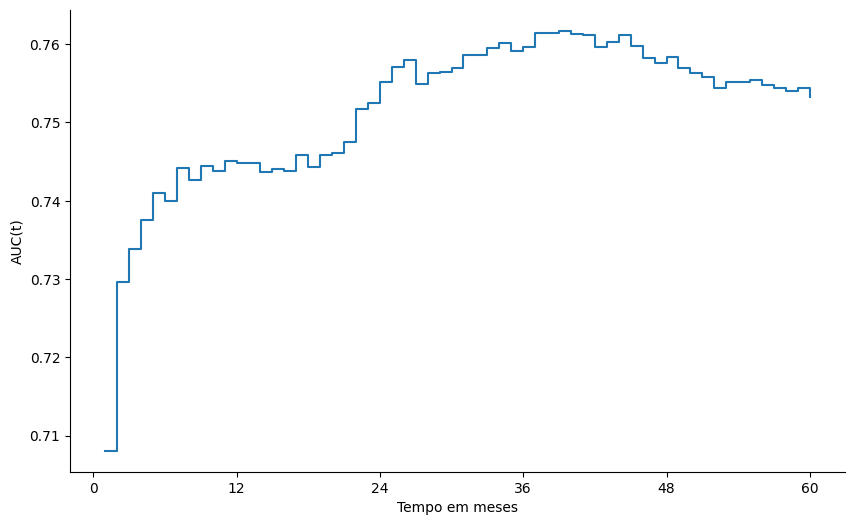

In [ ]:
# Define os tempos em que a AUC tempo-dependente será avaliada
# Neste caso, utiliza os pontos de tempo previamente definidos em 'time_points'
times = time_points

# Gera as predições do modelo para os pacientes do conjunto de teste
# Para alguns modelos de sobrevida, o método predict retorna um escore de risco para cada paciente
model_pred = best.predict(X_test)

# Calcula a AUC tempo-dependente usando:
# - times: tempos em que a métrica será calculada
# - model_pred: predições do modelo, geralmente representando o risco estimado de cada paciente
# - y_train: dados de sobrevida do conjunto de treino, usados como referência para lidar com a censura
# - y_test: dados de sobrevida do conjunto de teste, usados para avaliar o desempenho do modelo
# - save=True: indica que o resultado ou gráfico gerado pela função será salvo
auc_time_dependent(times, model_pred, y_train, y_test, save=True)

In [ ]:
# Melhores features pelo permutation importance
pi_ssvm = calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model
pi_ssvm

,importances_mean,importances_std
EC,0.161662,0.003115
IDADE,0.022160,0.001788
CATEATEND,0.016051,0.001550
TRATCONS_CAT,0.006716,0.000640
DIAGPREV,0.006185,0.000821
IBGEATEN,0.000990,0.000358
HABILIT2,0.000844,0.000289
SEXO,0.000771,0.000251
DRS,0.000155,0.000127
INSTITU,0.000061,0.000072


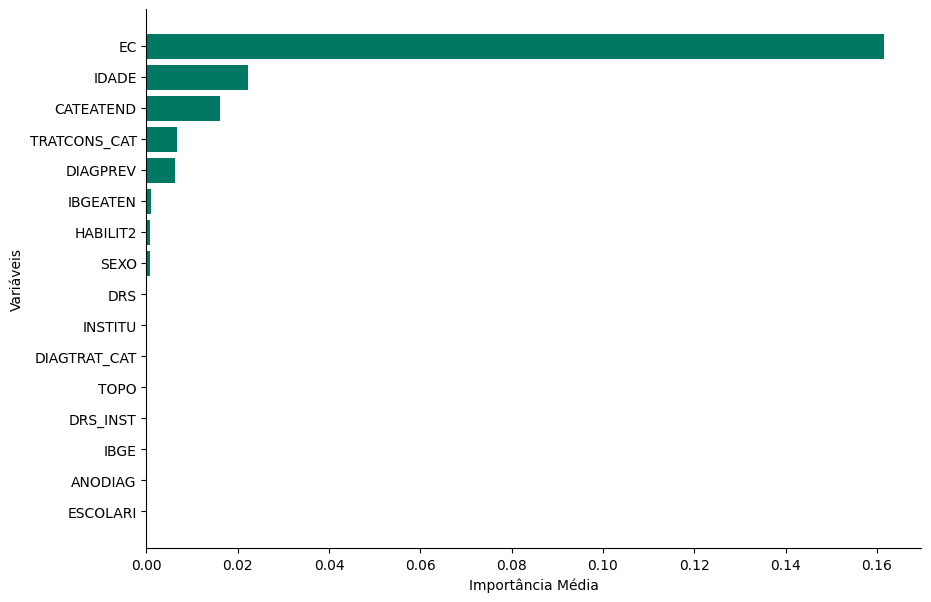

In [ ]:
# Cria uma nova coluna chamada 'features' a partir do índice do DataFrame
# Essa coluna armazenará os nomes das variáveis para facilitar a plotagem
pi_ssvm['features'] = pi_ssvm.index

# Cria a figura e o eixo do gráfico com tamanho personalizado
fig, ax = plt.subplots(figsize=(10, 7))

# Gera um gráfico de barras horizontais com:
# - eixo y: nomes das variáveis
# - eixo x: média das importâncias calculadas
ax.barh(pi_ssvm['features'], pi_ssvm['importances_mean'], color='#007863')

# Define o rótulo do eixo x
ax.set_xlabel('Importância Média')

# Define o rótulo do eixo y
ax.set_ylabel('Variáveis')

# Inverte a ordem do eixo y para que as variáveis mais importantes apareçam no topo
ax.invert_yaxis()

# Remove a borda superior do gráfico
ax.spines['top'].set_visible(False)

# Remove a borda direita do gráfico
ax.spines['right'].set_visible(False)

# Salva o gráfico em um arquivo de imagem
plt.savefig('ssvm_pi.jpg')

PermutationExplainer explainer: 8973it [01:28, 89.70it/s]                           


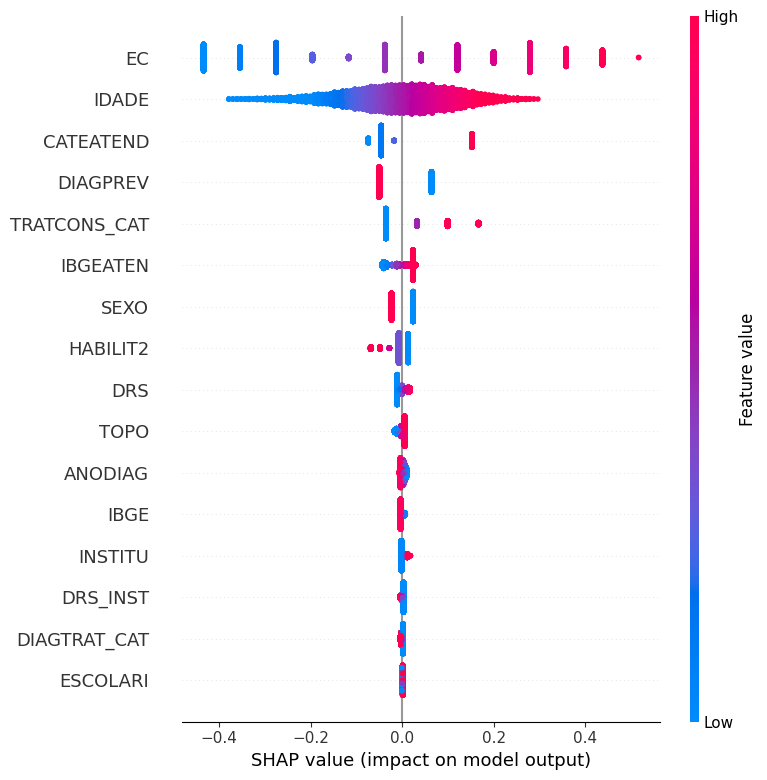

In [ ]:
# Melhores features pelo SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,
                           output_names=feat_cols, n_jobs=-1)

# Calcula os valores SHAP para os pacientes do conjunto de teste
shap_values = explainer(X_test)

# Gera o gráfico resumo do SHAP
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

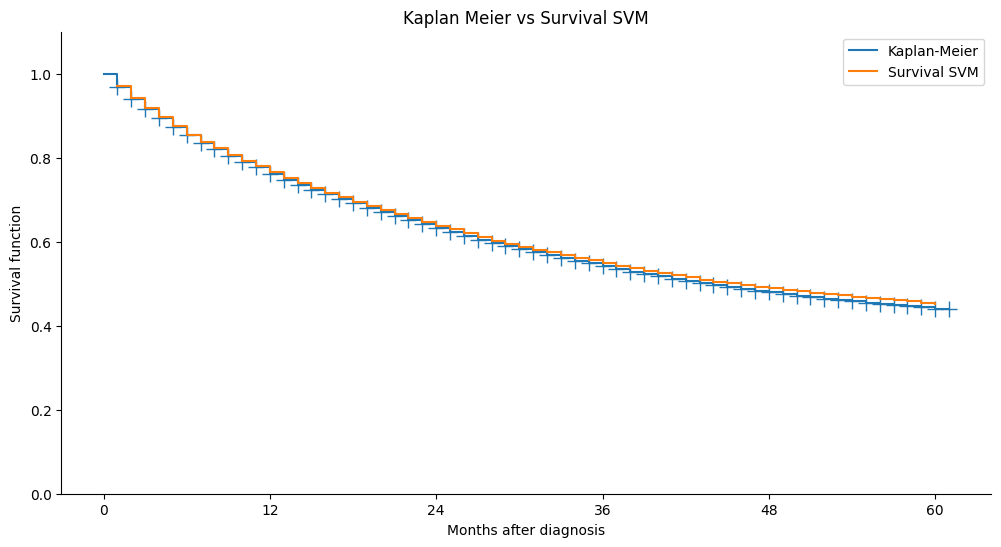

In [ ]:
# Comparação das curvas de sobrevida
name = 'Survival SVM'  # Nome do modelo

# Criação da figura
fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

# Kaplan-Meier
E = (df_teste.obito_geral == 1)  # Definição do evento
T = df_teste.meses_diag  # Definição do tempo

# Inicialização do KM, treinamento e plot da curva
kmf = KaplanMeierFitter()
ax = kmf.fit(T, E).plot_survival_function(ax=ax, ci_show=False,
                                          show_censors=True,
                                          label='Kaplan-Meier')
title = f'Kaplan Meier vs {name}'  # Título do gráfico

# Curva de sobrevida predita pelo modelo
ax.step(time_points, surv_ssvm_mean, where='post', label=name)

# Ajustes do plot
ax.set_title(title)  # Título
ax.set_xlabel('Months after diagnosis')  # Rótulo eixo x
ax.set_ylabel('Survival function')  # Rótulo eixo y
ax.spines['top'].set_visible(False)  # Remove a borda superior do gráfico
ax.spines['right'].set_visible(False)  # Remove a borda direita do gráfico
plt.xticks(np.arange(0, time_points[-1] + 11, 12))  # Eixo x com marcadores a cada 12 meses
plt.ylim([0, 1.1])  # Limites do eixo y
plt.legend();  # Mostra a legenda

## **XGBoost - Cox**

#### **Modelo baseline**

In [ ]:
# XGBoost-Cox

# Define pesos para as observações do conjunto de treino com base no status do evento
# Pacientes que tiveram o evento recebem peso 1.0. Pacientes censurados recebem peso 0.25
weights = np.where(y_train['event'], 1.0, 0.25)

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino
# y_train['time'] é usado como variável alvo, representando o tempo até o evento ou censura
# weight=weights informa ao modelo os pesos definidos para eventos e censuras
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)

# Cria a estrutura DMatrix do XGBoost para o conjunto de teste
# Não é necessário informar o label, pois este conjunto será usado apenas para predição
dtest = xgb.DMatrix(X_test)

# Define os parâmetros do modelo XGBoost para análise de sobrevida
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'max_depth': 3,
    'seed': seed
    }

# Treina o modelo XGBoost-Cox usando o conjunto de treino
xgboost = xgb.train(params, dtrain, num_boost_round=100)

# Gera as predições para o conjunto de teste
# No objetivo survival:cox, as predições representam escores de risco
y_pred = xgboost.predict(dtest)

# Calcula o C-Index no conjunto de teste
# Essa métrica avalia a capacidade do modelo de ordenar corretamente os pacientes pelo risco
c_index_base = concordance_index_censored(y_test['event'], y_test['time'],
                                          y_pred)[0]

# Gera as predições para o conjunto de treino
y_pred_train = xgboost.predict(dtrain)

# Calcula o C-Index no conjunto de treino
# Esse valor pode ser comparado com o desempenho no teste para avaliar possível overfitting
c_index_train = concordance_index_censored(y_train['event'], y_train['time'],
                                           y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.7230960538503702
C-index Train: 0.7358208866376148


In [ ]:
# C-Index IPCW
surv_risks = xgboost.predict(dtest)  # Predição para o conjunto de teste
surv_risks_train = xgboost.predict(dtrain)  # Predição para o conjunto de treino

# Cálculo do C-Index IPCW
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)

# Print do C-Index IPCW para os conjuntos de teste e de treinamento
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')

C-Index IPCW Test: 0.7178736764045422
C-Index IPCW Train: 0.7286902448291878


Mean AUC: 0.79231



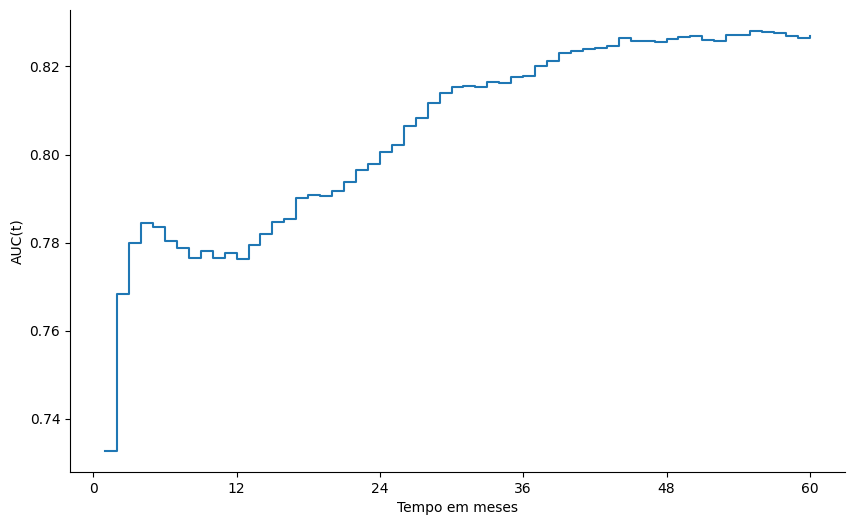

In [ ]:
# Tempos para avaliar
time_points = np.arange(1, 61, 1)

# Predição do modelo
y_pred = xgboost.predict(dtest)

# Calcula a AUC tempo-dependente
auc_time_dependent(time_points, y_pred, y_train, y_test)

#### **Optuna**

**Principais Parâmetros a Otimizar no XGBoost**

1. `n_estimators` (int):
* Número de árvores (boosting rounds) que o modelo vai treinar. Mais árvores podem melhorar o aprendizado, mas aumentam o risco de overfitting e o custo computacional.
* Sugestão de valores: 50 a 1000.

2. `learning_rate` (float):
* Taxa de aprendizado usada para diminuir a contribuição de cada árvore. Taxas menores exigem mais árvores, mas aumentam a estabilidade.
* Sugestão de valores: 0.01 a 0.3 (log-scale).

3. `max_depth` (int):
* Profundidade máxima das árvores individuais. Árvores mais profundas captam interações complexas, mas correm maior risco de overfitting.
* Sugestão de valores: 3 a 30.

4. `min_child_weight` (float):
* Peso mínimo da soma dos gradientes (hessian) em uma divisão de nó. Controla o tamanho mínimo de uma divisão, evitando overfitting.
* Sugestão de valores: 1 a 10.

5. `subsample` (float):
* Percentual de amostras utilizadas em cada árvore. Reduz overfitting ao amostrar dados de forma aleatória.
* Sugestão de valores: 0.5 a 1.0.

6. `colsample_bytree` (float):
* Percentual de colunas (features) usadas para cada árvore. Melhora a robustez e evita correlação entre as árvores.
* Sugestão de valores: 0.5 a 1.0.

7. `reg_alpha` (float):
* Regularização L1 (sparsidade). Incentiva a geração de árvores mais esparsas, evitando overfitting.
* Sugestão de valores: 1e-5 a 10 (log-scale).

8. `reg_lambda` (float):
* Regularização L2 (penalização quadrática). Controla a complexidade do modelo.
* Sugestão de valores: 1e-5 a 10 (log-scale).

9. `objective` (str):
* Função objetivo. Para sobrevivência, pode-se usar:

    'survival:cox': Regressão de Cox.
    
    'survival:aft': Modelo AFT (Accelerated Failure Time).

In [ ]:
# Número de tentativas
n_trials = 150

In [ ]:
# Folds para validação cruzada
kf = KFold(10, shuffle=True, random_state=seed)

# Função objetivo para otimização de hiperparâmetros
def objective(trial):
    # Define os hiperparâmetros que serão otimizados
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Número de árvores
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Taxa de aprendizado
        'max_depth': trial.suggest_int('max_depth', 2, 4),  # Profundidade máxima das árvores
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Mínimo peso para os nós filhos
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fração de dados usados para treinamento
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fração de features para cada árvore
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # Regularização L1
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # Regularização L2
        'objective': 'survival:cox',  # Função de Cox
        'eval_metric': 'cox-nloglik',  # Métrica de validação para o modelo de Cox
        'random_state': seed,  # Reprodutibilidade
        'n_jobs': -1,  # Uso de todos os processadores disponíveis
    }

    c_index_list = []  # Lista para guardar o C-Index de cada fold

    # Loop para iterar em cada fold da validação cruzada
    for train_idx, valid_idx in kf.split(X_train):
        # Divisão dos dados em treino e validação para o fold atual
        X_t, X_v = X_train[train_idx], X_train[valid_idx]
        y_t, y_v = y_train[train_idx], y_train[valid_idx]

        # Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
        dtrain = xgb.DMatrix(X_t, label=y_t['time'],
                             weight=np.where(y_t['event'], 1.0, 0.25))  # Ajusta os pesos
        dvalid = xgb.DMatrix(X_v)

        # Treina o modelo XGBoost-Cox usando os hiperparâmetros escolhidos
        model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)

        # Predições para o conjunto de validação
        pred_valid = model.predict(dvalid)

        # Cálculo do C-Index para o conjunto de validação
        c_index = concordance_index_censored(y_v['event'], y_v['time'], pred_valid)[0]
        c_index_list.append(c_index)  # Adiciona o C-Index do fold na lista

    # Retorna a média do C-Index de todos os folds
    return np.mean(c_index_list)

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
                            study_name='XGB_RandomSampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 73, 'learning_rate': 0.15000000000000002, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.6, 'reg_alpha': 1, 'reg_lambda': 0.01}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.25)  # Pesos para as amostras

best_params = study.best_params  # Salva os hiperparâmetros do estudo

best_params.update({'objective': 'survival:cox',  # Função de Cox
                    'eval_metric': 'cox-nloglik',  # Métrica de validação para o modelo de Cox
                    'random_state': seed,  # Reprodutibilidade
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)
dtest = xgb.DMatrix(X_test)

# Treina o modelo XGBoost-Cox usando os melhores hiperparâmetros
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100,
                     verbose_eval=False)

# Predições para o conjunto de teste e treinamento
y_pred = xgb_rand.predict(dtest)
y_pred_train = xgb_rand.predict(dtrain)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {c_index_rand_train}')

C-Index Test: 0.7239723543823222
C-Index Train: 0.7372687445273292


**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                            study_name='XGB_TPESampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 143, 'learning_rate': 0.17, 'max_depth': 4, 'min_child_weight': 9, 'subsample': 1.0, 'colsample_bytree': 0.5, 'reg_alpha': 0.01, 'reg_lambda': 1}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.25)  # Pesos para as amostras

best_params = study.best_params  # Salva os hiperparâmetros do estudo

best_params.update({'objective': 'survival:cox',  # Função de Cox
                    'eval_metric': 'cox-nloglik',  # Métrica de validação para o modelo de Cox
                    'random_state': seed,  # Reprodutibilidade
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)
dtest = xgb.DMatrix(X_test)

# Treina o modelo XGBoost-Cox usando os melhores hiperparâmetros
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100,
                    verbose_eval=False)

# Predições para o conjunto de teste e treinamento
y_pred = xgb_tpe.predict(dtest)
y_pred_train = xgb_tpe.predict(dtrain)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {c_index_tpe_train}')

C-Index Test: 0.7231249881204044
C-Index Train: 0.7389210910701505


**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                            study_name='XGB_CmaEsSampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 57, 'learning_rate': 0.15000000000000002, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 0.6, 'reg_alpha': 0.001, 'reg_lambda': 0.1}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.25)  # Pesos para as amostras

best_params = study.best_params  # Salva os hiperparâmetros do estudo

best_params.update({'objective': 'survival:cox',  # Função de Cox
                    'eval_metric': 'cox-nloglik',  # Métrica de validação para o modelo de Cox
                    'random_state': seed,  # Reprodutibilidade
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)
dtest = xgb.DMatrix(X_test)

# Treina o modelo XGBoost-Cox usando os melhores hiperparâmetros
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100,
                    verbose_eval=False)

# Predições para o conjunto de teste e treinamento
y_pred = xgb_cma.predict(dtest)
y_pred_train = xgb_cma.predict(dtrain)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {c_index_cma_train}')

C-Index Test: 0.7228614630998407
C-Index Train: 0.7384971289674096


#### **Melhor XGBoost-Cox**

In [ ]:
# Melhor modelo XGB-Cox
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # Lista de C-Index para os modelos XGB-Cox
models = [xgboost, xgb_rand, xgb_tpe, xgb_cma]  # Lista de modelos

# Encontrando o melhor modelo a partir do maior C-Index
id_best_score = scores.index(max(scores))
best = models[id_best_score]

# Mostra o modelo selecionado
print(best)

In [ ]:
# Predições para os conjuntos de treino e teste
y_pred = best.predict(dtest)
y_pred_train = best.predict(dtrain)

# Cálculo do C-Index
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for the training set

# Print do C-index para os conjuntos de teste e de treinamento
print('C-Index')
print(f'> Test: {final_c_index}')
print(f'> Train: {final_c_index_train}')

# Cálculo do C-Index IPCW
c_index_ipcw = concordance_index_ipcw(y_train, y_test, y_pred)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, y_pred_train)

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')
print(f'> Train: {c_index_ipcw_train[0]}')

C-Index
> Test: 0.7239723543823222
> Train: 0.7372687445273292

C-Index IPCW
> Test: 0.7183988956881996
> Train: 0.7302338923259778


Mean AUC: 0.79375



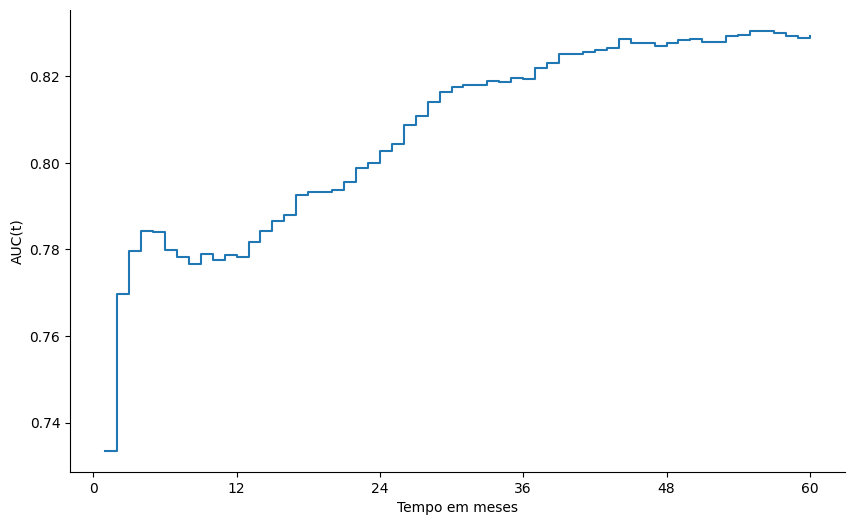

In [ ]:
# Define os tempos em que a AUC tempo-dependente será avaliada
# Neste caso, a avaliação será feita mês a mês, do mês 1 ao mês 60
time_points = np.arange(1, 61, 1)

# Gera as predições do modelo para o conjunto de teste
# Como o modelo está sendo avaliado com XGBoost, a predição é feita a partir do DMatrix 'dtest'
# Em geral, para o objetivo Cox, esses valores representam escores de risco
# Para o objetivo AFT, esses valores podem representar uma estimativa associada ao tempo de sobrevida
y_pred = best.predict(dtest)

# Calcula a AUC tempo-dependente usando:
# - time_points: tempos em que a métrica será calculada
# - y_pred: predições do modelo para os pacientes do conjunto de teste
# - y_train: dados de sobrevida do conjunto de treino, usados como referência para lidar com a censura
# - y_test: dados de sobrevida do conjunto de teste, usados para avaliar o desempenho do modelo
# - save=True: indica que o resultado ou gráfico gerado pela função será salvo
auc_time_dependent(time_points, y_pred, y_train, y_test, save=True)

In [ ]:
# Melhores features pelo permutation importance
pi_xgbcox = calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model
pi_xgbcox

,importances_mean,importances_std
EC,0.133406,0.002315
ANODIAG,0.023903,0.003200
TRATCONS_CAT,0.022714,0.001245
IDADE,0.021300,0.001306
CATEATEND,0.019005,0.001074
INSTITU,0.011388,0.000782
DIAGTRAT_CAT,0.006668,0.000734
IBGEATEN,0.005839,0.000385
ESCOLARI,0.005102,0.000463
DIAGPREV,0.004398,0.000472


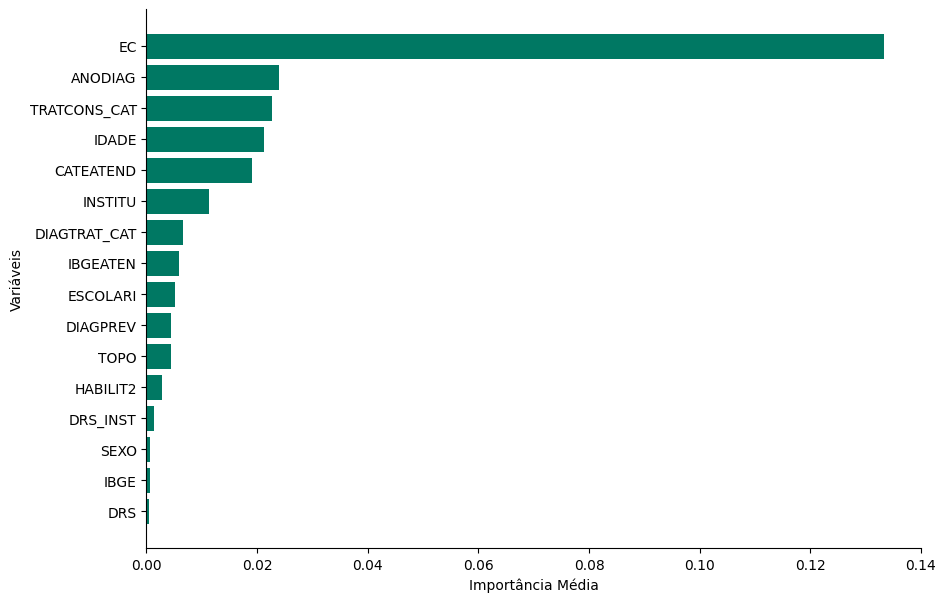

In [ ]:
# Cria uma nova coluna chamada 'features' a partir do índice do DataFrame
# Essa coluna armazenará os nomes das variáveis para facilitar a plotagem
pi_xgbcox['features'] = pi_xgbcox.index

# Cria a figura e o eixo do gráfico com tamanho personalizado
fig, ax = plt.subplots(figsize=(10, 7))

# Gera um gráfico de barras horizontais com:
# - eixo y: nomes das variáveis
# - eixo x: média das importâncias calculadas
ax.barh(pi_xgbcox['features'], pi_xgbcox['importances_mean'], color='#007863')

# Define o rótulo do eixo x
ax.set_xlabel('Importância Média')

# Define o rótulo do eixo y
ax.set_ylabel('Variáveis')

# Inverte a ordem do eixo y para que as variáveis mais importantes apareçam no topo
ax.invert_yaxis()

# Remove a borda superior do gráfico
ax.spines['top'].set_visible(False)

# Remove a borda direita do gráfico
ax.spines['right'].set_visible(False)

# Salva o gráfico em um arquivo de imagem
plt.savefig('xgbcox_pi.jpg')

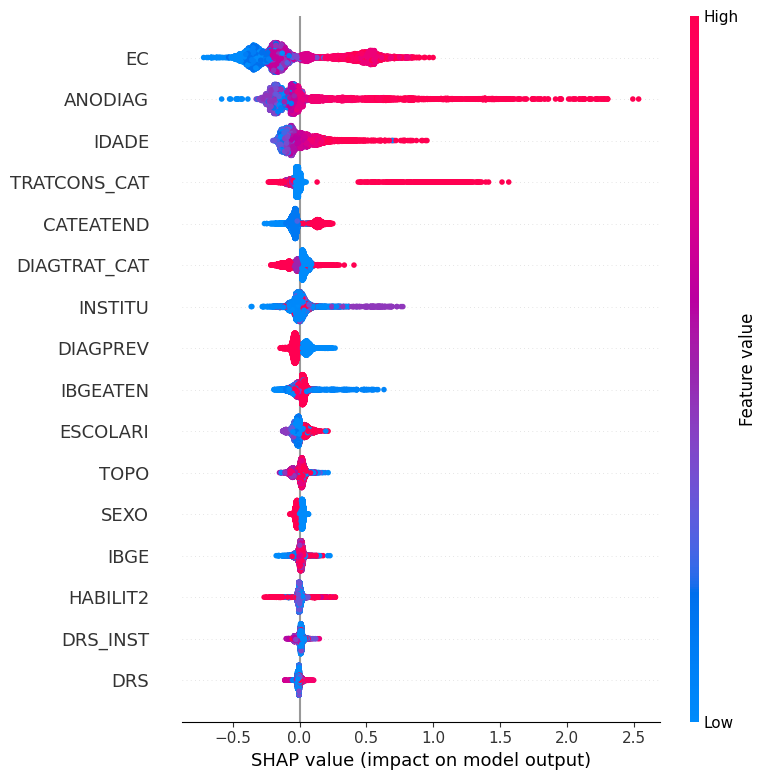

In [ ]:
# Melhores features pelo SHAP
explainer = shap.TreeExplainer(best)

# Calcula os valores SHAP para os pacientes do conjunto de teste
shap_values = explainer.shap_values(X_test)

# Gera o gráfico resumo do SHAP
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

## **XGBoost - AFT**

#### **Modelo baseline**

In [ ]:
# XGBoost-AFT

# Define pesos para as observações do conjunto de treino com base no status do evento
# Pacientes que tiveram o evento recebem peso 1.0. Pacientes censurados recebem peso 0.65
weights = np.where(y_train['event'], 1.0, 0.65)

# Limites superiores e inferiores do AFT
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino
# y_train['time'] é usado como variável alvo, representando o tempo até o evento ou censura
# weight=weights informa ao modelo os pesos definidos para eventos e censuras
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

# Cria a estrutura DMatrix do XGBoost para o conjunto de teste
dtest = xgb.DMatrix(X_test)

# Define os parâmetros do modelo XGBoost para análise de sobrevida
params = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'aft_loss_distribution_scale': 1.0,
    'max_depth': 3,
    'seed': seed,
}

# Treina o modelo XGBoost-AFT usando o conjunto de treino
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Gera as predições para o conjunto de treino
y_pred = xgb_aft.predict(dtest)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Calcula o C-Index no conjunto de treino
y_pred_train = xgb_aft.predict(dtrain)
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.7590129481627931
C-index Train: 0.7720743196466379


In [ ]:
# C-Index IPCW
surv_risks = xgb_aft.predict(dtest)  # Predição para o conjunto de teste
surv_risks_train = xgb_aft.predict(dtrain)  # Predição para o conjunto de treino

# Cálculo do C-Index IPCW
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)

# Print do C-Index IPCW para os conjuntos de teste e de treinamento
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')

C-Index IPCW Test: 0.7500621720921308
C-Index IPCW Train: 0.7614022630288654


#### **Optuna**

**Principais Parâmetros a Otimizar no XGBoost**

1. `n_estimators` (int):
* Número de árvores (boosting rounds) que o modelo vai treinar. Mais árvores podem melhorar o aprendizado, mas aumentam o risco de overfitting e o custo computacional.
* Sugestão de valores: 50 a 1000.

2. `learning_rate` (float):
* Taxa de aprendizado usada para diminuir a contribuição de cada árvore. Taxas menores exigem mais árvores, mas aumentam a estabilidade.
* Sugestão de valores: 0.01 a 0.3 (log-scale).

3. `max_depth` (int):
* Profundidade máxima das árvores individuais. Árvores mais profundas captam interações complexas, mas correm maior risco de overfitting.
* Sugestão de valores: 3 a 30.

4. `min_child_weight` (float):
* Peso mínimo da soma dos gradientes (hessian) em uma divisão de nó. Controla o tamanho mínimo de uma divisão, evitando overfitting.
* Sugestão de valores: 1 a 10.

5. `subsample` (float):
* Percentual de amostras utilizadas em cada árvore. Reduz overfitting ao amostrar dados de forma aleatória.
* Sugestão de valores: 0.5 a 1.0.

6. `colsample_bytree` (float):
* Percentual de colunas (features) usadas para cada árvore. Melhora a robustez e evita correlação entre as árvores.
* Sugestão de valores: 0.5 a 1.0.

7. `reg_alpha` (float):
* Regularização L1 (sparsidade). Incentiva a geração de árvores mais esparsas, evitando overfitting.
* Sugestão de valores: 1e-5 a 10 (log-scale).

8. `reg_lambda` (float):
* Regularização L2 (penalização quadrática). Controla a complexidade do modelo.
* Sugestão de valores: 1e-5 a 10 (log-scale).

9. `objective` (str):
* Função objetivo. Para sobrevivência, pode-se usar:

    'survival:cox': Regressão de Cox.
    
    'survival:aft': Modelo AFT (Accelerated Failure Time).

In [ ]:
# Número de tentativas
n_trials = 150

In [ ]:
# Folds para validação cruzada
kf = KFold(10, shuffle=True, random_state=seed)

def objective(trial):
    # Define os hiperparâmetros que serão otimizados
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Número de árvores
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Taxa de aprendizado
        'max_depth': trial.suggest_int('max_depth', 2, 4),  # Profundidade máxima das árvores
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Mínimo peso para os nós filhos
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fração de dados usados para treinamento
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fração de features para cada árvore
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # Regularização L1
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # Regularização L2
        'aft_loss_distribution': trial.suggest_categorical('aft_loss_distribution', ['normal', 'logistic', 'extreme']),  # Tipo de distribuição AFT
        'aft_loss_distribution_scale': trial.suggest_float('aft_loss_distribution_scale', 0.5, 2.0, step=0.05),  # Escala da distribuição AFT
        'objective': 'survival:aft',  # Função AFT
        'eval_metric': 'aft-nloglik',  # Métrica de validação para o modelo AFT
        'random_state': seed,  # Reprodutibilidade
        'n_jobs': -1,  # Uso de todos os processadores disponíveis
    }

    fold_c_indices = []  # Lista para guardar o C-Index de cada fold

    # Loop para iterar em cada fold da validação cruzada
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Divisão dos dados em treino e validação para o fold atual
            X_t, X_v = X_train[train_idx], X_train[valid_idx]
            y_t, y_v = y_train[train_idx], y_train[valid_idx]

            # Limites superiores e inferiores do AFT
            label_lower_bound = y_t['time']
            label_upper_bound = np.where(y_t['event'], y_t['time'], np.inf)

            # Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
            dtrain = xgb.DMatrix(X_t, label_lower_bound=label_lower_bound,
                                 label_upper_bound=label_upper_bound,
                                 weight=np.where(y_t['event'], 1.0, 0.65))

            dvalid = xgb.DMatrix(X_v)

            # Treina o modelo XGBoost-AFT usando os hiperparâmetros escolhidos
            model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)

            # Predições para o conjunto de validação
            pred_valid = model.predict(dvalid)

            # Cálculo do C-Index para o conjunto de validação
            c_index = concordance_index_censored(y_v['event'],
                                                 y_v['time'],
                                                 -pred_valid)[0]
            fold_c_indices.append(c_index)  # Adiciona o C-Index do fold na lista

        except (ValueError, xgb.core.XGBoostError) as e:
            continue  # Próximo fold

    # Retorna a média do C-Index de todos os folds
    return np.nanmean(fold_c_indices)

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
                            study_name='XGB_RandomSampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 64, 'learning_rate': 0.22, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.95, 'colsample_bytree': 0.8, 'reg_alpha': 10, 'reg_lambda': 0.01, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.6}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.65)  # Pesos para as amostras

# Limites superiores e inferiores do AFT
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Salva os hiperparâmetros do estudo
best_params.update({'objective': 'survival:aft',  # Função AFT
                    'eval_metric': 'aft-nloglik',  # Métrica de validação para o modelo AFT
                    'random_state': seed,  # Reprodutibilidade
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Treina o modelo XGBoost-Cox usando os melhores hiperparâmetros
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100)

# Predições para o conjunto de teste e treinamento
y_pred = xgb_rand.predict(dtest)
y_pred_train = xgb_rand.predict(dtrain)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {c_index_rand_train}')

C-Index Test: 0.7611643958266625
C-Index Train: 0.775242626895351


**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                            study_name='XGB_TPESampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 71, 'learning_rate': 0.24000000000000002, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.001, 'reg_lambda': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.75}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.65)  # Pesos para as amostras

# Limites superiores e inferiores do AFT
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Salva os hiperparâmetros do estudo
best_params.update({'objective': 'survival:aft',  # Função AFT
                    'eval_metric': 'aft-nloglik',  # Métrica de validação para o modelo AFT
                    'random_state': seed,  # Reprodutibilidade
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Treina o modelo XGBoost-Cox usando os melhores hiperparâmetros
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100)

# Predições para o conjunto de teste e treinamento
y_pred = xgb_tpe.predict(dtest)
y_pred_train = xgb_tpe.predict(dtrain)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {c_index_tpe_train}')

C-Index Test: 0.7617986988966732
C-Index Train: 0.7811839221420257


**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                            study_name='XGB_CmaEsSampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 135, 'learning_rate': 0.21000000000000002, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 0.95, 'colsample_bytree': 0.55, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.6}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.65)  # Pesos para as amostras

# Limites superiores e inferiores do AFT
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Salva os hiperparâmetros do estudo
best_params.update({'objective': 'survival:aft',  # Função AFT
                    'eval_metric': 'aft-nloglik',  # Métrica de validação para o modelo AFT
                    'random_state': seed,  # Reprodutibilidade
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Treina o modelo XGBoost-Cox usando os melhores hiperparâmetros
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100)

# Predições para o conjunto de teste e treinamento
y_pred = xgb_cma.predict(dtest)
y_pred_train = xgb_cma.predict(dtrain)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {c_index_cma_train}')

C-Index Test: 0.7611572584502112
C-Index Train: 0.7787471849959146


#### **Melhor XGBoost-AFT**

In [ ]:
# Melhor modelo XGB-AFT
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # Lista de C-Index para os modelos XGB-AFT
models = [xgb_aft, xgb_rand, xgb_tpe, xgb_cma]  # Lista de modelos

# Encontrando o melhor modelo a partir do maior C-Index
id_best_score = scores.index(max(scores))
best = models[id_best_score]

# Mostra o modelo selecionado
print(best)

In [ ]:
# Predições para os conjuntos de treino e teste
y_pred = best.predict(dtest)
y_pred_train = best.predict(dtrain)

# Cálculo do C-Index
final_c_index = concordance_index_censored(y_test['event'], y_test['time'],
                                           -y_pred)[0]
final_c_index_train = concordance_index_censored(y_train['event'],
                                                 y_train['time'],
                                                 -y_pred_train)[0]

# Print do C-index para os conjuntos de teste e de treinamento
print('C-Index')
print(f'> Test: {final_c_index}')
print(f'> Train: {final_c_index_train}')

# Cálculo do C-Index IPCW
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')
print(f'> Train: {c_index_ipcw_train[0]}')

C-Index
> Test: 0.7617986988966732
> Train: 0.7811839221420257

C-Index IPCW
> Test: 0.7531615637628547
> Train: 0.7712038798077203


In [ ]:
# Melhores features pelo permutation importance
pi_xgbaft = calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)
pi_xgbaft

,importances_mean,importances_std
DRS,-0.000513,0.000177
IBGE,-0.000710,0.000376
SEXO,-0.001342,0.000410
DRS_INST,-0.002288,0.000353
ESCOLARI,-0.003358,0.000401
HABILIT2,-0.003481,0.000305
DIAGPREV,-0.003951,0.000771
IBGEATEN,-0.004205,0.000486
TOPO,-0.004481,0.000332
DIAGTRAT_CAT,-0.005029,0.000550


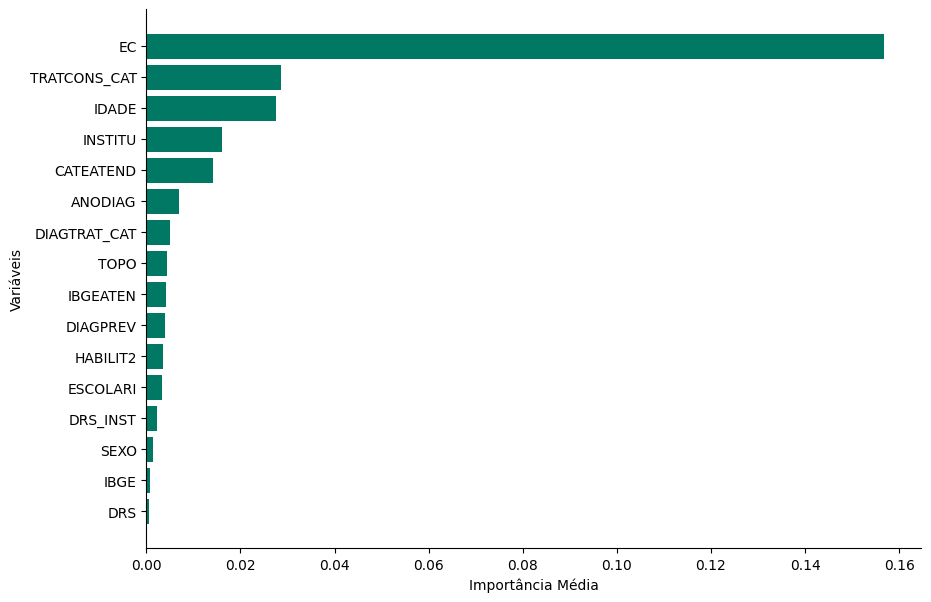

In [ ]:
# Cria uma nova coluna chamada 'features' a partir do índice do DataFrame
# Essa coluna armazenará os nomes das variáveis para facilitar a plotagem
pi_xgbaft['features'] = pi_xgbaft.index

# Cria a figura e o eixo do gráfico com tamanho personalizado
fig, ax = plt.subplots(figsize=(10, 7))

# Gera um gráfico de barras horizontais com:
# - eixo y: nomes das variáveis
# - eixo x: média das importâncias calculadas
ax.barh(pi_xgbaft['features'], pi_xgbaft['importances_mean'], color='#007863')

# Define o rótulo do eixo x
ax.set_xlabel('Importância Média')

# Define o rótulo do eixo y
ax.set_ylabel('Variáveis')

# Inverte a ordem do eixo y para que as variáveis mais importantes apareçam no topo
ax.invert_yaxis()

# Remove a borda superior do gráfico
ax.spines['top'].set_visible(False)

# Remove a borda direita do gráfico
ax.spines['right'].set_visible(False)

# Salva o gráfico em um arquivo de imagem
plt.savefig('xgbaft_pi.jpg')

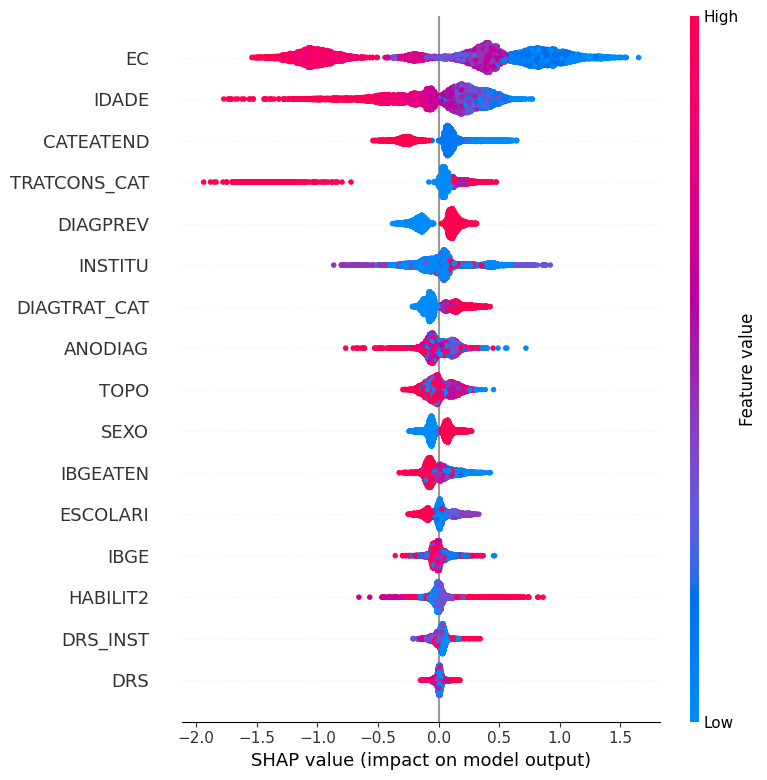

In [ ]:
# Melhores features pelo SHAP
explainer = shap.TreeExplainer(best)

# Calcula os valores SHAP para os pacientes do conjunto de teste
shap_values = explainer.shap_values(X_test)

# Gera o gráfico resumo do SHAP
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

## **LightGBM**

#### **Modelo baseline**

In [ ]:
# LightGBM

# Cria a estrutura DMatrix do LightGBM para o conjunto de treino
# y_train['time'] é usado como variável alvo, representando o tempo até o evento ou censura
# weight=weights informa ao modelo os pesos definidos para eventos e censuras
# Pacientes que tiveram o evento recebem peso 1.0. Pacientes censurados recebem peso 0.15
dtrain = lgb.Dataset(X_train, label=y_train['time'],
                     weight=np.where(y_train['event'], 1.0, 0.15))

# Define os parâmetros do modelo LightGBM para análise de sobrevida
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'max_depth': 5,
    'seed': seed,
    'verbose': -1,
    'n_jobs': -1
}

# Treina o modelo LightGBM usando o conjunto de treino
lgbm = lgb.train(params, dtrain, num_boost_round=100)

# Predições para o conjunto de teste
y_pred = lgbm.predict(X_test)

# Cálculo do C-Index para o conjunto de teste
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Gera as predições para o conjunto de treino
y_pred_train = lgbm.predict(X_train)

# Calcula o C-Index no conjunto de treino
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.72564403952883
C-index Train: 0.7438403445809474


In [ ]:
# C-Index IPCW
surv_risks = lgbm.predict(X_test)  # Predição para o conjunto de teste
surv_risks_train = lgbm.predict(X_train)  # Predição para o conjunto de treino

# Cálculo do C-Index IPCW
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)

# Print do C-Index IPCW para os conjuntos de teste e de treinamento
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')

C-Index IPCW Test: 0.719402090675295
C-Index IPCW Train: 0.7343812151099653


#### **Optuna**

**Principais Parâmetros a Otimizar no LightGBM**

1. `n_estimators` (int):
* Número de árvores (boosting rounds). Mais árvores podem aumentar a precisão, mas também o risco de overfitting.
* Sugestão de valores: 50 a 1000.

2. `learning_rate` (float):
* Taxa de aprendizado que controla o impacto de cada árvore. Menores taxas aumentam a estabilidade, mas exigem mais árvores.
* Sugestão de valores: 0.01 a 0.3.

3. `max_depth` (int):
* Profundidade máxima das árvores. Profundidades maiores captam padrões complexos, mas correm maior risco de overfitting.
* Sugestão de valores: 3 a 30.

4. `num_leaves` (int):
* Número máximo de folhas por árvore. Define a complexidade das árvores. Muitas folhas podem gerar overfitting.
* Sugestão de valores: 20 a 150.

5. `min_child_samples` (int):
* Número mínimo de dados para uma folha ser dividida. Impede que folhas pequenas sejam criadas, evitando overfitting.
* Sugestão de valores: 5 a 50.

6. `subsample` (float):
* Percentual de amostras usado em cada árvore. Ajuda a reduzir overfitting ao aplicar amostragem aleatória.
* Sugestão de valores: 0.5 a 1.0.

7. `colsample_bytree` (float):
* Percentual de colunas usadas para cada árvore. Ajuda na generalização ao evitar que árvores se tornem muito correlacionadas.
* Sugestão de valores: 0.5 a 1.0.

8. `objective` (str):
* Função objetivo usada:
    
    'survival:cox': Regressão de Cox.
    
    'survival:aft': Modelo AFT para dados de sobrevivência.

9. `aft_loss_distribution` (str):
* Distribuição do modelo AFT, caso usado: 'normal', 'log-normal', 'log-logistic'.
* Sugestão: Testar diferentes distribuições para o modelo AFT.

In [ ]:
# Número de tentativas
n_trials = 150

In [ ]:
# Folds para validação cruzada
kf = KFold(10, shuffle=True, random_state=seed)

# Função objetivo para otimização de hiperparâmetros
def objective(trial):
    # Define os hiperparâmetros que serão otimizados
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 130),  # Número de árvores
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Taxa de aprendizado
        'max_depth': trial.suggest_int('max_depth', 3, 5),  # Profundidade máxima das árvores
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),  # Número de folhas em cada árvore
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 20),  # Amostras mínimas para cada nó filho
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fração de dados usados para treinamento
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fração de features para cada árvore
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10.0]),  # Regularização L1
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10.0]),  # Regularização L2
        'objective': 'regression',  # Função de regressão
        'metric': 'rmse',  # Métrica de validação RMSE
        'seed': seed,  # Reprodutibilidade
        'verbose': -1,  # Não mostrar as saídas durante o treino
        'n_jobs': -1  # Uso de todos os processadores disponíveis
    }

    c_index_list = []  # Lista para guardar o C-Index de cada fold

    # Loop para iterar em cada fold da validação cruzada
    for train_idx, valid_idx in kf.split(X_train):
        # Divisão dos dados em treino e validação para o fold atual
        X_t, X_v = X_train[train_idx], X_train[valid_idx]
        y_t, y_v = y_train[train_idx], y_train[valid_idx]

        # Cria a estrutura DMatrix do LGBM para o conjunto de treino e de validação
        dtrain = lgb.Dataset(X_t, label=y_t['time'], weight=np.where(y_t['event'], 1.0, 0.15))

        # Treina o modelo LGBM usando os hiperparâmetros escolhidos
        model = lgb.train(param, dtrain, num_boost_round=100)

        # Predições para o conjunto de validação
        pred_valid = model.predict(X_v)

        # Cálculo do C-Index para o conjunto de validação
        c_index = concordance_index_censored(y_v['event'], y_v['time'], -pred_valid)[0]
        c_index_list.append(c_index)  # Adiciona o C-Index do fold na lista

    # Retorna a média do C-Index de todos os folds
    return np.mean(c_index_list)

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
                            study_name='LGBM_RandomSampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 110, 'learning_rate': 0.11, 'max_depth': 5, 'num_leaves': 23, 'min_child_samples': 14, 'subsample': 0.6, 'colsample_bytree': 0.5, 'reg_alpha': 10.0, 'reg_lambda': 0.01}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.15)  # Pesos para as amostras

best_params = study.best_params  # Salva os hiperparâmetros do estudo

best_params.update({'objective': 'regression',  # Função de regressão
                    'metric': 'rmse',  # Métrica de validação RMSE
                    'seed': seed,  # Reprodutibilidade
                    'verbose': -1,  # Não mostrar as saídas durante o treino
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)

# Treina o modelo LGBM usando os melhores hiperparâmetros
lgbm_rand = lgb.train(best_params, dtrain, num_boost_round=100)

# Predições para o conjunto de teste e treinamento
y_pred = lgbm_rand.predict(X_test)
y_pred_train = lgbm_rand.predict(X_train)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {c_index_rand_train}')

C-Index Test: 0.7274680720718807
C-Index Train: 0.7440293719234166


**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                            study_name='LGBM_TPESampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 113, 'learning_rate': 0.12, 'max_depth': 5, 'num_leaves': 63, 'min_child_samples': 20, 'subsample': 0.5, 'colsample_bytree': 0.5, 'reg_alpha': 10.0, 'reg_lambda': 0.1}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.15)  # Pesos para as amostras

best_params = study.best_params  # Salva os hiperparâmetros do estudo

best_params.update({'objective': 'regression',  # Função de regressão
                    'metric': 'rmse',  # Métrica de validação RMSE
                    'seed': seed,  # Reprodutibilidade
                    'verbose': -1,  # Não mostrar as saídas durante o treino
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)

# Treina o modelo LGBM usando os melhores hiperparâmetros
lgbm_tpe = lgb.train(best_params, dtrain, num_boost_round=100)

# Predições para o conjunto de teste e treinamento
y_pred = lgbm_tpe.predict(X_test)
y_pred_train = lgbm_tpe.predict(X_train)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {c_index_tpe_train}')

C-Index Test: 0.7267929455171543
C-Index Train: 0.7468179965988841


**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                            study_name='LGBM_CmaEsSampler')

# Inicia o estudo com 'n_trials'
study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 120, 'learning_rate': 0.14, 'max_depth': 5, 'num_leaves': 71, 'min_child_samples': 6, 'subsample': 0.7, 'colsample_bytree': 0.5, 'reg_alpha': 0.01, 'reg_lambda': 10.0}


In [ ]:
# Treino e validação com os melhores hiperparâmetros
weights = np.where(y_train['event'], 1.0, 0.15)  # Pesos para as amostras

best_params = study.best_params  # Salva os hiperparâmetros do estudo

best_params.update({'objective': 'regression',  # Função de regressão
                    'metric': 'rmse',  # Métrica de validação RMSE
                    'seed': seed,  # Reprodutibilidade
                    'verbose': -1,  # Não mostrar as saídas durante o treino
                    'n_jobs': -1})  # Uso de todos os processadores disponíveis

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)

# Treina o modelo LGBM usando os melhores hiperparâmetros
lgbm_cma = lgb.train(best_params, dtrain, num_boost_round=100)

# Predições para o conjunto de teste e treinamento
y_pred = lgbm_cma.predict(X_test)
y_pred_train = lgbm_cma.predict(X_train)

# Cálculo do C-Index para o conjunto de validação e de treino
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {c_index_cma_train}')

C-Index Test: 0.7264684353662659
C-Index Train: 0.747302580004379


#### **Melhor LightGBM**

In [ ]:
# Melhor modelo LGBM
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # Lista de C-Index para os modelos LGBM
models = [lgbm, lgbm_rand, lgbm_tpe, lgbm_cma]  # Lista de modelos

# Encontrando o melhor modelo a partir do maior C-Index
id_best_score = scores.index(max(scores))
best = models[id_best_score]

# Mostra o modelo selecionado
print(best)

In [ ]:
# Predições para os conjuntos de treino e teste
y_pred = best.predict(X_test)
y_pred_train = best.predict(X_train)

# Cálculo do C-Index
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # Compute the concordance index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # Compute the concordance index for the training set

# Print do C-index para os conjuntos de teste e de treinamento
print('C-Index')
print(f'> Test: {final_c_index}')
print(f'> Train: {final_c_index_train}')

# Cálculo do C-Index IPCW
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')
print(f'> Train: {c_index_ipcw_train[0]}')

C-Index
> Test: 0.7274680720718807
> Train: 0.7440293719234166

C-Index IPCW
> Test: 0.7210504695773766
> Train: 0.7344669243598438


In [ ]:
# Melhores features pelo permutation importance
pi_lgbm = calculate_permutation_importance_lgbm(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model
pi_lgbm

,importances_mean,importances_std
EC,0.135940,0.002255
IDADE,0.023355,0.001384
ANODIAG,0.023030,0.003118
CATEATEND,0.016951,0.001269
DIAGTRAT_CAT,0.015770,0.001205
INSTITU,0.011469,0.000731
TRATCONS_CAT,0.006934,0.000583
ESCOLARI,0.003849,0.000477
DIAGPREV,0.003570,0.000608
IBGEATEN,0.003451,0.000445


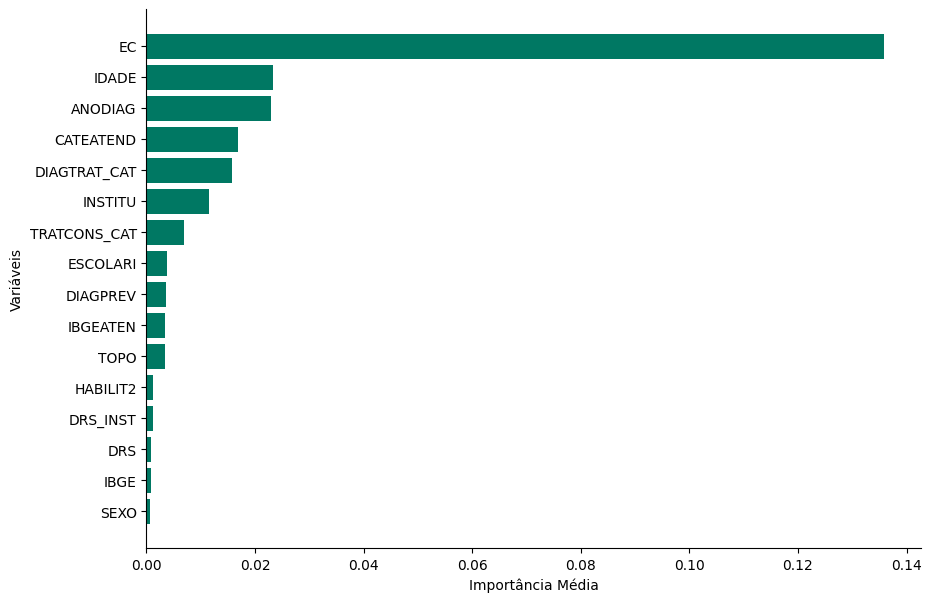

In [ ]:
# Cria uma nova coluna chamada 'features' a partir do índice do DataFrame
# Essa coluna armazenará os nomes das variáveis para facilitar a plotagem
pi_lgbm['features'] = pi_lgbm.index

# Cria a figura e o eixo do gráfico com tamanho personalizado
fig, ax = plt.subplots(figsize=(10, 7))

# Gera um gráfico de barras horizontais com:
# - eixo y: nomes das variáveis
# - eixo x: média das importâncias calculadas
ax.barh(pi_lgbm['features'], pi_lgbm['importances_mean'], color='#007863')

# Define o rótulo do eixo x
ax.set_xlabel('Importância Média')

# Define o rótulo do eixo y
ax.set_ylabel('Variáveis')

# Inverte a ordem do eixo y para que as variáveis mais importantes apareçam no topo
ax.invert_yaxis()

# Remove a borda superior do gráfico
ax.spines['top'].set_visible(False)

# Remove a borda direita do gráfico
ax.spines['right'].set_visible(False)

# Salva o gráfico em um arquivo de imagem
plt.savefig('lgbm_pi.jpg')

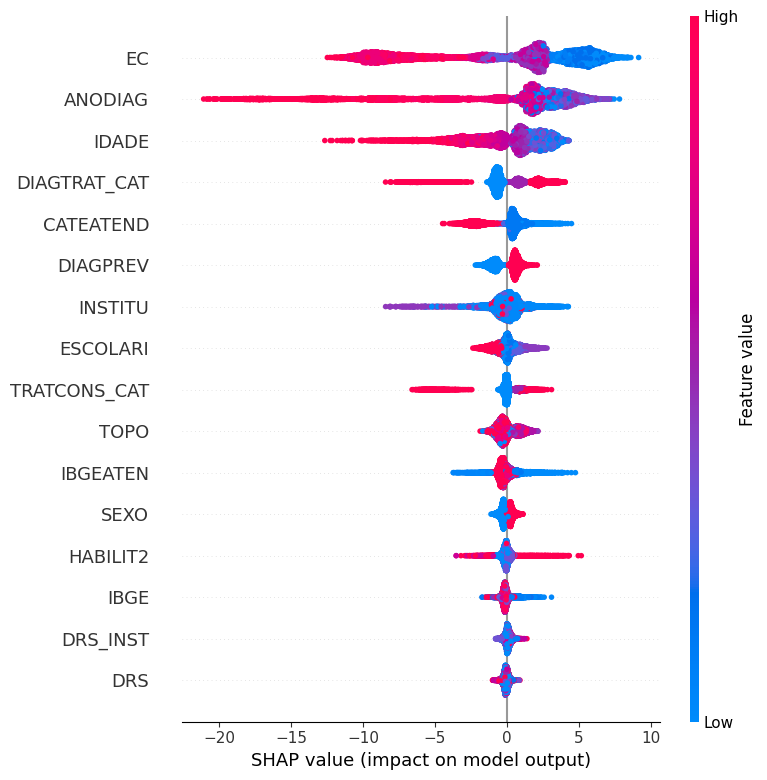

In [ ]:
# Melhores features pelo SHAP
explainer = shap.TreeExplainer(best)

# Calcula os valores SHAP para os pacientes do conjunto de teste
shap_values = explainer.shap_values(X_test)

# Gera o gráfico resumo do SHAP
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

# **Testes estatísticos**

## **Friedman e Wilcoxon**

In [ ]:
# Folds para validação cruzada
kf = KFold(n_splits=10, shuffle=True, random_state=seed)

# Função para calcular o C-Index
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)
    return cindex

# Função objetivo para otimização de hiperparâmetros
def cross_val_scores(model, x_train, y_train, cv):

    # Realiza a validação cruzada e retorna o valor médio do C-Index
    return cross_val_score(model, X_train, y_train, cv=kf, scoring=c_index)


rsf = RandomSurvivalForest(n_estimators=116, max_depth=10, min_samples_split=9,
                           min_samples_leaf=9, max_features='log2',
                           bootstrap=False, random_state=seed, n_jobs=-1)

rsf_scores = cross_val_scores(rsf, X_train, y_train, kf)
rsf_scores

array([0.75294826, 0.75457011, 0.75577574, 0.75117184, 0.76159511,
       0.75841056, 0.75456214, 0.75953422, 0.75534798, 0.75606636])

In [ ]:
# Média e desvio padrão
rsf_scores.mean(), rsf_scores.std()

(np.float64(0.7559982316623954), np.float64(0.0029465726595567275))

In [ ]:
# Folds para validação cruzada
kf = KFold(n_splits=10, shuffle=True, random_state=seed)

# Função para calcular o C-Index
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)
    return cindex

# Função objetivo para otimização de hiperparâmetros
def cross_val_scores(model, x_train, y_train, cv):

    # Realiza a validação cruzada e retorna o valor médio do C-Index
    return cross_val_score(model, X_train, y_train, cv=kf, scoring=c_index)


gbsa = GradientBoostingSurvivalAnalysis(learning_rate=0.2, max_depth=5,
                                        max_features=0.5, min_samples_leaf=6,
                                        min_samples_split=5, n_estimators=111,
                                        random_state=seed, subsample=0.9)

gbsa_scores = cross_val_scores(gbsa, X_train, y_train, kf)
gbsa_scores

array([0.75755387, 0.75976013, 0.76226907, 0.75884142, 0.76327071,
       0.76437132, 0.76079853, 0.76514873, 0.76126174, 0.76083585])

In [ ]:
# Média e desvio padrão
gbsa_scores.mean(), gbsa_scores.std()

(np.float64(0.7614111367730992), np.float64(0.0022773388100890057))

In [ ]:
# Folds para validação cruzada
kf = KFold(n_splits=10, shuffle=True, random_state=seed)

# Função para calcular o C-Index
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)
    return cindex

# Função objetivo para otimização de hiperparâmetros
def cross_val_scores(model, x_train, y_train, cv):

    # Realiza a validação cruzada e retorna o valor médio do C-Index
    return cross_val_score(model, X_train, y_train, cv=kf, scoring=c_index)


ssvm = FastSurvivalSVM(optimizer='avltree', random_state=seed)

ssvm_scores = cross_val_scores(ssvm, X_train, y_train, kf)
ssvm_scores

array([0.71286448, 0.71102322, 0.71155921, 0.70994088, 0.71169703,
       0.71920449, 0.71220345, 0.7163517 , 0.71155303, 0.72073103])

In [ ]:
# Média e desvio padrão
ssvm_scores.mean(), ssvm_scores.std()

(np.float64(0.7137128523870522), np.float64(0.003524243668613211))

In [ ]:
# Folds para validação cruzada
kf = KFold(10, shuffle=True, random_state=seed)

# Função objetivo para otimização de hiperparâmetros
def cross_val_scores(x_train, y_train, params):

    c_index_list = []  # Lista para guardar o C-Index de cada fold

    # Loop para iterar em cada fold da validação cruzada
    for train_idx, valid_idx in kf.split(x_train):
        # Divisão dos dados em treino e validação para o fold atual
        X_t, X_v = x_train[train_idx], x_train[valid_idx]
        y_t, y_v = y_train[train_idx], y_train[valid_idx]

        # Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
        dtrain = xgb.DMatrix(X_t, label=y_t['time'],
                             weight=np.where(y_t['event'], 1.0, 0.25))  # Ajusta os pesos
        dvalid = xgb.DMatrix(X_v)

        # Treina o modelo XGBoost-Cox usando os hiperparâmetros escolhidos
        model = xgb.train(params, dtrain, num_boost_round=100, verbose_eval=False)

        # Predições para o conjunto de validação
        pred_valid = model.predict(dvalid)

        # Cálculo do C-Index para o conjunto de validação
        c_index = concordance_index_censored(y_v['event'], y_v['time'], pred_valid)[0]
        c_index_list.append(c_index)  # Adiciona o C-Index do fold na lista

    # Retorna a média do C-Index de todos os folds
    return c_index_list

params = {'n_estimators': 73, 'learning_rate': 0.15, 'max_depth': 4,
          'min_child_weight': 4, 'subsample': 0.85, 'colsample_bytree': 0.6,
          'reg_alpha': 1, 'reg_lambda': 0.01, 'objective': 'survival:cox',
          'eval_metric': 'cox-nloglik', 'random_state': seed, 'n_jobs': -1}

xgb_cox_scores = cross_val_scores(X_train, y_train, params)
xgb_cox_scores

[np.float64(0.7176573066929399),
 np.float64(0.7175620076520587),
 np.float64(0.7251086239589579),
 np.float64(0.7200483484342466),
 np.float64(0.7346092066601371),
 np.float64(0.7241497319591271),
 np.float64(0.7266149338006042),
 np.float64(0.7290151557449766),
 np.float64(0.726637145442063),
 np.float64(0.7231004074775332)]

In [ ]:
# Média e desvio padrão
np.mean(xgb_cox_scores), np.std(xgb_cox_scores)

(np.float64(0.7244502867822644), np.float64(0.0049882429121918094))

In [ ]:
# Folds para validação cruzada
kf = KFold(10, shuffle=True, random_state=seed)

# Função objetivo para otimização de hiperparâmetros
def cross_val_scores(x_train, y_train, params):

    c_index_list = []  # Lista para guardar o C-Index de cada fold

    # Loop para iterar em cada fold da validação cruzada
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Divisão dos dados em treino e validação para o fold atual
            X_t, X_v = X_train[train_idx], X_train[valid_idx]
            y_t, y_v = y_train[train_idx], y_train[valid_idx]

            # Limites superiores e inferiores do AFT
            label_lower_bound = y_t['time']
            label_upper_bound = np.where(y_t['event'], y_t['time'], np.inf)

            # Cria a estrutura DMatrix do XGBoost para o conjunto de treino e de validação
            dtrain = xgb.DMatrix(X_t, label_lower_bound=label_lower_bound,
                                 label_upper_bound=label_upper_bound,
                                 weight=np.where(y_t['event'], 1.0, 0.65))

            dvalid = xgb.DMatrix(X_v)

            # Treina o modelo XGBoost-AFT usando os hiperparâmetros escolhidos
            model = xgb.train(params, dtrain, num_boost_round=100, verbose_eval=False)

            # Predições para o conjunto de validação
            pred_valid = model.predict(dvalid)

            # Cálculo do C-Index para o conjunto de validação
            c_index = concordance_index_censored(y_v['event'],
                                                 y_v['time'],
                                                 -pred_valid)[0]
            c_index_list.append(c_index)  # Adiciona o C-Index do fold na lista

        except (ValueError, xgb.core.XGBoostError) as e:
            continue  # Próximo fold

    # Retorna a média do C-Index de todos os folds
    return c_index_list

params = {'n_estimators': 71, 'learning_rate': 0.24, 'max_depth': 4,
          'min_child_weight': 7, 'subsample': 1.0, 'colsample_bytree': 1.0,
          'reg_alpha': 0.001, 'reg_lambda': 1, 'aft_loss_distribution': 'normal',
          'aft_loss_distribution_scale': 1.75, 'objective': 'survival:aft',
          'eval_metric': 'aft-nloglik', 'random_state': seed, 'n_jobs': -1}

xgb_aft_scores = cross_val_scores(X_train, y_train, params)
xgb_aft_scores

[np.float64(0.7642540151821126),
 np.float64(0.7617522424756817),
 np.float64(0.7652627189424492),
 np.float64(0.7631678760233958),
 np.float64(0.7703146647671624),
 np.float64(0.7647911901250268),
 np.float64(0.7662932602705739),
 np.float64(0.7681039499233838),
 np.float64(0.7691308932928295),
 np.float64(0.7607916009303385)]

In [ ]:
# Média e desvio padrão
np.mean(xgb_aft_scores), np.std(xgb_aft_scores)

(np.float64(0.7653862411932953), np.float64(0.002956509626763721))

In [ ]:
# Folds para validação cruzada
kf = KFold(10, shuffle=True, random_state=seed)

# Função objetivo para otimização de hiperparâmetros
def cross_val_scores(x_train, y_train, params):

    c_index_list = []  # Lista para guardar o C-Index de cada fold

    # Loop para iterar em cada fold da validação cruzada
    for train_idx, valid_idx in kf.split(X_train):
        # Divisão dos dados em treino e validação para o fold atual
        X_t, X_v = X_train[train_idx], X_train[valid_idx]
        y_t, y_v = y_train[train_idx], y_train[valid_idx]

        # Cria a estrutura DMatrix do LGBM para o conjunto de treino e de validação
        dtrain = lgb.Dataset(X_t, label=y_t['time'], weight=np.where(y_t['event'], 1.0, 0.15))

        # Treina o modelo LGBM usando os hiperparâmetros escolhidos
        model = lgb.train(params, dtrain, num_boost_round=100)

        # Predições para o conjunto de validação
        pred_valid = model.predict(X_v)

        # Cálculo do C-Index para o conjunto de validação
        c_index = concordance_index_censored(y_v['event'], y_v['time'], -pred_valid)[0]
        c_index_list.append(c_index)  # Adiciona o C-Index do fold na lista

    # Retorna a média do C-Index de todos os folds
    return c_index_list

params = {'n_estimators': 110, 'learning_rate': 0.11, 'max_depth': 5,
          'num_leaves': 23, 'min_child_samples': 14, 'subsample': 0.6,
          'colsample_bytree': 0.5, 'reg_alpha': 10.0, 'reg_lambda': 0.01,
          'objective': 'regression', 'metric': 'rmse', 'seed': seed,
          'verbose': -1, 'n_jobs': -1}

lgbm_scores = cross_val_scores(X_train, y_train, params)
lgbm_scores

[np.float64(0.7218663369361698),
 np.float64(0.7235681886733926),
 np.float64(0.7299552835667767),
 np.float64(0.7259764932925691),
 np.float64(0.7404664470364765),
 np.float64(0.7292166514075212),
 np.float64(0.7331739365986081),
 np.float64(0.7294670364097696),
 np.float64(0.7295266670913272),
 np.float64(0.7278700185895479)]

In [ ]:
# Média e desvio padrão
np.mean(lgbm_scores), np.std(lgbm_scores)

(np.float64(0.7291087059602159), np.float64(0.004909685978390993))

In [ ]:
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# Exemplo: cada coluna é um modelo e cada linha é um fold
df_metricas = pd.DataFrame({
    "RSF": rsf_scores,
    "GBSA": gbsa_scores,
    "SSVM": ssvm_scores,
    "XGB_Cox": xgb_cox_scores,
    "XGB_AFT": xgb_aft_scores,
    "LGBM": lgbm_scores
})

# Teste de Friedman
stat, p = friedmanchisquare(
    df_metricas["RSF"],
    df_metricas["GBSA"],
    df_metricas["SSVM"],
    df_metricas["XGB_Cox"],
    df_metricas["XGB_AFT"],
    df_metricas["LGBM"]
)

print(f"Friedman statistic = {stat:.5f}")
print(f"p-value = {p:.5f}")

Friedman statistic = 49.48571
p-value = 0.00000


In [ ]:
p

np.float64(1.7656527390849315e-09)

In [ ]:
# Aplica o teste de Wilcoxon para amostras pareadas, comparando os resultados
# das métricas obtidas pelos modelos GBSA e XGB-AFT
stat, p = wilcoxon(df_metricas['GBSA'],
                   df_metricas['XGB_AFT']
)

# Exibe a estatística do teste e o respectivo p-valor
stat, p

(np.float64(1.0), np.float64(0.00390625))

In [ ]:
# Obtém os nomes dos modelos presentes no DataFrame de métricas
modelos = df_metricas.columns

# Cria uma lista vazia para armazenar os resultados das comparações
# par a par entre os modelos
resultados = []

# Percorre todas as combinações possíveis de dois modelos
# para realizar as comparações pareadas
for m1, m2 in combinations(modelos, 2):

    # Aplica o teste de Wilcoxon para comparar os resultados dos dois modelos
    stat, p = wilcoxon(df_metricas[m1], df_metricas[m2])

    # Armazena os nomes dos modelos e o p-valor do teste
    resultados.append({
        "Modelo 1": m1,
        "Modelo 2": m2,
        "p-valor": p
    })

# Converte os resultados das comparações em um DataFrame
df_pares = pd.DataFrame(resultados)

# Aplica a correção de Holm para múltiplas comparações,
# controlando a taxa de erro do tipo I no conjunto de testes realizados
reject, p_corrigido, _, _ = multipletests(
    df_pares["p-valor"],
    method="holm"
)

# Adiciona ao DataFrame os p-valores corrigidos pela metodologia de Holm
df_pares["p-valor corrigido"] = p_corrigido

# Indica quais comparações apresentaram diferença estatisticamente significativa
# após a aplicação da correção para múltiplas comparações
df_pares["Diferença significativa"] = reject

# Exibe a tabela com os resultados dos testes pareados e a correção de Holm
df_pares

,Modelo 1,Modelo 2,p-valor,p-valor corrigido,Diferença significativa
0,RSF,GBSA,0.001953,0.029297,True
1,RSF,SSVM,0.001953,0.029297,True
2,RSF,XGB_Cox,0.001953,0.029297,True
3,RSF,XGB_AFT,0.001953,0.029297,True
4,RSF,LGBM,0.001953,0.029297,True
5,GBSA,SSVM,0.001953,0.029297,True
6,GBSA,XGB_Cox,0.001953,0.029297,True
7,GBSA,XGB_AFT,0.003906,0.029297,True
8,GBSA,LGBM,0.001953,0.029297,True
9,SSVM,XGB_Cox,0.001953,0.029297,True


## **Intervalos de confiança**

In [ ]:
!gdown 1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a

with open('colorretal.pkl', 'rb') as f:
    colo = pickle.load(f)

colo

Downloading...
From (original): https://drive.google.com/uc?id=1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a
From (redirected): https://drive.google.com/uc?id=1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a&confirm=t&uuid=dacac4eb-fc1e-4fdd-b423-5947eaf6e3bb
To: /content/colorretal.pkl
100% 114M/114M [00:01<00:00, 61.3MB/s]


{'rsf': RandomSurvivalForest(bootstrap=False, max_depth=10, max_features='log2',
                      min_samples_leaf=9, min_samples_split=9, n_estimators=116,
                      random_state=1),
 'gb': GradientBoostingSurvivalAnalysis(learning_rate=0.2, max_depth=5,
                                  max_features=0.5, min_samples_leaf=6,
                                  min_samples_split=5, n_estimators=111,
                                  random_state=1, subsample=0.9),
 'ssvm': FastSurvivalSVM(optimizer='avltree', random_state=1),
 'xgb_cox': <xgboost.core.Booster at 0x7db106423800>,
 'xgb_aft': <xgboost.core.Booster at 0x7db10861d490>}

**RSF**

In [ ]:
# Importa a função utilizada para realizar a reamostragem com reposição
# durante o procedimento de bootstrap
from sklearn.utils import resample

# Calcula os escores de risco previstos pelo modelo RSF para o conjunto de teste
risk_scores = colo['rsf'].predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index
# calculados em cada amostra bootstrap
c_indexes = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index para a amostra bootstrap.
    # O primeiro argumento corresponde à ocorrência do evento,
    # o segundo ao tempo de sobrevida e o terceiro aos escores de risco previstos.
    cindex = concordance_index_censored(
        y_boot["event"],
        y_boot["time"],
        risk_boot
    )[0]

    # Armazena o C-index calculado na iteração atual
    c_indexes.append(cindex)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(c_indexes, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(c_indexes, 97.5)

# Calcula a média dos valores de C-index obtidos nas 1.000 amostras bootstrap
mean = np.mean(c_indexes)

# Exibe o C-index médio e o intervalo de confiança de 95%
print(f"C-index: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index: 0.7550 (0.7482-0.7619)


In [ ]:
# Calcula os escores de risco previstos pelo modelo RSF para o conjunto de teste
risk_scores = colo['rsf'].predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index IPCW
# calculados em cada amostra bootstrap
ipcw_cindices = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index IPCW (Inverse Probability of Censoring Weighting)
    # utilizando o conjunto de treinamento para estimar a distribuição
    # de censura e a amostra bootstrap do conjunto de teste para avaliação.
    cindex = concordance_index_ipcw(
        y_train,
        y_boot,
        risk_boot
    )[0]

    # Armazena o C-index IPCW calculado na iteração atual
    ipcw_cindices.append(cindex)

# Calcula a média dos valores de C-index IPCW obtidos nas amostras bootstrap
mean = np.mean(ipcw_cindices)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ipcw_cindices, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ipcw_cindices, 97.5)

# Exibe o C-index IPCW médio e seu intervalo de confiança de 95%
print(f"C-index IPCW: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index IPCW: 0.7488 (0.7417-0.7556)


In [ ]:
# Calcula as funções de sobrevida previstas pelo modelo RSF para cada
# indivíduo do conjunto de teste e retorna os resultados em formato de array
survival_predictions = colo['rsf'].predict_survival_function(
    X_test,
    return_array=True
)

# Obtém os tempos únicos utilizados pelo modelo para estimar as funções
# de sobrevida, excluindo o último tempo para adequação às dimensões
# das previsões utilizadas no cálculo do IBS
times = colo['rsf'].unique_times_[:-1]

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do Integrated Brier Score (IBS)
# calculados em cada amostra bootstrap
ibs_values = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona as funções de sobrevida previstas correspondentes
    # às mesmas observações da amostra bootstrap
    surv_boot = survival_predictions[idx]

    # Calcula o Integrated Brier Score (IBS), que avalia a acurácia
    # das previsões de sobrevida ao longo do período de acompanhamento.
    # O conjunto de treinamento é utilizado como referência para o cálculo
    # dos pesos relacionados à censura.
    ibs = integrated_brier_score(
        y_train,
        y_boot,
        surv_boot[:, :-1],
        times
    )

    # Armazena o valor do IBS calculado na iteração atual
    ibs_values.append(ibs)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ibs_values, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ibs_values, 97.5)

# Calcula a média dos valores de IBS obtidos nas 1.000 amostras bootstrap
mean = np.mean(ibs_values)

# Exibe o IBS médio e seu intervalo de confiança de 95%
print(f"IBS: {mean:.4f} ({lower:.4f}-{upper:.4f})")

IBS: 0.1566 (0.1534-0.1597)


In [ ]:
# Obtém os tempos únicos utilizados pelo modelo RSF para realizar
# as previsões de sobrevida, excluindo o último tempo para adequação
# ao cálculo da AUC dependente do tempo
times = colo['rsf'].unique_times_[:-1]

# Calcula as funções de risco acumulado (cumulative hazard function)
# previstas pelo modelo para cada indivíduo do conjunto de teste
est = colo['rsf'].predict_cumulative_hazard_function(
    X_test,
    return_array=False
)

# Avalia cada função de risco acumulado nos tempos definidos e organiza
# os resultados em uma matriz, na qual cada linha representa um indivíduo
# e cada coluna corresponde a um ponto no tempo
model_pred = np.vstack([chf(times) for chf in est])

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores médios de AUC
# obtidos em cada amostra bootstrap
auc_boot = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona as previsões de risco acumulado correspondentes
    # às mesmas observações da amostra bootstrap
    risk_boot = model_pred[idx]

    # Calcula a AUC dependente do tempo para cada ponto do período
    # de acompanhamento e retorna também a AUC média ao longo do tempo.
    _, mean_auc = cumulative_dynamic_auc(
        y_train,
        y_boot,
        risk_boot,
        times
    )

    # Armazena a AUC média calculada na iteração atual
    auc_boot.append(mean_auc)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(auc_boot, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(auc_boot, 97.5)

# Calcula a média das AUCs médias obtidas nas 1.000 amostras bootstrap
mean = np.mean(auc_boot)

# Exibe a AUC média e seu intervalo de confiança de 95%
print(f"AUC: {mean:.4f} ({lower:.4f}-{upper:.4f})")

AUC: 0.8197 (0.8110-0.8281)


**GBSA**

In [ ]:
# Importa a função utilizada para realizar a reamostragem com reposição
# durante o procedimento de bootstrap
from sklearn.utils import resample

# Calcula os escores de risco previstos pelo modelo RSF para o conjunto de teste
risk_scores = colo['gb'].predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index
# calculados em cada amostra bootstrap
c_indexes = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index para a amostra bootstrap.
    # O primeiro argumento corresponde à ocorrência do evento,
    # o segundo ao tempo de sobrevida e o terceiro aos escores de risco previstos.
    cindex = concordance_index_censored(
        y_boot["event"],
        y_boot["time"],
        risk_boot
    )[0]

    # Armazena o C-index calculado na iteração atual
    c_indexes.append(cindex)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(c_indexes, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(c_indexes, 97.5)

# Calcula a média dos valores de C-index obtidos nas 1.000 amostras bootstrap
mean = np.mean(c_indexes)

# Exibe o C-index médio e o intervalo de confiança de 95%
print(f"C-index: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index: 0.7589 (0.7507-0.7665)


In [ ]:
# Calcula os escores de risco previstos pelo modelo GBSA para o conjunto de teste
risk_scores = colo['gb'].predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index IPCW
# calculados em cada amostra bootstrap
ipcw_cindices = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index IPCW (Inverse Probability of Censoring Weighting)
    # utilizando o conjunto de treinamento para estimar a distribuição
    # de censura e a amostra bootstrap do conjunto de teste para avaliação.
    cindex = concordance_index_ipcw(
        y_train,
        y_boot,
        risk_boot
    )[0]

    # Armazena o C-index IPCW calculado na iteração atual
    ipcw_cindices.append(cindex)

# Calcula a média dos valores de C-index IPCW obtidos nas amostras bootstrap
mean = np.mean(ipcw_cindices)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ipcw_cindices, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ipcw_cindices, 97.5)

# Exibe o C-index IPCW médio e seu intervalo de confiança de 95%
print(f"C-index IPCW: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index IPCW: 0.7526 (0.7453-0.7592)


In [ ]:
# Calcula as funções de sobrevida previstas pelo modelo GBSA para cada
# indivíduo do conjunto de teste e retorna os resultados em formato de array
survival_predictions = colo['gb'].predict_survival_function(X_test, return_array=True)

# Obtém os tempos únicos utilizados pelo modelo para estimar as funções
# de sobrevida, excluindo o último tempo para adequação às dimensões
# das previsões utilizadas no cálculo do IBS
times = colo['gb'].unique_times_[:-1]

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do Integrated Brier Score (IBS)
# calculados em cada amostra bootstrap
ibs_values = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona as funções de sobrevida previstas correspondentes
    # às mesmas observações da amostra bootstrap
    surv_boot = survival_predictions[idx]

    # Calcula o Integrated Brier Score (IBS), que avalia a acurácia
    # das previsões de sobrevida ao longo do período de acompanhamento.
    # O conjunto de treinamento é utilizado como referência para o cálculo
    # dos pesos relacionados à censura.
    ibs = integrated_brier_score(
        y_train,
        y_boot,
        surv_boot[:, :-1],
        times
    )

    # Armazena o valor do IBS calculado na iteração atual
    ibs_values.append(ibs)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ibs_values, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ibs_values, 97.5)

# Calcula a média dos valores de IBS obtidos nas 1.000 amostras bootstrap
mean = np.mean(ibs_values)

# Exibe o IBS médio e seu intervalo de confiança de 95%
print(f"IBS: {mean:.4f} ({lower:.4f}-{upper:.4f})")

IBS: 0.1553 (0.1518-0.1589)


In [ ]:
times = colo['gb'].unique_times_[:-1]

est = colo['gb'].predict_cumulative_hazard_function(X_test, return_array=False)
model_pred = np.vstack([chf(times) for chf in est])

n_bootstrap = 1000
auc_boot = []

for _ in range(n_bootstrap):

    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    y_boot = y_test[idx]
    risk_boot = model_pred[idx]

    _, mean_auc = cumulative_dynamic_auc(
        y_train,
        y_boot,
        risk_boot,
        times
    )

    auc_boot.append(mean_auc)

lower = np.percentile(auc_boot, 2.5)
upper = np.percentile(auc_boot, 97.5)
mean = np.mean(auc_boot)

print(f"AUC: {mean:.4f} ({lower:.4f}-{upper:.4f})")

AUC: 0.8037 (0.7945-0.8128)


**SSVM**

In [ ]:
# Importa a função utilizada para realizar a reamostragem com reposição
# durante o procedimento de bootstrap
from sklearn.utils import resample

# Calcula os escores de risco previstos pelo modelo RSF para o conjunto de teste
risk_scores = colo['ssvm'].predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index
# calculados em cada amostra bootstrap
c_indexes = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index para a amostra bootstrap.
    # O primeiro argumento corresponde à ocorrência do evento,
    # o segundo ao tempo de sobrevida e o terceiro aos escores de risco previstos.
    cindex = concordance_index_censored(
        y_boot["event"],
        y_boot["time"],
        risk_boot
    )[0]

    # Armazena o C-index calculado na iteração atual
    c_indexes.append(cindex)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(c_indexes, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(c_indexes, 97.5)

# Calcula a média dos valores de C-index obtidos nas 1.000 amostras bootstrap
mean = np.mean(c_indexes)

# Exibe o C-index médio e o intervalo de confiança de 95%
print(f"C-index: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index: 0.7088 (0.7016-0.7162)


In [ ]:
# Calcula os escores de risco previstos pelo modelo SSVM para o conjunto de teste
risk_scores = colo['ssvm'].predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index IPCW
# calculados em cada amostra bootstrap
ipcw_cindices = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index IPCW (Inverse Probability of Censoring Weighting)
    # utilizando o conjunto de treinamento para estimar a distribuição
    # de censura e a amostra bootstrap do conjunto de teste para avaliação.
    cindex = concordance_index_ipcw(
        y_train,
        y_boot,
        risk_boot
    )[0]

    # Armazena o C-index IPCW calculado na iteração atual
    ipcw_cindices.append(cindex)

# Calcula a média dos valores de C-index IPCW obtidos nas amostras bootstrap
mean = np.mean(ipcw_cindices)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ipcw_cindices, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ipcw_cindices, 97.5)

# Exibe o C-index IPCW médio e seu intervalo de confiança de 95%
print(f"C-index IPCW: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index IPCW: 0.7038 (0.6960-0.7114)


In [ ]:
# Importa a função utilizada para criar estruturas de dados de sobrevida
# e o estimador do modelo de Cox da biblioteca Lifelines
from sksurv.util import Surv
from lifelines import CoxPHFitter

# Calcula os escores de risco previstos pelo modelo Survival SVM (SSVM)
# para as observações do conjunto de teste
risk_scores = colo['ssvm'].predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do Integrated Brier Score (IBS)
# calculados em cada amostra bootstrap
ibs_values = []

# Extrai a indicação de ocorrência do evento e o tempo de sobrevida
# a partir do conjunto de teste
event = y_test["event"]
time = y_test["time"]

# Cria um DataFrame contendo o tempo de sobrevida, a ocorrência do evento
# e os escores de risco previstos pelo Survival SVM
df_cox = pd.DataFrame({
    "time": time,
    "event": event,
    "ssvm_score": risk_scores
})

# Inicializa o modelo de riscos proporcionais de Cox
cox = CoxPHFitter()

# Ajusta o modelo de Cox utilizando o escore de risco do SSVM
# como variável explicativa e o tempo e o evento como variáveis de sobrevida
cox.fit(
    df_cox,
    duration_col="time",
    event_col="event"
)

# Estima as funções de sobrevida para as observações do conjunto de teste
# utilizando o modelo de Cox ajustado
surv_funcs = cox.predict_survival_function(df_cox)

# Remove a última linha das funções de sobrevida para adequar as dimensões
# das previsões aos tempos utilizados no cálculo do IBS
surv_funcs.drop(
    surv_funcs.index[-1],
    axis=0,
    inplace=True
)

# Define os tempos, em meses, utilizados para avaliar as previsões de sobrevida,
# considerando o período de acompanhamento de 1 a 60 meses
times = np.arange(1, 61, 1)

# Converte as predições de sobrevida para um array e transpõe a matriz
# para que cada linha represente um indivíduo e cada coluna corresponda
# a um ponto no tempo
survival_predictions = surv_funcs.values.T

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona as predições de sobrevida correspondentes
    # às mesmas observações da amostra bootstrap
    surv_boot = survival_predictions[idx]

    # Calcula o Integrated Brier Score (IBS), que avalia a acurácia
    # das previsões de sobrevida ao longo do período de acompanhamento.
    # O conjunto de treinamento é utilizado como referência para o
    # tratamento da censura no cálculo da métrica.
    ibs = integrated_brier_score(
        y_train,
        y_boot,
        surv_boot,
        times
    )

    # Armazena o valor do IBS calculado na iteração atual
    ibs_values.append(ibs)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ibs_values, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ibs_values, 97.5)

# Calcula a média dos valores de IBS obtidos nas 1.000 amostras bootstrap
mean = np.mean(ibs_values)

# Exibe o IBS médio e seu intervalo de confiança de 95%
print(f"IBS: {mean:.4f} ({lower:.4f}-{upper:.4f})")

IBS: 0.1774 (0.1739-0.1809)


In [ ]:
# Define os tempos, em meses, utilizados para avaliar o desempenho
# discriminativo do modelo ao longo do período de acompanhamento
times = np.arange(1, 61, 1)

# Calcula os escores de risco previstos pelo modelo Survival SVM (SSVM)
# para as observações do conjunto de teste
model_pred = colo['ssvm'].predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores médios de AUC
# obtidos em cada amostra bootstrap
auc_boot = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    # da amostra bootstrap
    risk_boot = model_pred[idx]

    # Calcula a AUC dependente do tempo para cada ponto do período
    # de acompanhamento e retorna também a AUC média ao longo do tempo.
    _, mean_auc = cumulative_dynamic_auc(
        y_train,
        y_boot,
        risk_boot,
        times
    )

    # Armazena a AUC média calculada na iteração atual
    auc_boot.append(mean_auc)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(auc_boot, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(auc_boot, 97.5)

# Calcula a média das AUCs médias obtidas nas 1.000 amostras bootstrap
mean = np.mean(auc_boot)

# Exibe a AUC média e seu intervalo de confiança de 95%
print(f"AUC: {mean:.4f} ({lower:.4f}-{upper:.4f})")

AUC: 0.7458 (0.7355-0.7569)


**XGB-Cox**

In [ ]:
# Importa a função utilizada para realizar a reamostragem com reposição
# durante o procedimento de bootstrap
from sklearn.utils import resample

# Calcula os escores de risco previstos pelo modelo XGB-Cox para o conjunto de teste
dtest = xgb.DMatrix(X_test)
risk_scores = colo['xgb_cox'].predict(dtest)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index
# calculados em cada amostra bootstrap
c_indexes = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index para a amostra bootstrap.
    # O primeiro argumento corresponde à ocorrência do evento,
    # o segundo ao tempo de sobrevida e o terceiro aos escores de risco previstos.
    cindex = concordance_index_censored(
        y_boot["event"],
        y_boot["time"],
        risk_boot
    )[0]

    # Armazena o C-index calculado na iteração atual
    c_indexes.append(cindex)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(c_indexes, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(c_indexes, 97.5)

# Calcula a média dos valores de C-index obtidos nas 1.000 amostras bootstrap
mean = np.mean(c_indexes)

# Exibe o C-index médio e o intervalo de confiança de 95%
print(f"C-index: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index: 0.7239 (0.7161-0.7315)


In [ ]:
# Converte o conjunto de teste para o formato DMatrix, utilizado pelo XGBoost
dtest = xgb.DMatrix(X_test)

# Calcula os escores de risco previstos pelo modelo XGBoost-Cox
# para as observações do conjunto de teste
risk_scores = colo['xgb_cox'].predict(dtest)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index IPCW
# calculados em cada amostra bootstrap
ipcw_cindices = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    # da amostra bootstrap
    risk_boot = risk_scores[idx]

    # Calcula o C-index IPCW (Inverse Probability of Censoring Weighting).
    # O conjunto de treinamento é utilizado como referência para estimar
    # a distribuição de censura, enquanto a amostra bootstrap do conjunto
    # de teste é utilizada para avaliar o desempenho do modelo.
    cindex = concordance_index_ipcw(
        y_train,
        y_boot,
        risk_boot
    )[0]

    # Armazena o C-index IPCW calculado na iteração atual
    ipcw_cindices.append(cindex)

# Calcula a média dos valores de C-index IPCW obtidos nas amostras bootstrap
mean = np.mean(ipcw_cindices)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ipcw_cindices, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ipcw_cindices, 97.5)

# Exibe o C-index IPCW médio e seu intervalo de confiança de 95%
print(f"C-index IPCW: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index IPCW: 0.7186 (0.7117-0.7262)


In [ ]:
# Define os tempos, em meses, utilizados para avaliar o desempenho
# discriminativo do modelo ao longo do período de acompanhamento
times = np.arange(1, 61, 1)

# Converte o conjunto de teste para o formato DMatrix utilizado pelo XGBoost
dtest = xgb.DMatrix(X_test)

# Calcula os escores de risco previstos pelo modelo XGBoost-Cox
# para as observações do conjunto de teste
model_pred = colo['xgb_cox'].predict(dtest)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores médios de AUC
# obtidos em cada amostra bootstrap
auc_boot = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    # da amostra bootstrap
    risk_boot = model_pred[idx]

    # Calcula a AUC dependente do tempo para cada ponto do período
    # de acompanhamento e retorna também a AUC média ao longo do tempo.
    _, mean_auc = cumulative_dynamic_auc(
        y_train,
        y_boot,
        risk_boot,
        times
    )

    # Armazena a AUC média calculada na iteração atual
    auc_boot.append(mean_auc)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(auc_boot, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(auc_boot, 97.5)

# Calcula a média das AUCs médias obtidas nas 1.000 amostras bootstrap
mean = np.mean(auc_boot)

# Exibe a AUC média e seu intervalo de confiança de 95%
print(f"AUC: {mean:.4f} ({lower:.4f}-{upper:.4f})")

AUC: 0.7937 (0.7844-0.8027)


**XGB-AFT**

In [ ]:
# Importa a função utilizada para realizar a reamostragem com reposição
# durante o procedimento de bootstrap
from sklearn.utils import resample

# Calcula os escores de risco previstos pelo modelo XGB-AFT para o conjunto de teste
dtest = xgb.DMatrix(X_test)
risk_scores = colo['xgb_aft'].predict(dtest)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index
# calculados em cada amostra bootstrap
c_indexes = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index para a amostra bootstrap.
    # O primeiro argumento corresponde à ocorrência do evento,
    # o segundo ao tempo de sobrevida e o terceiro aos escores de risco previstos.
    cindex = concordance_index_censored(
        y_boot["event"],
        y_boot["time"],
        -risk_boot
    )[0]

    # Armazena o C-index calculado na iteração atual
    c_indexes.append(cindex)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(c_indexes, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(c_indexes, 97.5)

# Calcula a média dos valores de C-index obtidos nas 1.000 amostras bootstrap
mean = np.mean(c_indexes)

# Exibe o C-index médio e o intervalo de confiança de 95%
print(f"C-index: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index: 0.7619 (0.7549-0.7690)


In [ ]:
# Converte o conjunto de teste para o formato DMatrix utilizado pelo XGBoost
dtest = xgb.DMatrix(X_test)

# Calcula as predições do modelo XGBoost-AFT para as observações
# do conjunto de teste
risk_scores = colo['xgb_aft'].predict(dtest)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index IPCW
# calculados em cada amostra bootstrap
ipcw_cindices = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona as predições correspondentes às mesmas observações
    # da amostra bootstrap
    risk_boot = risk_scores[idx]

    # Calcula o C-index IPCW utilizando as predições do modelo.
    # O sinal negativo é aplicado às predições do XGBoost-AFT para inverter
    # sua direção e adequá-las à interpretação de risco esperada pelo C-index.
    cindex = concordance_index_ipcw(
        y_train,
        y_boot,
        -risk_boot
    )[0]

    # Armazena o C-index IPCW calculado na iteração atual
    ipcw_cindices.append(cindex)

# Calcula a média dos valores de C-index IPCW obtidos nas amostras bootstrap
mean = np.mean(ipcw_cindices)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ipcw_cindices, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ipcw_cindices, 97.5)

# Exibe o C-index IPCW médio e seu intervalo de confiança de 95%
print(f"C-index IPCW: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index IPCW: 0.7531 (0.7459-0.7597)


**LGBM**

In [ ]:
# LightGBM
dtrain = lgb.Dataset(X_train, label=y_train['time'],
                     weight=np.where(y_train['event'], 1.0, 0.15))

# Define os parâmetros do modelo LightGBM para análise de sobrevida
params = {'n_estimators': 110,
          'learning_rate': 0.11,
          'max_depth': 5,
          'num_leaves': 23,
          'min_child_samples': 14,
          'subsample': 0.6,
          'colsample_bytree': 0.5,
          'reg_alpha': 10.0,
          'reg_lambda': 0.01,
          'objective': 'regression',
          'metric': 'rmse',
          'seed': seed,
          'verbose': -1,
          'n_jobs': -1}

# Treina o modelo LightGBM usando o conjunto de treino
lgbm = lgb.train(params, dtrain, num_boost_round=100)

# Predições para o conjunto de teste
y_pred = lgbm.predict(X_test)

# Cálculo do C-Index para o conjunto de teste
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print(f'C-index Test: {c_index_base}')

C-index Test: 0.7274680720718807


In [ ]:
# Importa a função utilizada para realizar a reamostragem com reposição
# durante o procedimento de bootstrap
from sklearn.utils import resample

# Calcula os escores de risco previstos pelo modelo LGBM para o conjunto de teste
risk_scores = lgbm.predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index
# calculados em cada amostra bootstrap
c_indexes = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona os escores de risco correspondentes às mesmas observações
    risk_boot = risk_scores[idx]

    # Calcula o C-index para a amostra bootstrap.
    # O primeiro argumento corresponde à ocorrência do evento,
    # o segundo ao tempo de sobrevida e o terceiro aos escores de risco previstos.
    cindex = concordance_index_censored(
        y_boot["event"],
        y_boot["time"],
        -risk_boot
    )[0]

    # Armazena o C-index calculado na iteração atual
    c_indexes.append(cindex)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(c_indexes, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(c_indexes, 97.5)

# Calcula a média dos valores de C-index obtidos nas 1.000 amostras bootstrap
mean = np.mean(c_indexes)

# Exibe o C-index médio e o intervalo de confiança de 95%
print(f"C-index: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index: 0.7274 (0.7199-0.7349)


In [ ]:
# Calcula as predições do modelo LightGBM para as observações
# do conjunto de teste
risk_scores = lgbm.predict(X_test)

# Define o número de amostras bootstrap que serão utilizadas
n_bootstrap = 1000

# Cria uma lista vazia para armazenar os valores do C-index IPCW
# calculados em cada amostra bootstrap
ipcw_cindices = []

# Realiza o procedimento de bootstrap por 1.000 iterações
for _ in range(n_bootstrap):

    # Gera uma amostra bootstrap dos índices das observações do conjunto de teste.
    # A reamostragem é realizada com reposição e mantém o mesmo número
    # de observações da amostra original.
    idx = resample(
        np.arange(len(y_test)),
        replace=True,
        n_samples=len(y_test)
    )

    # Seleciona os dados de sobrevida correspondentes aos índices reamostrados
    y_boot = y_test[idx]

    # Seleciona as predições correspondentes às mesmas observações
    # da amostra bootstrap
    risk_boot = risk_scores[idx]

    # Calcula o C-index IPCW utilizando as predições do modelo.
    # O sinal negativo é aplicado às predições para adequar sua direção
    # à interpretação de risco esperada pelo C-index.
    cindex = concordance_index_ipcw(
        y_train,
        y_boot,
        -risk_boot
    )[0]

    # Armazena o C-index IPCW calculado na iteração atual
    ipcw_cindices.append(cindex)

# Calcula a média dos valores de C-index IPCW obtidos nas amostras bootstrap
mean = np.mean(ipcw_cindices)

# Calcula o limite inferior do intervalo de confiança de 95%,
# correspondente ao percentil 2,5% da distribuição bootstrap
lower = np.percentile(ipcw_cindices, 2.5)

# Calcula o limite superior do intervalo de confiança de 95%,
# correspondente ao percentil 97,5% da distribuição bootstrap
upper = np.percentile(ipcw_cindices, 97.5)

# Exibe o C-index IPCW médio e seu intervalo de confiança de 95%
print(f"C-index IPCW: {mean:.4f} ({lower:.4f}-{upper:.4f})")

C-index IPCW: 0.7212 (0.7136-0.7289)
